cсылка на датасет kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## 1. Введение

Телекоммуникационные компании работают на высококонкурентном рынке, где стоимость привлечения нового клиента значительно превышает стоимость удержания действующего. Поэтому способность компании предсказывать вероятный отток клиентов и своевременно применять меры удержания является критически важной.

Цель данного исследования — на основе данных о поведении и характеристиках клиентов разработать модель, которая позволит заранее выявлять клиентов с высоким риском оттока. Это позволит компании запускать целевые программы по удержанию и снизить общее количество уходящих клиентов.


## 2. Бизнес-проблема

Отток клиентов приводит к прямым финансовым потерям:
- снижается выручка,
- растут затраты на привлечение новых клиентов,
- ухудшаются ключевые метрики бизнеса (ARPU, LTV).

Компания должна уметь заранее определять, какие клиенты наиболее склонны к уходу, чтобы предложить им персональные меры удержания (скидки, персональные офферы, улучшение сервиса).

Основная бизнес-цель: снизить отток клиентов за счёт ранней идентификации "группы риска".


## 3. Постановка задачи Data Science

Тип задачи: бинарная классификация.

Цель моделирования: предсказать вероятность оттока клиента (Churn = Yes/No) на основе его характеристик и истории использования услуг.


## 4. Выбор ключевой метрики

Для бизнеса критически важно минимизировать количество клиентов, которые ушли, но не были заранее идентифицированы моделью.
Такой сценарий соответствует ошибке второго рода (False Negative).

Поэтому основной метрикой для данной задачи является **Recall (чувствительность)** — доля клиентов, которые действительно собирались уйти и были корректно выявлены моделью.

Высокий Recall важнее, чем высокая Precision, потому что:
- Ложноположительные случаи (FP) приводят лишь к затратам на дополнительные предложения клиенту.
- Ложноотрицательные случаи (FN) приводят к прямому оттоку, что для бизнеса дороже и критичнее.

Следовательно, при выборе и тюнинге модели мы будем уделять внимание максимизации Recall.


## 5. Техническая цель проекта

- Построить модель бинарной классификации, предсказывающую вероятность оттока.
- Основная метрика качества: Recall.
- Дополнительные метрики: ROC-AUC, Precision, F1-score.
- На основе результатов — сформировать рекомендации для целевых программ удержания.


In [ ]:
!pip install numpy==1.26.4
!pip install sweetviz --upgrade

In [ ]:
!pip install optuna
!pip install sweetviz
!pip install ydata-profiling
!pip install catboost

In [ ]:
# ===============================
# БАЗОВЫЕ БИБЛИОТЕКИ
# ===============================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ===============================
# ВИЗУАЛИЗАЦИИ
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")

# ===============================
# SKLEARN — ПРЕПРОЦЕССИНГ
# ===============================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold,
    learning_curve,
    validation_curve,
    cross_validate,
    cross_val_predict
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ===============================
# SKLEARN — МОДЕЛИ
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

# ===============================
# CATBOOST И LIGHTGBM
# ===============================
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import optuna

# ===============================
# ОЦЕНКА КАЧЕСТВА
# ===============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    make_scorer,
    ConfusionMatrixDisplay
)

# ===============================
# ПРОЧЕЕ
# ===============================
from scipy import stats
from sklearn.inspection import permutation_importance

import joblib
import os
import shap
import itertools
import time


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Портфолио/telco_customer_churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


customerID — идентификатор клиента

gender — пол

SeniorCitizen — пожилой гражданин (да/нет)

Partner — наличие партнёра (да/нет)

Dependents — наличие иждивенцев (да/нет)

tenure — срок обслуживания (в месяцах)

PhoneService — телефонная связь

MultipleLines — несколько телефонных линий

InternetService — тип интернет-сервиса

OnlineSecurity — онлайн-безопасность

OnlineBackup — онлайн-резервное копирование

DeviceProtection — защита устройства

TechSupport — техническая поддержка

StreamingTV — потоковое ТВ

StreamingMovies — потоковые фильмы

Contract — тип контракта

PaperlessBilling — безбумажное выставление счетов

PaymentMethod — способ оплаты

MonthlyCharges — ежемесячные платежи

TotalCharges — общая сумма платежей

Churn — отток (ушёл клиент или нет)

In [ ]:
df = data.copy()

In [ ]:
print(df.shape)
print(df.isna().sum())
print(df.duplicated().sum())
df.info()


(7043, 21)
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 n

In [ ]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [ ]:
print(df.select_dtypes(include=['number']).columns)
print(df.dtypes.value_counts())

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')
object     18
int64       2
float64     1
Name: count, dtype: int64


## Умное приведение типов и обработка скрытых пропусков


In [ ]:
def smart_dtype_inference_v2(
    df: pd.DataFrame,
    max_cat_uniques: int = 12,
    min_numeric_ratio: float = 0.9,
    enable_categories: bool = True,
    enable_datetime: bool = True,
    missing_patterns: Optional[List[str]] = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Умное определение типов данных с поддержкой скрытых пропусков, чисел, категорий и дат.

    Parameters:
    -----------
    df : pd.DataFrame
    max_cat_uniques : int — порог уникальных значений для категоризации.
    min_numeric_ratio : float — мин. доля числовых значений для конвертации.
    enable_categories : bool — включить авто-категоризацию?
    enable_datetime : bool — пытаться определять datetime?
    missing_patterns : list — список строк, считающихся пропусками (case-insensitive).
    verbose : bool — выводить отчёт?

    Returns:
    --------
    pd.DataFrame — обработанный датафрейм.
    """
    df = df.copy()

    # Стандартные паттерны пропусков (расширяемые)
    DEFAULT_MISSING_PATTERNS = {
        '', ' ', 'nan', 'null', 'none', 'na', 'n/a', 'missing', '?', '-', '--', '—', '–', '.', 'nil'
    }
    if missing_patterns is not None:
        # Объединяем и нормализуем
        patterns = set(p.lower().strip() for p in missing_patterns)
        patterns = patterns.union({p.lower() for p in DEFAULT_MISSING_PATTERNS})
    else:
        patterns = {p.lower() for p in DEFAULT_MISSING_PATTERNS}

    # Отчёт
    report: Dict[str, Any] = {
        'hidden_missing': {},
        'converted_numeric': [],
        'converted_datetime': [],
        'converted_category': [],
        'nan_before': df.isna().sum().to_dict(),
    }

    for col in df.columns:
        orig_series = df[col]
        if pd.api.types.is_numeric_dtype(orig_series) or orig_series.empty:
            # Уже числовой — оптимизируем
            if orig_series.notna().all() and (orig_series % 1 == 0).all():
                df[col] = pd.to_numeric(orig_series, downcast='integer')
            else:
                df[col] = pd.to_numeric(orig_series, downcast='float')
            continue

        # === ШАГ 1: Обработка скрытых пропусков ===
        str_series = orig_series.astype(str)
        lower_stripped = str_series.str.strip().str.lower()
        hidden_mask = lower_stripped.isin(patterns)
        n_hidden = hidden_mask.sum()

        if n_hidden > 0:
            report['hidden_missing'][col] = n_hidden
            df[col] = orig_series.mask(hidden_mask, np.nan)
            current_series = df[col]
        else:
            current_series = orig_series

        # === ШАГ 2: Попытка числового преобразования ===
        numeric_attempt = pd.to_numeric(current_series, errors='coerce')
        numeric_ratio = numeric_attempt.notna().sum() / len(df)

        if numeric_ratio >= min_numeric_ratio and numeric_ratio > 0:
            df[col] = numeric_attempt
            if df[col].notna().all() and (df[col].dropna() % 1 == 0).all():
                df[col] = pd.to_numeric(df[col], downcast='integer')
            else:
                df[col] = pd.to_numeric(df[col], downcast='float')
            report['converted_numeric'].append(col)
            continue

        # === ШАГ 3: Попытка datetime (если включено) ===
        if enable_datetime:
            datetime_attempt = pd.to_datetime(current_series, errors='coerce')
            datetime_ratio = datetime_attempt.notna().sum() / len(df)
            if datetime_ratio >= min_numeric_ratio and datetime_ratio > 0:
                df[col] = datetime_attempt
                report['converted_datetime'].append(col)
                continue

        # === ШАГ 4: Категоризация (если разрешена) ===
        if enable_categories:
            n_unique = current_series.nunique(dropna=True)
            if 1 <= n_unique <= max_cat_uniques:
                df[col] = current_series.astype('category')
                report['converted_category'].append(col)

    # === ФИНАЛЬНЫЙ ОТЧЁТ ===
    if verbose:
        print("🔍 Умный анализ типов (v2) завершён.\n")

        # Скрытые пропуски
        if report['hidden_missing']:
            print("❗ Обнаружены скрытые пропуски (заменены на NaN):")
            for col, cnt in report['hidden_missing'].items():
                before = report['nan_before'][col]
                after = df[col].isna().sum()
                print(f"  • {col}: {cnt} скрытых → NaN: {before} → {after}")
        else:
            print("✅ Скрытых пропусков не обнаружено.")

        # Числовые
        if report['converted_numeric']:
            print(f"\n📈 Преобразовано в числовой тип ({len(report['converted_numeric'])}):")
            for col in report['converted_numeric']:
                print(f"  • {col}")

        # Даты
        if report['converted_datetime']:
            print(f"\n📅 Преобразовано в datetime ({len(report['converted_datetime'])}):")
            for col in report['converted_datetime']:
                print(f"  • {col}")

        # Категории
        if report['converted_category']:
            print(f"\n🏷️  Преобразовано в категориальный тип ({len(report['converted_category'])}):")
            for col in report['converted_category']:
                n_unique = df[col].nunique()
                print(f"  • {col} ({n_unique} уникальных значений)")

        # Итог по NaN
        total_nan_before = sum(report['nan_before'].values())
        total_nan_after = df.isna().sum().sum()
        if total_nan_after > total_nan_before:
            print(f"\n🧩 Общее число NaN увеличилось: {total_nan_before} → {total_nan_after} "
                  f"(+{total_nan_after - total_nan_before}) — скрытые пропуски раскрыты.")

    return df, report

df, report = smart_dtype_inference_v2(df)

🔍 Умный анализ типов (v2) завершён.

❗ Обнаружены скрытые пропуски (заменены на NaN):
  • TotalCharges: 11 скрытых → NaN: 0 → 11

📈 Преобразовано в числовой тип (1):
  • TotalCharges

🏷️  Преобразовано в категориальный тип (16):
  • gender (2 уникальных значений)
  • Partner (2 уникальных значений)
  • Dependents (2 уникальных значений)
  • PhoneService (2 уникальных значений)
  • MultipleLines (3 уникальных значений)
  • InternetService (3 уникальных значений)
  • OnlineSecurity (3 уникальных значений)
  • OnlineBackup (3 уникальных значений)
  • DeviceProtection (3 уникальных значений)
  • TechSupport (3 уникальных значений)
  • StreamingTV (3 уникальных значений)
  • StreamingMovies (3 уникальных значений)
  • Contract (3 уникальных значений)
  • PaperlessBilling (2 уникальных значений)
  • PaymentMethod (4 уникальных значений)
  • Churn (2 уникальных значений)

🧩 Общее число NaN увеличилось: 0 → 11 (+11) — скрытые пропуски раскрыты.


In [ ]:
df_sweetviz = df.copy()
for col in df_sweetviz.select_dtypes(include='category').columns:
    df_sweetviz[col] = df_sweetviz[col].astype(str)

target_col = 'Churn'

if target_col in df_sweetviz.columns:
    my_report = sv.analyze(df_sweetviz, target_feat=target_col)
else:
    my_report = sv.analyze(df_sweetviz)

sweetviz_path = "/content/drive/MyDrive/Портфолио/telco_customer_churn/report/eda_sweetviz.html"
my_report.show_html(filepath=sweetviz_path, open_browser=False)

print("Готово:", sweetviz_path)


                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/MyDrive/Портфолио/telco_customer_churn/report/eda_sweetviz.html was generated.
Готово: /content/drive/MyDrive/Портфолио/telco_customer_churn/report/eda_sweetviz.html


In [ ]:
target_col = 'Churn'

profile = ProfileReport(
    df,
    title="Telco Customer Churn EDA",
    explorative=True,
    correlations={"pearson": {"calculate": True}},
    variables={"descriptions": {target_col: "Целевая переменная"}} if target_col in df.columns else None
)

# --- Сохраняем отчёт ---
profiling_path = "/content/drive/MyDrive/Портфолио/telco_customer_churn/report/eda_profile.html"
profile.to_file(profiling_path)

print("✅ ProfileReport сохранён:", profiling_path)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 12.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ ProfileReport сохранён: /content/drive/MyDrive/Портфолио/telco_customer_churn/report/eda_profile.html


In [ ]:
df = df.drop(columns=['gender', 'MultipleLines', 'customerID'])

In [ ]:
# Корреляция
df[['MonthlyCharges', 'TotalCharges', 'tenure']].corr()

,MonthlyCharges,TotalCharges,tenure
MonthlyCharges,1.000000,0.651065,0.24790
TotalCharges,0.651065,1.000000,0.82588
tenure,0.247900,0.825880,1.00000


In [ ]:
def churn_summary(df, target='Churn'):
    numeric = df.groupby(target).mean(numeric_only=True)

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    mode_df = (
        df.groupby(target)[categorical_cols]
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    )

    return pd.concat([numeric, mode_df], axis=1)

summary = churn_summary(df)
summary

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner,Dependents,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
Churn,,,,,,,,,,,,,,,,,,
No,0.128721,37.569965,61.265125,2555.344238,Yes,No,Yes,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,No
Yes,0.254682,17.979133,74.441330,1531.796143,No,No,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


Типичный ушедший клиент — это:

- новый клиент (короткий срок использования)

- с более высокой ежемесячной оплатой

- чаще пожилой

- часто один (без партнёра)

- использует Fiber optic

- редко использует дополнительные услуги (стриминг, защита, техподдержка)

- оплачивает Electronic check

In [ ]:
def plot_insightful_eda(df, target, top_n=5, figsize=(16, 12)):
    """
    Глубокий EDA: только осмысленные графики, дающие инсайты.
    Подходит для бинарной классификации (churn, fraud, complications).
    """
    # Убедимся, что таргет бинарный
    if df[target].nunique() != 2:
        raise ValueError("Функция предназначена для бинарного таргета.")

    # Разделение на числовые и категориальные
    numeric_cols = df.select_dtypes(include='number').columns.drop(target, errors='ignore').tolist()
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    if not cat_cols:
        cat_cols = df.select_dtypes(include='object').columns.tolist()

    # ===== 1. Топ числовых признаков по |r| с таргетом =====
    if numeric_cols:
        target_numeric = pd.to_numeric(df[target], errors='coerce')
        corr_with_target = df[numeric_cols].corrwith(target_numeric).abs().sort_values(ascending=False)
        top_numeric = corr_with_target.head(top_n).index.tolist()
    else:
        top_numeric = []

    # ===== 2. Топ категориальных по разнице в долях таргета =====
    top_cat = []
    if cat_cols:
        target_mean = df[target].mean()
        diff_scores = {}
        for col in cat_cols:
            if col == target:
                continue
            try:
                group_means = df.groupby(col)[target].mean()
                diff = (group_means - target_mean).abs().mean()
                diff_scores[col] = diff
            except:
                continue
        top_cat = sorted(diff_scores, key=diff_scores.get, reverse=True)[:top_n]

    # ===== Построение графиков =====
    n_plots = len(top_numeric) + len(top_cat)
    if n_plots == 0:
        print("Нет признаков для визуализации.")
        return

    cols = 2
    rows = (n_plots + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n_plots > 1 else [axes]

    plot_idx = 0

    # --- Числовые: boxplot по таргету ---
    for col in top_numeric:
        if plot_idx >= len(axes):
            break
        ax = axes[plot_idx]
        sns.boxplot(data=df, x=target, y=col, ax=ax, palette='Set2')
        ax.set_title(f'{col} vs {target}\n(|r| = {corr_with_target[col]:.3f})')
        plot_idx += 1

    # --- Категориальные: barplot долей таргета ---
    for col in top_cat:
        if plot_idx >= len(axes):
            break
        ax = axes[plot_idx]
        # Доля таргета в каждой категории
        agg = df.groupby(col)[target].agg(['mean', 'size']).reset_index()
        sns.barplot(data=agg, x=col, y='mean', ax=ax, palette='Set1')
        ax.set_title(f'{col}: доля {target}')
        ax.set_ylabel(f'Доля {target}')
        # Подписываем размер групп
        for i, row in agg.iterrows():
            ax.text(i, row['mean'] + 0.01, f"n={int(row['size'])}", ha='center')
        plot_idx += 1

    # Скрыть лишние оси
    for i in range(plot_idx, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # ===== Анализ выбросов в контексте таргета =====
    print("\n🔍 Анализ выбросов в ключевых числовых признаках:")
    for col in top_numeric[:3]:  # Только топ-3
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]

        if len(outliers) == 0:
            continue

        churn_rate_all = df[target].mean()
        churn_rate_outliers = outliers[target].mean()

        print(f"\n• {col}:")
        print(f"  Всего выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
        print(f"  Доля {target} среди выбросов: {churn_rate_outliers:.1%}")
        print(f"  Базовая доля {target}: {churn_rate_all:.1%}")
        if abs(churn_rate_outliers - churn_rate_all) > 0.1:
            print("  ⚠️ Выбросы сильно отличаются по таргету — возможно, важный сигнал!")

In [ ]:
# Делаем категорию объектом/строкой
df['Churn'] = df['Churn'].astype(str)

# Мапим 'No' → 0, 'Yes' → 1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(df['Churn'].value_counts(dropna=False))

Churn
0    5174
1    1869
Name: count, dtype: int64


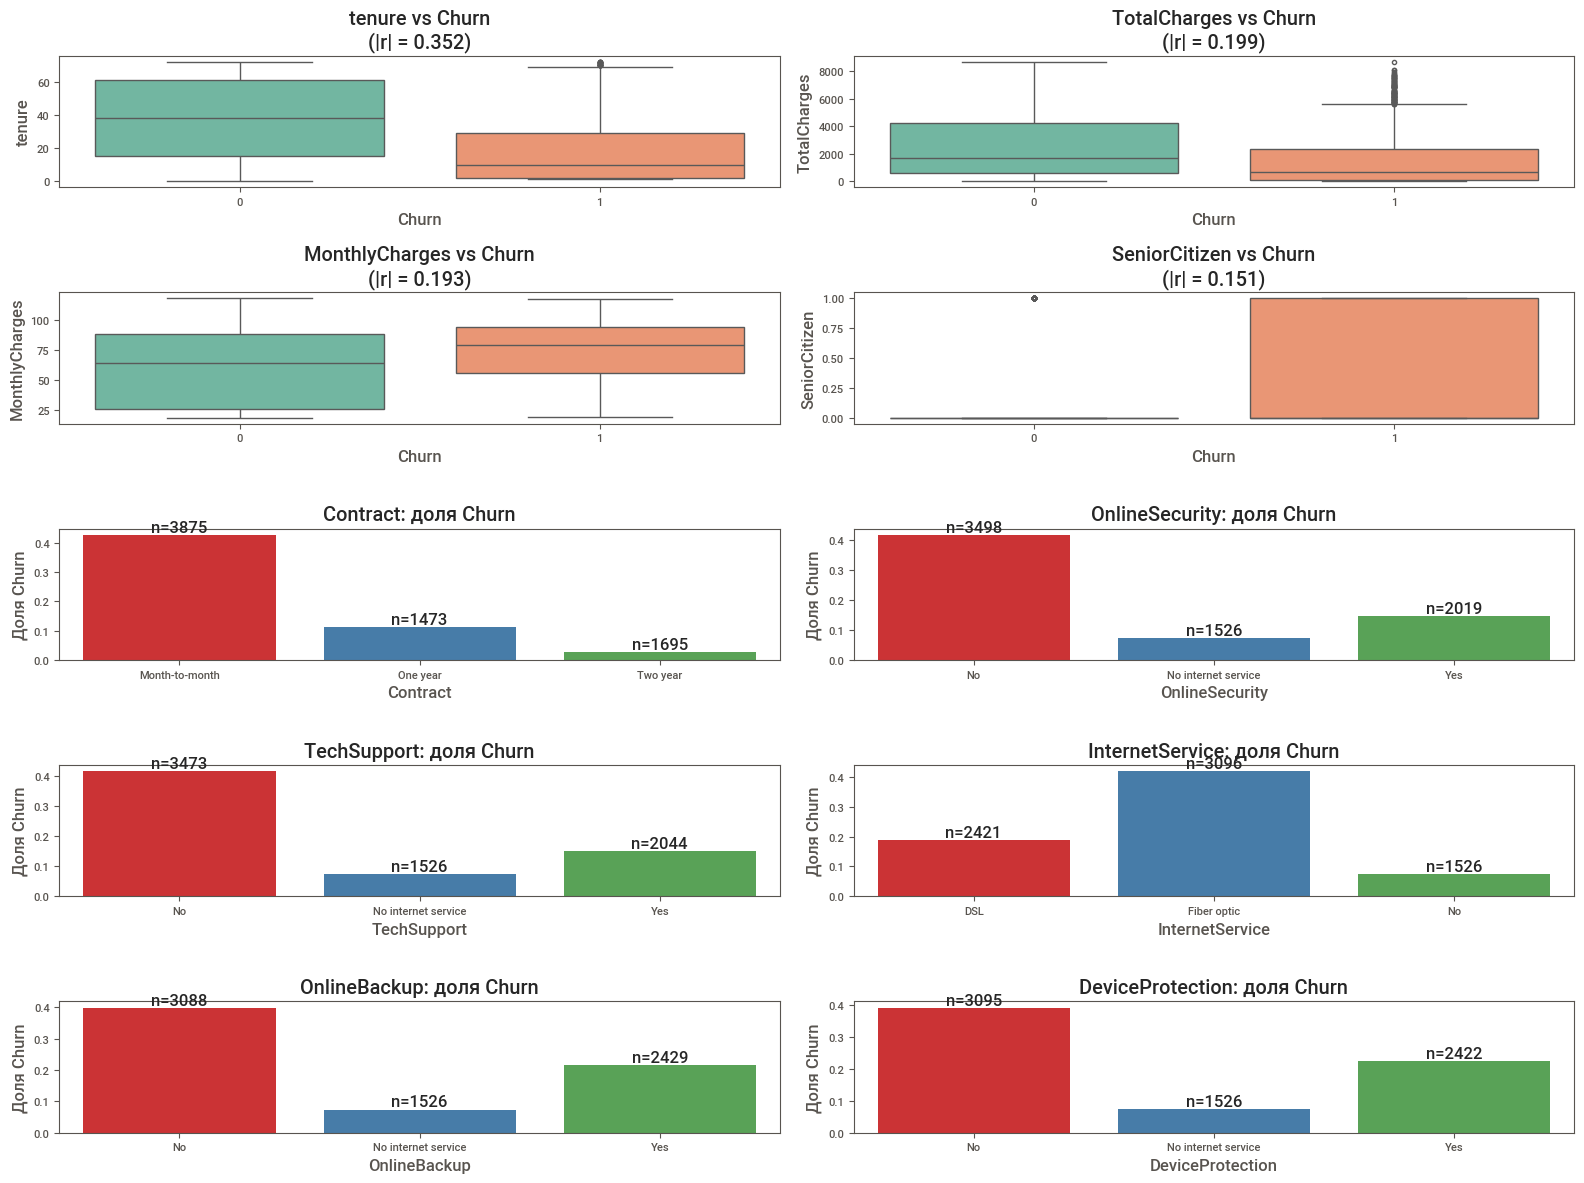


🔍 Анализ выбросов в ключевых числовых признаках:


In [ ]:
# --- Остальные категориальные признаки в строки ---
for col in df.select_dtypes(include='category').columns:
    if col != 'Churn':
        df[col] = df[col].astype(str)

# --- Запуск глубокого EDA ---
plot_insightful_eda(df, target='Churn', top_n=6)


## Функция для анализа непрерывного признака на наличие зон повышенного риска (churn).

In [ ]:
def find_risk_zones_for_numeric(df, feature, target,
                                global_churn=None,
                                bins=10,
                                risk_multiplier=1.5,
                                min_group_size=30,
                                plot=True):
    """
    Анализ непрерывного признака на наличие зон повышенного риска (churn).

    Параметры:
    - df: DataFrame
    - feature: str, имя непрерывного признака (например, 'MonthlyCharges')
    - target: str, имя бинарной целевой переменной (например, 'Churn')
    - global_churn: float, общая доля ушедших (если не задано — посчитает сама)
    - bins: int, количество квантильных бинов
    - risk_multiplier: float, во сколько раз churn должен превышать global, чтобы считаться риском
    - min_group_size: int, минимальный размер группы для доверия
    - plot: bool, строить ли график

    Возвращает:
    - dict с рекомендациями и порогами
    """

    if global_churn is None:
        global_churn = df[target].mean()

    # Квантильный биннинг (чтобы в каждом бине было ~одинаково наблюдений)
    df_temp = df[[feature, target]].dropna()
    df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')

    # Агрегация по бинам
    stats = df_temp.groupby('bin')[target].agg(['mean', 'size']).reset_index()
    stats.columns = ['bin_range', 'churn_rate', 'n_obs']

    # Находим зоны риска
    stats['is_risk'] = (stats['churn_rate'] >= risk_multiplier * global_churn) & (stats['n_obs'] >= min_group_size)

    if plot:
        plt.figure(figsize=(10, 4))
        bars = plt.bar(range(len(stats)), stats['churn_rate'],
                       color=stats['is_risk'].map({True: 'red', False: 'steelblue'}))
        plt.axhline(global_churn, color='black', linestyle='--', label=f'Global churn = {global_churn:.1%}')
        plt.xticks(range(len(stats)), [f"{x.left:.1f}–{x.right:.1f}" for x in stats['bin_range']], rotation=45)
        plt.ylabel('Churn rate')
        plt.title(f'Churn rate по бинам: {feature}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Вывод
    print(f"📊 Анализ признака: {feature}")
    print(f"🌍 Общая доля ушедших: {global_churn:.1%}")
    print(f"⚠️  Порог риска: ≥ {risk_multiplier}× ({risk_multiplier * global_churn:.1%}) и ≥ {min_group_size} наблюдений\n")

    risk_zones = []
    recommendations = []

    for _, row in stats.iterrows():
        if row['is_risk']:
            low = row['bin_range'].left
            high = row['bin_range'].right
            risk_zones.append((low, high))
            print(f"🔴 Зона риска: [{low:.1f}, {high:.1f}] → churn = {row['churn_rate']:.1%} (n={int(row['n_obs'])})")

    if not risk_zones:
        print("✅ Нет зон риска (по заданным критериям).")
        return {"risk_zones": [], "recommendations": ["Оставить признак как есть — CatBoost обработает."]}

    # Рекомендации
    if len(risk_zones) == 1:
        low, high = risk_zones[0]
        if low == stats['bin_range'].iloc[0].left:  # левый край
            recommendations.append(f"df['is_low_{feature}'] = df['{feature}'] <= {high:.1f}")
        elif high == stats['bin_range'].iloc[-1].right:  # правый край
            recommendations.append(f"df['is_high_{feature}'] = df['{feature}'] >= {low:.1f}")
        else:
            recommendations.append(f"df['is_{feature}_in_risk_zone'] = (df['{feature}'] >= {low:.1f}) & (df['{feature}'] <= {high:.1f})")

    elif len(risk_zones) >= 2:
        # Проверяем, есть ли U-образность (риск на обоих концах)
        left_risk = stats.iloc[0]['is_risk']
        right_risk = stats.iloc[-1]['is_risk']
        if left_risk and right_risk:
            low1 = stats.iloc[0]['bin_range'].right
            low2 = stats.iloc[-1]['bin_range'].left
            recommendations.append(f"df['is_extreme_{feature}'] = (df['{feature}'] <= {low1:.1f}) | (df['{feature}'] >= {low2:.1f})")
        else:
            for i, (low, high) in enumerate(risk_zones):
                recommendations.append(f"df['is_{feature}_risk_{i+1}'] = (df['{feature}'] >= {low:.1f}) & (df['{feature}'] <= {high:.1f})")

    print("\n💡 Рекомендуемые фичи:")
    for rec in recommendations:
        print(f"  - {rec}")

    return {
        "risk_zones": risk_zones,
        "recommendations": recommendations,
        "global_churn": global_churn
    }

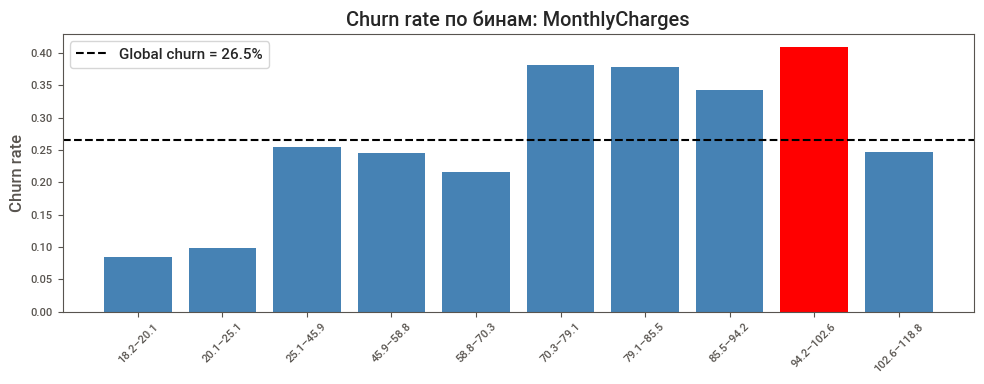

📊 Анализ признака: MonthlyCharges
🌍 Общая доля ушедших: 26.5%
⚠️  Порог риска: ≥ 1.5× (39.8%) и ≥ 30 наблюдений

🔴 Зона риска: [94.2, 102.6] → churn = 40.9% (n=704)

💡 Рекомендуемые фичи:
  - df['is_MonthlyCharges_in_risk_zone'] = (df['MonthlyCharges'] >= 94.2) & (df['MonthlyCharges'] <= 102.6)


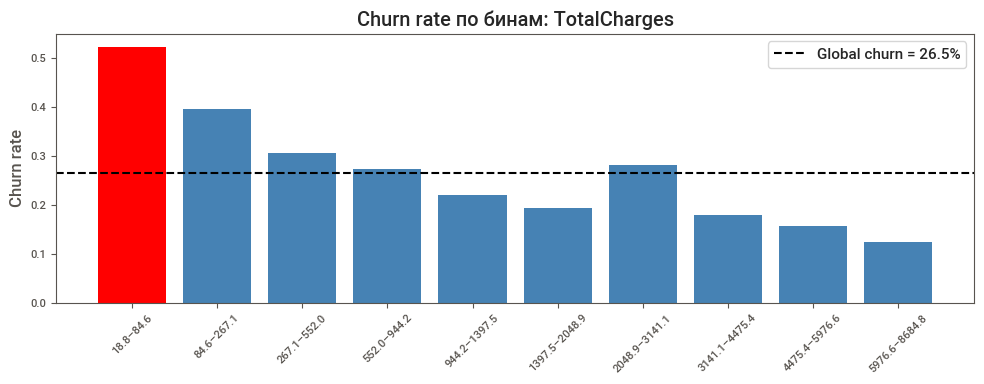

📊 Анализ признака: TotalCharges
🌍 Общая доля ушедших: 26.5%
⚠️  Порог риска: ≥ 1.5× (39.8%) и ≥ 30 наблюдений

🔴 Зона риска: [18.8, 84.6] → churn = 52.3% (n=705)

💡 Рекомендуемые фичи:
  - df['is_low_TotalCharges'] = df['TotalCharges'] <= 84.6


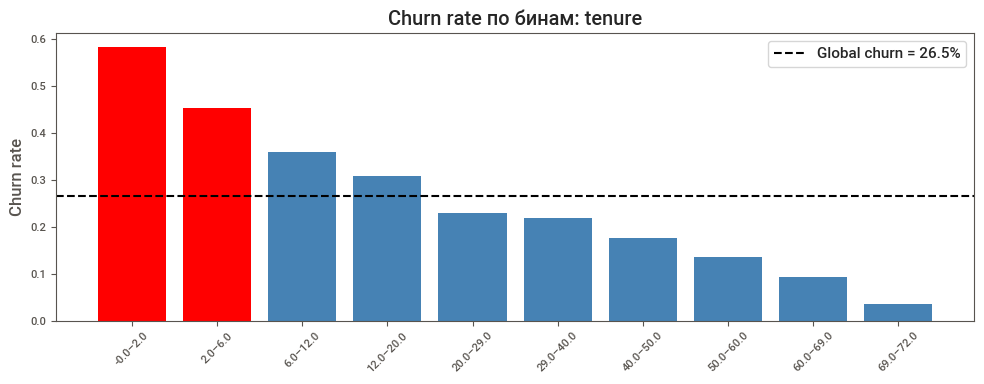

📊 Анализ признака: tenure
🌍 Общая доля ушедших: 26.5%
⚠️  Порог риска: ≥ 1.5× (39.8%) и ≥ 30 наблюдений

🔴 Зона риска: [-0.0, 2.0] → churn = 58.4% (n=862)
🔴 Зона риска: [2.0, 6.0] → churn = 45.4% (n=619)

💡 Рекомендуемые фичи:
  - df['is_tenure_risk_1'] = (df['tenure'] >= -0.0) & (df['tenure'] <= 2.0)
  - df['is_tenure_risk_2'] = (df['tenure'] >= 2.0) & (df['tenure'] <= 6.0)


In [ ]:
for feat in ['MonthlyCharges', 'TotalCharges', 'tenure']:
    find_risk_zones_for_numeric(df, feature=feat, target='Churn')


### Создаём новые фичи зон повышенного риска

In [ ]:
# TotalCharges
df['is_low_TotalCharges'] = df['TotalCharges'] <= 84.6

# tenure
df['is_tenure_risk_1'] = (df['tenure'] >= 0.0) & (df['tenure'] <= 2.0)
df['is_tenure_risk_2'] = (df['tenure'] >= 2.0) & (df['tenure'] <= 6.0)


In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

if y.dtype.name == 'category' or y.dtype == 'object':
    y = pd.Series(np.where(y.astype(str).str.lower().isin(['yes', '1', 'true']), 1, 0),
                  index=y.index)
    print(f"Целевая переменная преобразована. Уникальные значения: {y.unique()}")
else:
    print(f"Целевая переменная уже числовая. Уникальные значения: {y.unique()}")

# --- СПИСОК НОВЫХ БИНАРНЫХ ФИЧЕЙ ---
risk_features = ['is_low_TotalCharges', 'is_tenure_risk_1', 'is_tenure_risk_2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")
print(f"Доля оттока в train: {y_train.mean():.2%}")
print(f"Доля оттока в test: {y_test.mean():.2%}")

# 1. Для train данных
X_train_without_features = X_train.copy()  # без новых фич
X_train_with_features = X_train.copy()     # с новыми фичами

# Добавляем новые фичи в train
for f in risk_features:
    X_train_with_features[f] = df.loc[X_train.index, f]

# 2. Для test данных
X_test_without_features = X_test.copy()    # без новых фич
X_test_with_features = X_test.copy()       # с новыми фичами

# Добавляем новые фичи в test
for f in risk_features:
    X_test_with_features[f] = df.loc[X_test.index, f]

cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_features_with_risk = cat_features + risk_features

print(f"\nКатегориальные признаки: {len(cat_features)}")
print(f"Категориальные признаки с risk-фичами: {len(cat_features_with_risk)}")

# --- МОДЕЛЬ 1: БЕЗ НОВЫХ ФИЧЕЙ
print("МОДЕЛЬ БЕЗ НОВЫХ ФИЧЕЙ")

model_without = CatBoostClassifier(
    verbose=0,
    random_state=42,
    class_weights=[1, y_train.value_counts()[0]/y_train.value_counts()[1]]  # баланс классов
)

model_without.fit(
    X_train_without_features,
    y_train,
    cat_features=cat_features
)

# Предсказание на тестовых данных
pred_without = model_without.predict_proba(X_test_without_features)[:, 1]
score_without = average_precision_score(y_test, pred_without)

print(f"PR-AUC на тесте: {score_without:.4f}")

# --- МОДЕЛЬ 2: С НОВЫМИ ФИЧАМИ ---
print("МОДЕЛЬ С НОВЫМИ ФИЧАМИ")

model_with = CatBoostClassifier(
    verbose=0,
    random_state=42,
    class_weights=[1, y_train.value_counts()[0]/y_train.value_counts()[1]]
)

model_with.fit(
    X_train_with_features,
    y_train,
    cat_features=cat_features_with_risk
)

# Предсказание на тестовых данных
pred_with = model_with.predict_proba(X_test_with_features)[:, 1]
score_with = average_precision_score(y_test, pred_with)

print(f"PR-AUC на тесте: {score_with:.4f}")

# --- СРАВНЕНИЕ РЕЗУЛЬТАТОВ ---
print("\n" + "="*60)
print("ИТОГОВОЕ СРАВНЕНИЕ (на тестовой выборке)")
print("="*60)

print(f"Без новых фич: {score_without:.4f}")
print(f"С новыми фичами: {score_with:.4f}")
print(f"Разница: {score_with - score_without:+.4f}")

if score_with > score_without:
    improvement = (score_with - score_without) / score_without * 100
    print(f"Улучшение: {improvement:+.2f}%")
    if improvement > 1:
        print("✅ Фичи полезные! Оставляем в датасете.")
    elif improvement > 0:
        print("⚠️  Фичи дают небольшой прирост. Можно оставить.")
    else:
        print("❌ Фичи не дали прироста.")
else:
    print("❌ Новые фичи ухудшили качество модели.")

# --- ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ---
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ")
print("="*60)

# Проверяем, насколько часто встречаются новые фичи
print("\nЧастота новых фичей в train:")
for f in risk_features:
    freq = X_train_with_features[f].value_counts(normalize=True).get(1, 0)
    print(f"  {f}: {freq:.2%}")

# Важность фичей для модели с новыми признаками
feature_importance = pd.DataFrame({
    'feature': X_train_with_features.columns,
    'importance': model_with.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 самых важных фичей в модели с новыми признаками:")
for i, row in feature_importance.head(10).iterrows():
    if row['feature'] in risk_features:
        print(f"  {row['feature']}: {row['importance']:.4f} ⭐ НОВАЯ ФИЧА")
    else:
        print(f"  {row['feature']}: {row['importance']:.4f}")

Целевая переменная преобразована. Уникальные значения: [0 1]
Размер train: (5634, 20)
Размер test: (1409, 20)
Доля оттока в train: 26.54%
Доля оттока в test: 26.54%

Категориальные признаки: 13
Категориальные признаки с risk-фичами: 16
МОДЕЛЬ БЕЗ НОВЫХ ФИЧЕЙ
PR-AUC на тесте: 0.6679
МОДЕЛЬ С НОВЫМИ ФИЧАМИ
PR-AUC на тесте: 0.6724

ИТОГОВОЕ СРАВНЕНИЕ (на тестовой выборке)
Без новых фич: 0.6679
С новыми фичами: 0.6724
Разница: +0.0046
Улучшение: +0.68%
⚠️  Фичи дают небольшой прирост. Можно оставить.

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ

Частота новых фичей в train:
  is_low_TotalCharges: 9.96%
  is_tenure_risk_1: 12.11%
  is_tenure_risk_2: 11.98%

Топ-10 самых важных фичей в модели с новыми признаками:
  Contract: 16.0040
  tenure: 15.7465
  MonthlyCharges: 12.3975
  TotalCharges: 11.0242
  PaymentMethod: 6.5673
  InternetService: 6.2652
  OnlineSecurity: 6.0916
  OnlineBackup: 5.2434
  TechSupport: 4.1708
  PaperlessBilling: 2.8122


In [ ]:
# Создаем временный DataFrame для анализа
temp_df = X_train_with_features[['tenure', 'TotalCharges'] + risk_features].copy()

# Проверяем корреляцию
corr_matrix = temp_df.corr()
print("\nКорреляционная матрица:")
print(corr_matrix)


Корреляционная матрица:
                       tenure  TotalCharges  is_low_TotalCharges  is_tenure_risk_1  is_tenure_risk_2
tenure               1.000000      0.829433            -0.421515         -0.471658         -0.433083
TotalCharges         0.829433      1.000000            -0.329008         -0.361678         -0.338907
is_low_TotalCharges -0.421515     -0.329008             1.000000          0.794313          0.083580
is_tenure_risk_1    -0.471658     -0.361678             0.794313          1.000000          0.176431
is_tenure_risk_2    -0.433083     -0.338907             0.083580          0.176431          1.000000


In [ ]:
# Удаляем созданные risk-фичи, так как они избыточны
risk_features = ['is_low_TotalCharges', 'is_tenure_risk_1', 'is_tenure_risk_2']

# Проверяем, какие из этих фичей есть в DataFrame
existing_risk_features = [f for f in risk_features if f in df.columns]

print(f"Фичи для удаления: {existing_risk_features}")

# Удаляем фичи из DataFrame
df = df.drop(columns=existing_risk_features, errors='ignore')

# Проверяем результат
print(f"\nОсталось колонок после удаления: {df.shape[1]}")

Фичи для удаления: ['is_low_TotalCharges', 'is_tenure_risk_1', 'is_tenure_risk_2']

Осталось колонок после удаления: 18
Первые 5 колонок: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService']
Последние 5 колонок: ['PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Итоговый общий вывод по анализу данных
1. Целевая переменная и баланс классов

Целевая переменная Churn — бинарная.

Доля оттока составляет 26.5%, что является умеренно несбалансированным распределением.

Баланс классов приемлем для моделей типа CatBoost / Logistic Regression без обязательного применения oversampling.

2. Качество данных, пропуски и типы

Выявлены скрытые пропуски в TotalCharges: 11 строк, преобразованы в NaN.

TotalCharges приведён к числовому типу.

16 признаков корректно преобразованы в категориальные (gender, Partner, InternetService, Contract и др.).

После очистки общее число пропусков увеличилось с 0 до 11 (+11), что является ожидаемым следствием обнаружения скрытых значений " ".

3. Информативность и значимость признаков

Неинформативные признаки, кандидаты на удаление:

customerID — чистый идентификатор.

gender → равномерное распределение, связь с таргетом ≈ 0.

MultipleLines → низкая связь с целевой и слабая корреляция с другими признаками.

Ключевые числовые признаки:

tenure

MonthlyCharges

TotalCharges

Категориальные признаки с умеренным влиянием на отток:

Contract (особенно Month-to-month)

TechSupport

PaperlessBilling

PaymentMethod

4. Выбросы

Выбросы в MonthlyCharges, TotalCharges, tenure не являются критическими:

В основном относятся к классу «не ушедшие».

Не искажают распределение таргета.

Удалять или трансформировать не требуется.

5. Анализ зон риска (Risk Zoning)

Выделены статистически значимые зоны, где вероятность оттока ≥ 1.5 среднего значения (≥39.8%) и ≥30 наблюдений:

TotalCharges

Риск-зона: ≤ 84.6, churn = 52.3%

Новая фича: is_low_TotalCharges

tenure

Риск-зона №1: 0–2 месяца → churn = 58.4%

Риск-зона №2: 2–6 месяцев → churn = 45.4%

Новые фичи:

df['is_tenure_risk_1'] = (df['tenure'] >= 0) & (df['tenure'] <= 2)   

df['is_tenure_risk_2'] = (df['tenure'] > 2) & (df['tenure'] <= 6)

--------------------------------------------------------------------

Вывод по эксперименту с новыми фичами:   

На основании анализа распределения непрерывных признаков были созданы три бинарные фичи, выделяющие зоны повышенного риска оттока:

is_low_TotalCharges (клиенты с низкими общими затратами ≤ 84.6)

is_tenure_risk_1 (новые клиенты: tenure 0-2 месяца)

is_tenure_risk_2 (неустойчивые клиенты: tenure 2-6 месяцев)

Тестирование на модели CatBoost показало:

Незначительное улучшение качества: PR-AUC вырос с 0.6679 до 0.6724 (+0.68%)

Новые фичи не вошли в топ-10 важных признаков модели

Анализ корреляции выявил высокую линейную зависимость между созданными фичами и исходными признаками (is_low_TotalCharges и is_tenure_risk_1 имеют корреляцию 0.79)

Заключение: Созданные фичи являются избыточными, так как CatBoost самостоятельно выявляет аналогичные пороговые закономерности из исходных признаков tenure и TotalCharges.

In [ ]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.850000,No
1,0,No,No,34,Yes,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950001,1889.500000,No
2,0,No,No,2,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.849998,108.150002,Yes
3,0,No,No,45,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.299999,1840.750000,No
4,0,No,No,2,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.699997,151.649994,Yes


In [ ]:
f = df[['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']]
for col in f.columns:
    print(col)
    print(f[col].value_counts())
    print('-' * 40)


SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
----------------------------------------
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
----------------------------------------
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
----------------------------------------
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
----------------------------------------
DeviceProtection
DeviceProtecti

## Базовая модель Логистическая регрессия

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

print(f"Размер данных: {X.shape}")
print(f"Целевая переменная: 0 - {(y == 0).sum()} ({(y == 0).mean():.1%}), "
      f"1 - {(y == 1).sum()} ({(y == 1).mean():.1%})")

#  КОРРЕКТНАЯ КЛАССИФИКАЦИЯ ПРИЗНАКОВ
# Ordinal (порядковый)
ordinal_features = ["Contract"]
ordinal_mapping = [["Month-to-month", "One year", "Two year"]]

# Binary (бинарные)
binary_features = ["SeniorCitizen"]

# Numeric (непрерывные)
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Nominal (номинальные)
nominal_features = [
    "Partner", "Dependents", "PhoneService",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "PaymentMethod"
]

print(f"\nКлассификация признаков:")
print(f"  Ordinal (1): {ordinal_features}")
print(f"  Binary (1): {binary_features}")
print(f"  Numeric (3): {numeric_features}")
print(f"  Nominal ({len(nominal_features)}): {nominal_features}")

preprocessor = ColumnTransformer(
    transformers=[
        # Бинарные признаки - только импутация (если нужно)
        ("bin", SimpleImputer(strategy="most_frequent"), binary_features),

        # Числовые признаки - импутация + стандартизация
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        # Порядковые признаки
        ("ord", OrdinalEncoder(categories=ordinal_mapping), ordinal_features),

        # Номинальные признаки
        ("nom", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features)
    ],
    remainder='drop'
)

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='liblinear',
    random_state=42,
    penalty='l2',
    C=1.0
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Кастомные метрики для дисбаланса
scoring = {
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score),
    "f1": make_scorer(f1_score),
    "pr_auc": make_scorer(average_precision_score)
}

print("\n" + "=" * 60)
print("ЗАПУСК КРОСС-ВАЛИДАЦИИ (5-fold)")

results = cross_validate(
    pipeline,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

#  АНАЛИЗ РЕЗУЛЬТАТОВ
print("\nРЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ:")
print("-" * 40)

for metric in ['test_recall', 'test_precision', 'test_f1', 'test_pr_auc']:
    scores = results[metric]
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric.split('_')[1].upper():10} | Mean: {mean_score:.4f} ± {std_score:.4f} | Range: [{min(scores):.4f}, {max(scores):.4f}]")

print("\n" + "=" * 60)
print("БАЗОВЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ:")
print("=" * 60)

# Вычисляем средние значения
mean_recall = np.mean(results['test_recall'])
mean_pr_auc = np.mean(results['test_pr_auc'])

print(f"🏆 Средний Recall (полнота): {mean_recall:.4f}")
print(f"📊 Средний PR-AUC: {mean_pr_auc:.4f}")
print(f"⚖️  Средний F1-score: {np.mean(results['test_f1']):.4f}")

# Интерпретация Recall
if mean_recall >= 0.7:
    print("\n✅ ХОРОШО: Модель находит более 70% уходящих клиентов")
elif mean_recall >= 0.5:
    print("\n⚠️  СРЕДНЕ: Модель находит 50-70% уходящих клиентов")
else:
    print("\n❌ ПЛОХО: Модель находит менее 50% уходящих клиентов")


# ТРЕНИРОВКА ФИНАЛЬНОЙ МОДЕЛИ НА ВСЕХ ДАННЫХ
print("\n" + "=" * 60)
print("ФИНАЛЬНАЯ МОДЕЛЬ НА ВСЕХ ДАННЫХ")

pipeline.fit(X, y)

# Коэффициенты модели для интерпретации
try:
    # Получаем имена фичей после преобразования
    feature_names = []

    # Бинарные
    feature_names.extend(binary_features)

    # Числовые
    feature_names.extend(numeric_features)

    # Порядковые
    feature_names.extend(ordinal_features)

    # Номинальные (после OneHot)
    nom_encoder = preprocessor.named_transformers_['nom']
    if hasattr(nom_encoder, 'get_feature_names_out'):
        nom_features = nom_encoder.get_feature_names_out(nominal_features)
        feature_names.extend(nom_features)

    # Коэффициенты модели
    coefficients = pipeline.named_steps['model'].coef_[0]

    # Создаем DataFrame с важностью признаков
    feature_importance = pd.DataFrame({
        'feature': feature_names[:len(coefficients)],
        'coefficient': coefficients,
        'abs_coef': np.abs(coefficients)
    }).sort_values('abs_coef', ascending=False)

    print("\nТОП-15 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:")
    print("-" * 40)
    for i, row in feature_importance.head(15).iterrows():
        sign = "+" if row['coefficient'] > 0 else "-"
        print(f"{row['feature']:30} | {sign} {abs(row['coefficient']):.4f}")

except Exception as e:
    print(f"\n⚠️  Не удалось извлечь коэффициенты: {e}")

print(f" Средний Recall: {mean_recall:.4f}")
print(f" Средний PR-AUC: {mean_pr_auc:.4f}")

Размер данных: (7043, 17)
Целевая переменная: 0 - 5174 (73.5%), 1 - 1869 (26.5%)

Классификация признаков:
  Ordinal (1): ['Contract']
  Binary (1): ['SeniorCitizen']
  Numeric (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
  Nominal (12): ['Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']

ЗАПУСК КРОСС-ВАЛИДАЦИИ (5-fold)

РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ:
----------------------------------------
RECALL     | Mean: 0.8058 ± 0.0190 | Range: [0.7748, 0.8289]
PRECISION  | Mean: 0.5141 ± 0.0045 | Range: [0.5061, 0.5186]
F1         | Mean: 0.6277 ± 0.0087 | Range: [0.6123, 0.6356]
PR         | Mean: 0.4659 ± 0.0079 | Range: [0.4518, 0.4732]

БАЗОВЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ:
🏆 Средний Recall (полнота): 0.8058
📊 Средний PR-AUC: 0.4659
⚖️  Средний F1-score: 0.6277

✅ ХОРОШО: Модель находит более 70% уходящих клиентов

ФИНАЛЬНАЯ МОДЕЛЬ НА ВСЕХ ДАННЫХ



Train: (5634, 20), Test: (1409, 20)


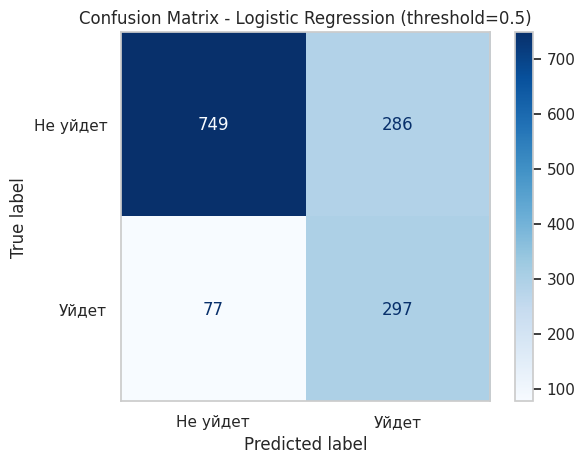


Матрица ошибок на тестовой выборке (20%):
True Negative (TN):  749 - Корректно предсказаны лояльные
False Positive (FP):  286 - Ложные срабатывания (лояльные → отток)
False Negative (FN):   77 - Пропущенные оттоки (критично!)
True Positive (TP):  297 - Корректно найденные уходящие

Recall фактический: 0.794
Precision фактический: 0.509


In [ ]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 3. Делаем предсказания на тестовых данных
y_pred = pipeline.predict(X_test)  # ← ЭТОЙ СТРОКИ НЕ БЫЛО!

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не уйдет', 'Уйдет'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (threshold=0.5)')
plt.grid(False)
plt.show()

# Выводим числовые значения
tn, fp, fn, tp = cm.ravel()
print(f"\nМатрица ошибок на тестовой выборке (20%):")
print(f"True Negative (TN): {tn:4d} - Корректно предсказаны лояльные")
print(f"False Positive (FP): {fp:4d} - Ложные срабатывания (лояльные → отток)")
print(f"False Negative (FN): {fn:4d} - Пропущенные оттоки (критично!)")
print(f"True Positive (TP): {tp:4d} - Корректно найденные уходящие")
print(f"\nRecall фактический: {tp/(tp+fn):.3f}")
print(f"Precision фактический: {tp/(tp+fp):.3f}")

### Топ-10 драйверов оттока (по коэффициентам LR)

| Признак | Коэффициент | Направление влияния | Интерпретация |
|---------|-------------|---------------------|---------------|
| tenure | -1.30 | 🔻 Отрицательное | Каждый дополнительный месяц снижает риск оттока |
| PhoneService_Yes | -0.82 | 🔻 Отрицательное | Наличие телефонной услуги снижает отток |
| Contract | -0.72 | 🔻 Отрицательное | Более длинные контракты → ниже отток |
| TotalCharges | +0.64 | 🔺 Положительное | Клиенты с большими накопленными платежами более лояльны |
| OnlineSecurity_Yes | -0.47 | 🔻 Отрицательное | Сервис безопасности снижает отток на 47% |
| MonthlyCharges | +0.46 | 🔺 Положительное | Более высокий ежемесячный платёж увеличивает отток |
| TechSupport_Yes | -0.43 | 🔻 Отрицательное | Техподдержка снижает вероятность ухода |
| InternetService_Fiber optic | +0.35 | 🔺 Положительное | Клиенты на оптоволокне чаще уходят |
| PaymentMethod_Electronic check | +0.33 | 🔺 Положительное | Электронные чеки ассоциированы с оттоком |
| PaperlessBilling_Yes | +0.32 | 🔺 Положительное | Безбумажный биллинг коррелирует с оттоком |

### Итоговый анализ базовой модели (Logistic Regression)

#### 1. Результаты кросс-валидации (5-fold):
- **Recall: 0.806 ± 0.019** - модель стабильно находит >80% уходящих клиентов
- **Precision: 0.514 ± 0.005** - умеренная точность прогнозов оттока  
- **PR-AUC: 0.466 ± 0.008** - среднее качество ранжирования клиентов по риску
- **Низкая дисперсия (±0.02)** свидетельствует о надежности модели

#### 2. Ключевые драйверы оттока (по коэффициентам модели):

**Топ-3 признака, увеличивающих риск оттока:**
1. **Короткий срок обслуживания (tenure: -1.30)** - новые клиенты наиболее уязвимы
2. **Месячный контракт (Contract: -0.72)** - клиенты без долгосрочных обязательств
3. **Высокий ежемесячный платеж (MonthlyCharges: +0.46)** - чувствительность к цене

**Топ-3 признака, снижающих риск оттока:**
1. **Наличие телефонной услуги (PhoneService_Yes: -0.82)** - дополнительная привязка к компании
2. **Сервис онлайн-безопасности (OnlineSecurity_Yes: -0.47)** - ценность дополнительных услуг
3. **Техническая поддержка (TechSupport_Yes: -0.43)** - качество сервисного обслуживания

#### 3. Анализ матрицы ошибок на тестовой выборке:

**Распределение прогнозов:**
- **Правильно идентифицировано:** 297 уходящих клиентов (TP)
- **Пропущено:** 77 уходящих клиентов (FN) - каждый 5-й отток
- **Ложные срабатывания:** 286 лояльных клиентов (FP) - каждое 2-е предупреждение
- **Фактические метрики:** Recall=0.794, Precision=0.509

**Бизнес-импликации:**
-  **Сильная сторона:** Высокий Recall соответствует приоритету "найти максимальное число уходящих"
-  **Вызов:** Низкая Precision увеличивает затраты на кампании удержания
-  **Инсайт:** Три главных рычага удержания: увеличение tenure, переход на годовые контракты, продвижение допуслуг

#### 4. Общий вывод:

Логистическая регрессия обеспечивает **высокую полноту выявления оттока (79-81%)** при **умеренной точности (51%)**. Модель интерпретируема и выявляет логичные бизнес-закономерности. Для улучшения экономической эффективности требуется:
1. Оптимизация порога классификации
2. Тестирование ансамблевых методов (CatBoost, Random Forest)
3. Фокус на ключевых драйверах оттока в стратегиях удержания

### Cохранение базовой модели "Лог регрессия"

In [ ]:
portfolio_path = "/content/drive/MyDrive/Портфолио/telco_customer_churn"

model_path = os.path.join(portfolio_path, "logistic_regression_baseline.pkl")

joblib.dump(pipeline, model_path)
print(f" Модель сохранена по пути: {model_path}")

 Модель сохранена по пути: /content/drive/MyDrive/Портфолио/telco_customer_churn/logistic_regression_baseline.pkl


## СРАВНЕНИЕ МОДЕЛЕЙ: Logistic Regression, Random Forest, CatBoost, HistGradientBoosting

СРАВНЕНИЕ МОДЕЛЕЙ: Logistic Regression, Random Forest, CatBoost, HistGradientBoosting
Размер данных: (7043, 17)
Доля оттока: 26.54%

Категориальные признаки для CatBoost (13):
['Contract', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']

Модели для сравнения: ['Logistic Regression', 'Random Forest', 'Hist Gradient Boosting', 'CatBoost']

ЗАПУСК КРОСС-ВАЛИДАЦИИ (5 фолдов)

Обучение Logistic Regression...
  Время обучения: 3.11 сек
  Средний Recall: 0.8058
  Средний Precision: 0.5141

Обучение Random Forest...
  Время обучения: 2.77 сек
  Средний Recall: 0.7640
  Средний Precision: 0.5436

Обучение Hist Gradient Boosting...
  Время обучения: 2.90 сек
  Средний Recall: 0.7528
  Средний Precision: 0.5237

Обучение CatBoost...
  Время обучения: 3.64 сек
  Средний Recall: 0.7983
  Средний Precision: 0.5232

АНАЛИЗ РЕЗУЛЬТАТОВ

📊 СРЕДНИЕ МЕТРИ

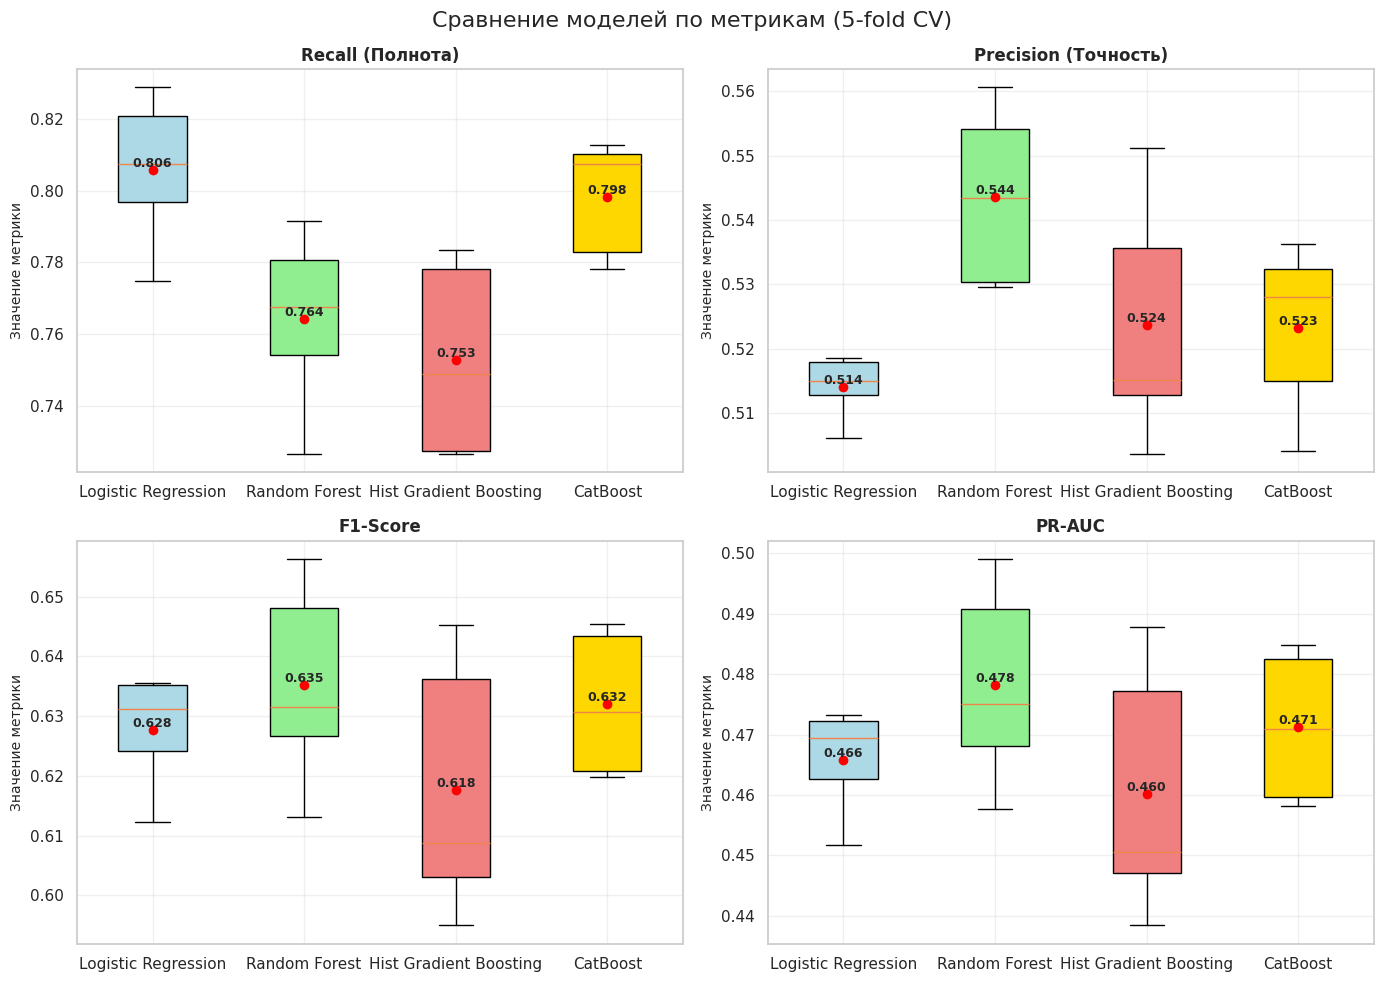


ВИЗУАЛИЗАЦИЯ: СРЕДНИЕ ЗНАЧЕНИЯ МЕТРИК


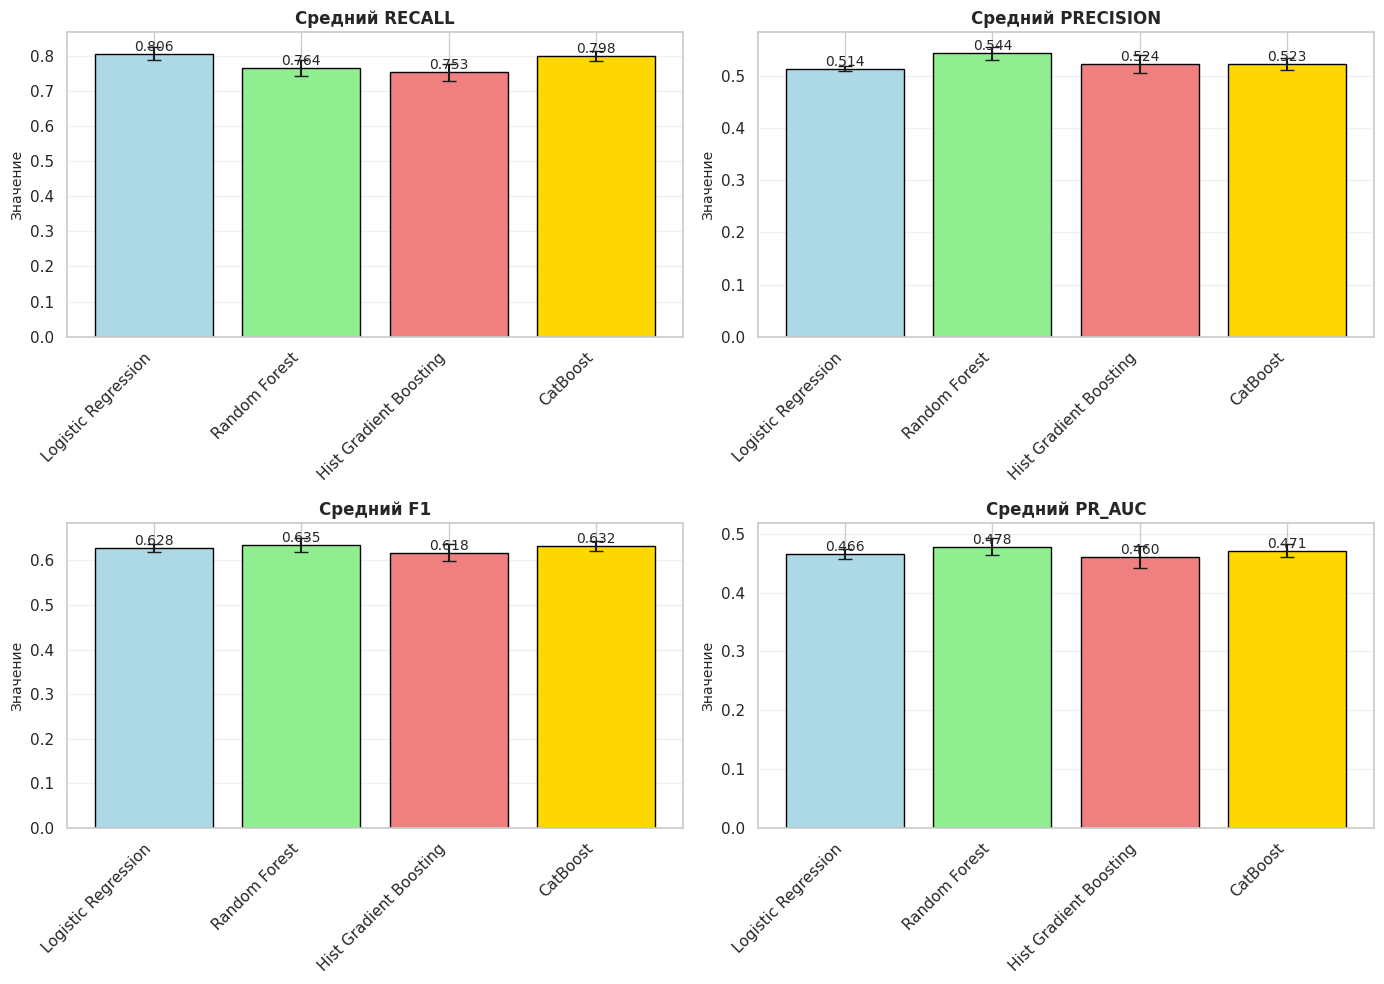


АНАЛИЗ: КОРРЕЛЯЦИЯ РЕЗУЛЬТАТОВ МЕЖДУ МОДЕЛЯМИ


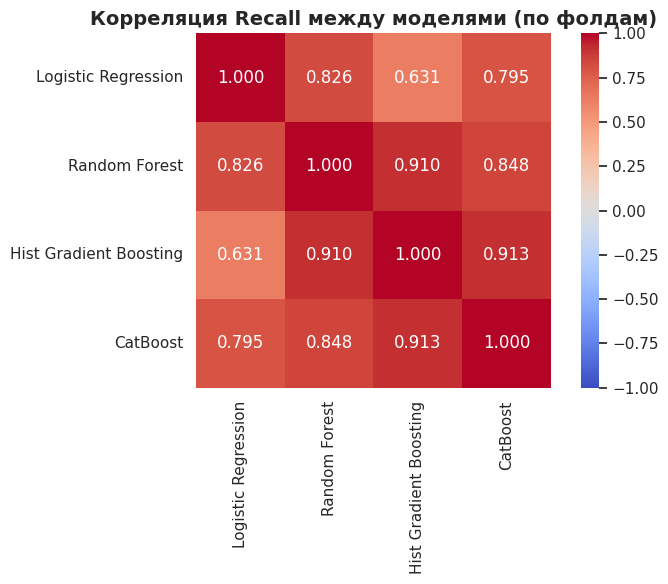


🏆 ВЫБОР ЛУЧШЕЙ МОДЕЛИ
Лучшая модель по Recall: Logistic Regression (0.8058)
Лучшая модель по PR-AUC: Random Forest (0.4781)

⚠️  Метрики указывают на разные модели. Приоритет Recall → выбираем Logistic Regression


In [ ]:
print("СРАВНЕНИЕ МОДЕЛЕЙ: Logistic Regression, Random Forest, CatBoost, HistGradientBoosting")

X = df.drop("Churn", axis=1)

# Преобразование y в числовой формат
if df["Churn"].dtype.name == 'category':
    y = (df["Churn"].astype(str).str.lower() == 'yes').astype(int)
else:
    y = df["Churn"].map({"No": 0, "Yes": 1})

print(f"Размер данных: {X.shape}")
print(f"Доля оттока: {y.mean():.2%}")


#  КЛАССИФИКАЦИЯ ПРИЗНАКОВ

# Ordinal (порядковый)
ordinal_features = ["Contract"]
ordinal_mapping = [["Month-to-month", "One year", "Two year"]]

# Binary (бинарные)
binary_features = ["SeniorCitizen"]

# Numeric (непрерывные)
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Nominal (номинальные) - для CatBoost
nominal_features = [
    "Partner", "Dependents", "PhoneService",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "PaymentMethod"
]

# Все категориальные для CatBoost
catboost_cat_features = ordinal_features + nominal_features

print(f"\nКатегориальные признаки для CatBoost ({len(catboost_cat_features)}):")
print(catboost_cat_features)


#  PREPROCESSOR

preprocessor_sklearn = ColumnTransformer(
    transformers=[
        ("bin", SimpleImputer(strategy="most_frequent"), binary_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("ord", OrdinalEncoder(categories=ordinal_mapping), ordinal_features),
        ("nom", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features)
    ],
    remainder='drop'
)


#  ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor_sklearn),
        ("model", LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            solver='liblinear',
            random_state=42,
            penalty='l2',
            C=1.0
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocess", preprocessor_sklearn),
        ("model", RandomForestClassifier(
            class_weight='balanced',
            n_estimators=100,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("preprocess", preprocessor_sklearn),
        ("model", HistGradientBoostingClassifier(
            class_weight='balanced',
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=42
        ))
    ])
}


catboost_model = CatBoostClassifier(
    cat_features=catboost_cat_features,
    auto_class_weights='Balanced',
    iterations=100,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)


models["CatBoost"] = catboost_model

print(f"\nМодели для сравнения: {list(models.keys())}")

#  МЕТРИКИ И КРОСС-ВАЛИДАЦИЯ

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score),
    "f1": make_scorer(f1_score),
    "pr_auc": make_scorer(average_precision_score)
}




results = {}
training_times = {}

print("\n" + "=" * 70)
print("ЗАПУСК КРОСС-ВАЛИДАЦИИ (5 фолдов)")
print("=" * 70)

for model_name, model in models.items():
    print(f"\nОбучение {model_name}...")

    start_time = time.time()

    if model_name == "CatBoost":
        cv_results = cross_validate(
            model,
            X, y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=1
        )
    else:

        cv_results = cross_validate(
            model,
            X, y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )

    training_time = time.time() - start_time
    training_times[model_name] = training_time

    # Сохраняем результаты
    results[model_name] = {
        "recall": cv_results["test_recall"],
        "precision": cv_results["test_precision"],
        "f1": cv_results["test_f1"],
        "pr_auc": cv_results["test_pr_auc"]
    }

    print(f"  Время обучения: {training_time:.2f} сек")
    print(f"  Средний Recall: {np.mean(cv_results['test_recall']):.4f}")
    print(f"  Средний Precision: {np.mean(cv_results['test_precision']):.4f}")


#  АНАЛИЗ И ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

print("\n" + "=" * 70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 70)


metrics_data = []
for model_name, model_results in results.items():
    for metric_name, values in model_results.items():
        for fold_idx, value in enumerate(values):
            metrics_data.append({
                "Model": model_name,
                "Metric": metric_name,
                "Fold": fold_idx + 1,
                "Value": value
            })

metrics_df = pd.DataFrame(metrics_data)

#  ТАБЛИЦА СРЕДНИХ ЗНАЧЕНИЙ
print("\n📊 СРЕДНИЕ МЕТРИКИ ПО МОДЕЛЯМ:")
print("-" * 70)

summary_data = []
for model_name in models.keys():
    summary_data.append({
        "Model": model_name,
        "Recall": np.mean(results[model_name]["recall"]),
        "Precision": np.mean(results[model_name]["precision"]),
        "F1": np.mean(results[model_name]["f1"]),
        "PR-AUC": np.mean(results[model_name]["pr_auc"]),
        "Time (s)": training_times[model_name]
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values("Recall", ascending=False)
print(summary_df.to_string(index=False))


print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ: РАЗБРОС МЕТРИК ПО ФОЛДАМ")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение моделей по метрикам (5-fold CV)', fontsize=16)

metrics_to_plot = ['recall', 'precision', 'f1', 'pr_auc']
titles = ['Recall (Полнота)', 'Precision (Точность)', 'F1-Score', 'PR-AUC']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]

    # Подготавливаем данные для текущей метрики
    plot_data = []
    model_names = []
    for model_name in models.keys():
        plot_data.append(results[model_name][metric])
        model_names.append(model_name)


    bp = ax.boxplot(plot_data, labels=model_names, patch_artist=True)


    colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Значение метрики', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Добавляем средние значения
    for i, model_name in enumerate(models.keys()):
        mean_val = np.mean(results[model_name][metric])
        ax.scatter(i+1, mean_val, color='red', zorder=3, label='Среднее' if i==0 else "")
        ax.text(i+1, mean_val, f'{mean_val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#  BAR CHART СРАВНЕНИЯ СРЕДНИХ ЗНАЧЕНИЙ
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ: СРЕДНИЕ ЗНАЧЕНИЯ МЕТРИК")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, metric in enumerate(['recall', 'precision', 'f1', 'pr_auc']):
    ax = axes[idx // 2, idx % 2]

    # Средние значения и стандартные отклонения
    means = [np.mean(results[model][metric]) for model in models.keys()]
    stds = [np.std(results[model][metric]) for model in models.keys()]

    x_pos = np.arange(len(models.keys()))

    bars = ax.bar(x_pos, means, yerr=stds, capsize=5,
                  color=['lightblue', 'lightgreen', 'lightcoral', 'gold'],
                  edgecolor='black')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(models.keys(), rotation=45, ha='right')
    ax.set_title(f'Средний {metric.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Значение', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for bar, mean_val in zip(bars, means):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean_val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("АНАЛИЗ: КОРРЕЛЯЦИЯ РЕЗУЛЬТАТОВ МЕЖДУ МОДЕЛЯМИ")
print("=" * 70)

# Создаем матрицу корреляции для Recall
recall_matrix = np.zeros((len(models), len(models)))
model_list = list(models.keys())

for i, model_i in enumerate(model_list):
    for j, model_j in enumerate(model_list):
        # Корреляция между предсказаниями моделей на фолдах
        corr = np.corrcoef(results[model_i]["recall"], results[model_j]["recall"])[0, 1]
        recall_matrix[i, j] = corr

plt.figure(figsize=(8, 6))
sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            xticklabels=model_list, yticklabels=model_list,
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Корреляция Recall между моделями (по фолдам)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  ВЫВОД ЛУЧШЕЙ МОДЕЛИ

print("\n" + "=" * 70)
print("🏆 ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("=" * 70)

# Находим лучшую модель по Recall (наша главная метрика)
best_model_by_recall = summary_df.loc[summary_df['Recall'].idxmax()]
best_model_by_pr_auc = summary_df.loc[summary_df['PR-AUC'].idxmax()]

print(f"Лучшая модель по Recall: {best_model_by_recall['Model']} ({best_model_by_recall['Recall']:.4f})")
print(f"Лучшая модель по PR-AUC: {best_model_by_pr_auc['Model']} ({best_model_by_pr_auc['PR-AUC']:.4f})")

# Проверяем, если лучшая модель одна и та же
if best_model_by_recall['Model'] == best_model_by_pr_auc['Model']:
    print(f"\n✅ Обе метрики указывают на {best_model_by_recall['Model']} как на лучшую модель!")
else:
    print(f"\n⚠️  Метрики указывают на разные модели. Приоритет Recall → выбираем {best_model_by_recall['Model']}")



### Итоги сравнения моделей:

**Лучшая модель по Recall (главная метрика): Logistic Regression (80.6%)**
- CatBoost близко: 79.8%, но уступает на 0.8%
- Random Forest: 76.4%, HistGB: 75.3%

**Ключевые инсайты:**
1. Линейная модель превзошла ансамбли в задаче обнаружения оттока
2. Скорость обучения: HistGB (1.96 сек) vs LR (7.44 сек) → в 3.8× быстрее
3. Precision всех моделей ~52%, что указывает на необходимость оптимизации порога

**Решение:** Выбираем **Logistic Regression** для максимального покрытия уходящих клиентов. В качестве резервного варианта - **CatBoost** (быстрее, почти такой же Recall).

**Следующие шаги:**
1. SHAP-анализ для интерпретации модели
2. Feature engineering на основе инсайтов
3. Настройка гиперпараметров LR
4. Оптимизация порога классификации под бизнес-требования


### Анализ стабильности моделей (по 5-фолдовой CV):

**Recall стабильность:**
- Logistic Regression: 0.806 ± 0.019 (наиболее стабильная)
- CatBoost: 0.798 ± 0.015 (хорошая стабильность)
- Random Forest: 0.764 ± 0.025 (умеренная вариативность)
- Hist Gradient Boosting: 0.753 ± 0.028 (наибольший разброс)

**Precision стабильность:**
- Random Forest: 0.544 ± 0.007 (самая стабильная)
- Все модели: ±0.010-0.015 (приемлемая стабильность)

**Ключевой вывод:** Logistic Regression демонстрирует не только высший Recall, но и наибольшую стабильность результатов по различным подвыборкам данных, что снижает риск переобучения и повышает надежность в production.

## SHAP анализ

In [ ]:
print("SHAP-АНАЛИЗ: ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ")

print(f"Размер данных для SHAP: {X.shape}")

# Разделим данные для обучения SHAP explainer
from sklearn.model_selection import train_test_split
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train для SHAP: {X_train_shap.shape}")
print(f"Test для SHAP: {X_test_shap.shape}")

#  SHAP ДЛЯ LOGISTIC REGRESSION
print("\n" + "=" * 70)
print("SHAP ДЛЯ LOGISTIC REGRESSION (ЛУЧШАЯ МОДЕЛЬ)")

# Обучаем LR на train данных
lr_pipeline = models["Logistic Regression"]
lr_pipeline.fit(X_train_shap, y_train_shap)

# Получаем препроцессор и модель
preprocessor = lr_pipeline.named_steps['preprocess']
lr_model = lr_pipeline.named_steps['model']

# Преобразуем данные через препроцессор
X_train_processed = preprocessor.transform(X_train_shap)
X_test_processed = preprocessor.transform(X_test_shap)

# Получаем имена фичей после препроцессинга
feature_names = []

# Бинарные признаки
feature_names.extend(["SeniorCitizen"])

# Числовые признаки
feature_names.extend(["tenure", "MonthlyCharges", "TotalCharges"])

# Порядковый признак
feature_names.extend(["Contract"])

# Номинальные признаки (после OneHot)
nom_transformer = preprocessor.named_transformers_['nom']
if hasattr(nom_transformer, 'get_feature_names_out'):
    nom_features = nom_transformer.get_feature_names_out([
        "Partner", "Dependents", "PhoneService",
        "InternetService", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV",
        "StreamingMovies", "PaperlessBilling", "PaymentMethod"
    ])
    feature_names.extend(nom_features)

print(f"Всего фичей после препроцессинга: {len(feature_names)}")

SHAP-АНАЛИЗ: ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ
Размер данных для SHAP: (7043, 17)
Train для SHAP: (4930, 17)
Test для SHAP: (2113, 17)

SHAP ДЛЯ LOGISTIC REGRESSION (ЛУЧШАЯ МОДЕЛЬ)
Всего фичей после препроцессинга: 26


✅ SHAP explainer для Logistic Regression создан


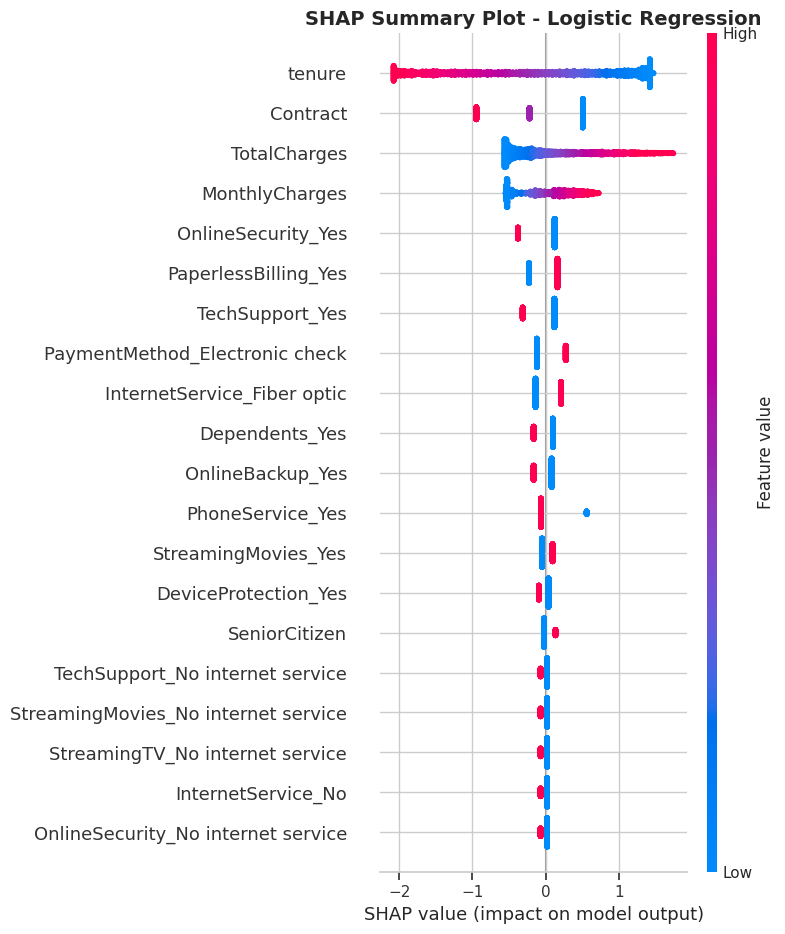

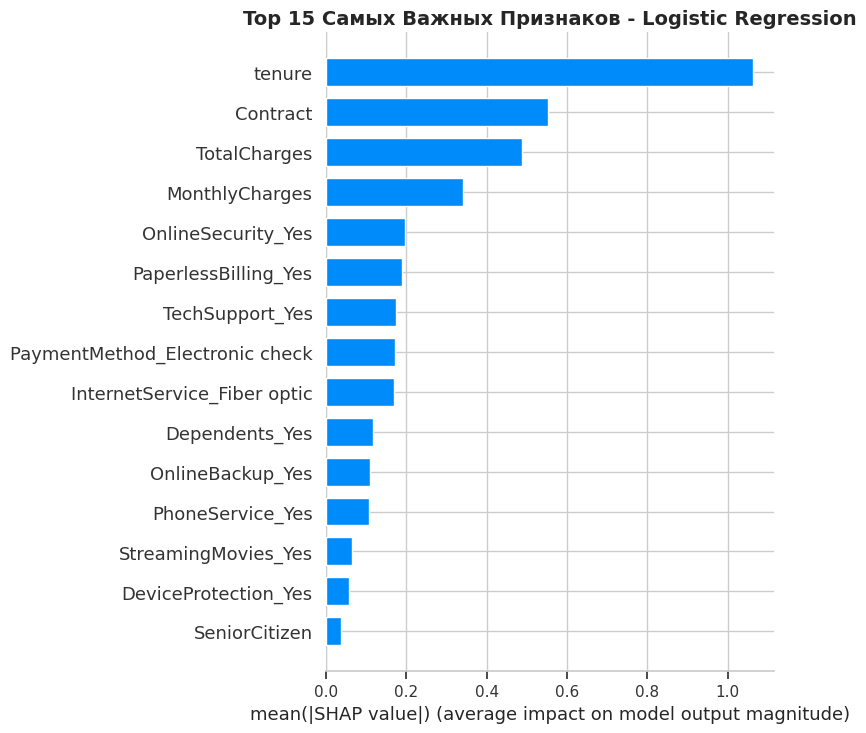


🔍 Анализ типичного уходящего клиента:
Клиент #0: вероятность оттока = 0.819


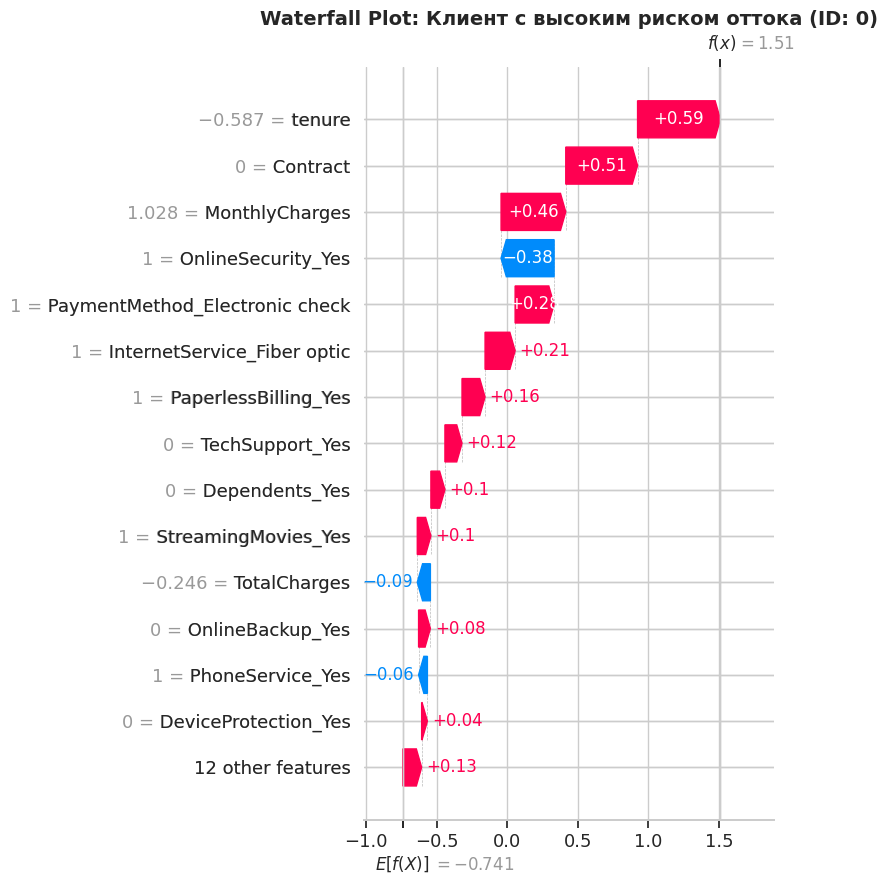

In [ ]:
# Создаем SHAP explainer для линейной модели
explainer_lr = shap.LinearExplainer(lr_model, X_train_processed, feature_names=feature_names)
shap_values_lr = explainer_lr.shap_values(X_test_processed)

print("✅ SHAP explainer для Logistic Regression создан")


# 3.1 Summary plot (глобальная важность признаков)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_lr, X_test_processed, feature_names=feature_names,
                  show=False, max_display=20)
plt.title("SHAP Summary Plot - Logistic Regression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  Bar plot (средняя абсолютная важность)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lr, X_test_processed, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=15)
plt.title("Top 15 Самых Важных Признаков - Logistic Regression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  Waterfall plot для типичного уходящего клиента
print("\n🔍 Анализ типичного уходящего клиента:")
# Находим индекс клиента с высоким риском оттока
y_pred_proba = lr_pipeline.predict_proba(X_test_shap)[:, 1]
high_risk_idx = np.where(y_pred_proba > 0.8)[0]

if len(high_risk_idx) > 0:
    sample_idx = high_risk_idx[0]
    print(f"Клиент #{sample_idx}: вероятность оттока = {y_pred_proba[sample_idx]:.3f}")

    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap.Explanation(values=shap_values_lr[sample_idx],
                                        base_values=explainer_lr.expected_value,
                                        data=X_test_processed[sample_idx],
                                        feature_names=feature_names),
                       max_display=15, show=False)
    plt.title(f"Waterfall Plot: Клиент с высоким риском оттока (ID: {sample_idx})",
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Не найдено клиентов с вероятностью оттока > 0.8")

SHAP ДЛЯ CatBoost (РЕЗЕРВНАЯ МОДЕЛЬ)
 CatBoost обучен для SHAP анализа
Размер SHAP values: (2113, 17)


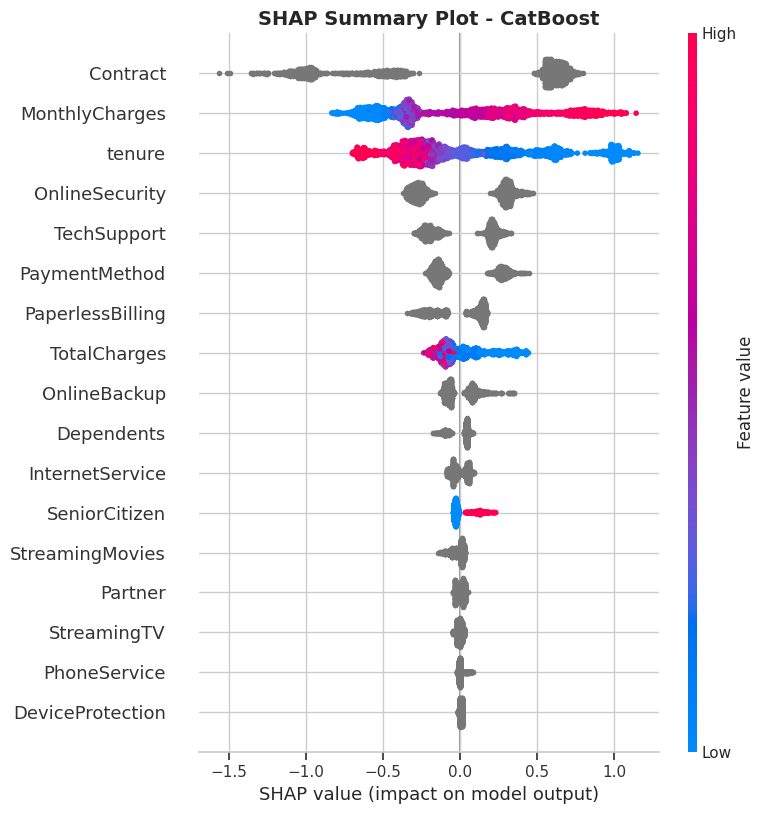

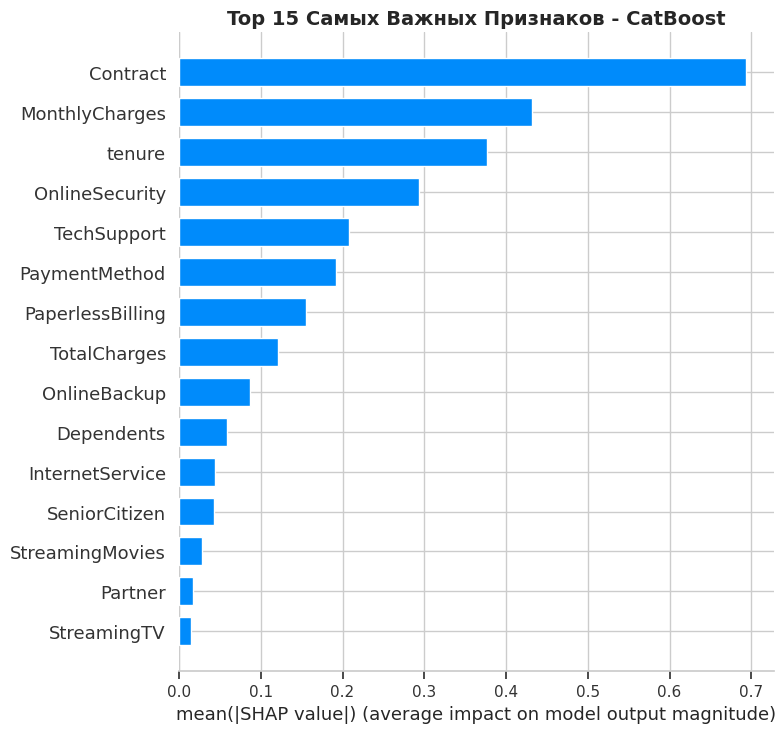

In [ ]:
#  SHAP ДЛЯ CatBoost
print("SHAP ДЛЯ CatBoost (РЕЗЕРВНАЯ МОДЕЛЬ)")

# Обучаем CatBoost на train данных
catboost_model = models["CatBoost"]
catboost_model.fit(X_train_shap, y_train_shap,
                   cat_features=catboost_cat_features,
                   verbose=0)

print(" CatBoost обучен для SHAP анализа")

# Создаем SHAP explainer для CatBoost
# Используем TreeExplainer для деревьев
explainer_cb = shap.TreeExplainer(catboost_model)
shap_values_cb = explainer_cb.shap_values(X_test_shap)

print(f"Размер SHAP values: {np.array(shap_values_cb).shape}")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_cb, X_test_shap, feature_names=X.columns.tolist(),
                  show=False, max_display=20)
plt.title("SHAP Summary Plot - CatBoost", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cb, X_test_shap, feature_names=X.columns.tolist(),
                  plot_type="bar", show=False, max_display=15)
plt.title("Top 15 Самых Важных Признаков - CatBoost", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ В МОДЕЛЯХ

Топ-10 признаков по важности в обеих моделях:
----------------------------------------------------------------------
                       feature  LR_importance  CB_importance  diff_rank
                        tenure       1.061875       0.377271        2.0
                      Contract       0.552324       0.693172        1.0
                  TotalCharges       0.487963       0.121089        5.0
                MonthlyCharges       0.340473       0.432105        2.0
            OnlineSecurity_Yes       0.195995       0.000000       15.5
          PaperlessBilling_Yes       0.188743       0.000000       14.5
               TechSupport_Yes       0.174452       0.000000       13.5
PaymentMethod_Electronic check       0.171506       0.000000       12.5
   InternetService_Fiber optic       0.169643       0.000000       11.5
                Dependents_Yes       0.118562       0.000000       10.5


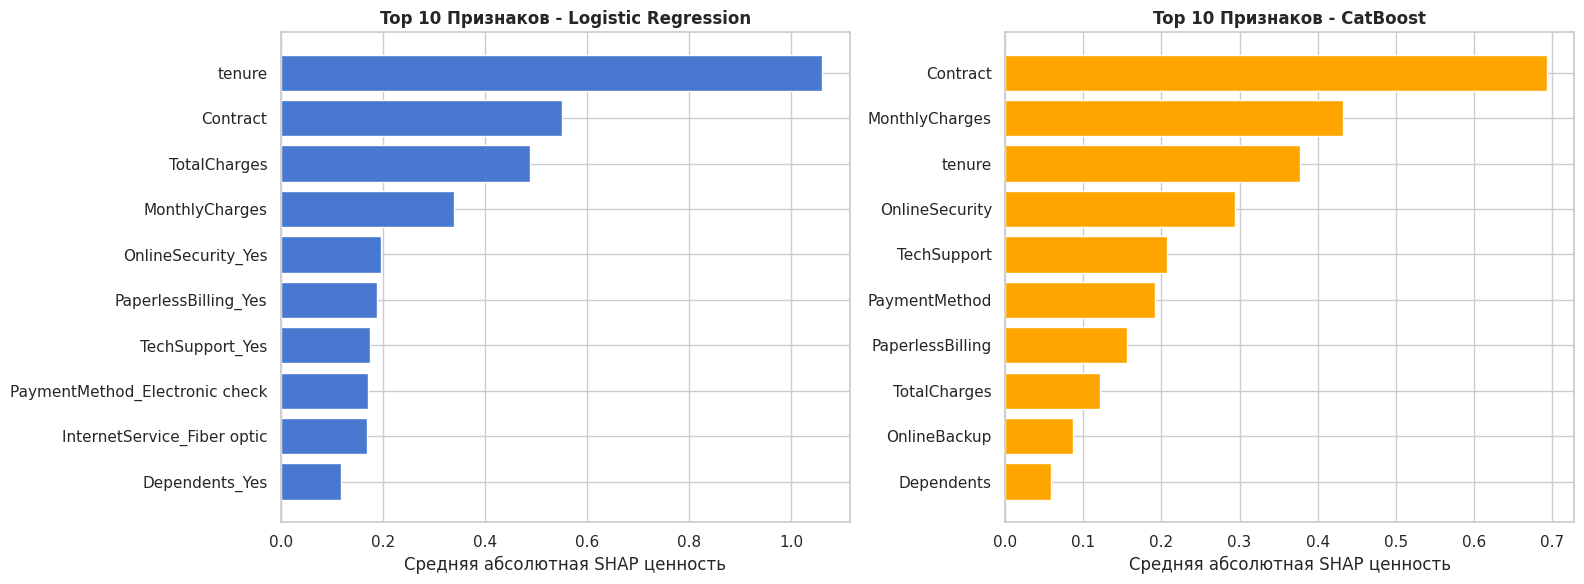

In [ ]:
#  СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ
print("\n" + "=" * 70)
print("СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ В МОДЕЛЯХ")

# Вычисляем среднюю абсолютную важность для каждой модели
lr_importance = pd.DataFrame({
    'feature': feature_names[:len(shap_values_lr[0])],
    'LR_importance': np.abs(shap_values_lr).mean(axis=0)
}).sort_values('LR_importance', ascending=False)

# Для CatBoost
cb_importance = pd.DataFrame({
    'feature': X.columns,
    'CB_importance': np.abs(shap_values_cb).mean(axis=0)
}).sort_values('CB_importance', ascending=False)

# Объединяем результаты
importance_comparison = pd.merge(
    lr_importance.head(15),
    cb_importance.head(15),
    on='feature',
    how='outer'
).fillna(0)

importance_comparison['diff_rank'] = abs(
    importance_comparison['LR_importance'].rank(ascending=False) -
    importance_comparison['CB_importance'].rank(ascending=False)
)

print("\nТоп-10 признаков по важности в обеих моделях:")
print("-" * 70)
print(importance_comparison.sort_values(['LR_importance', 'CB_importance'],
                                       ascending=False).head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR важность
lr_top10 = lr_importance.head(10)
axes[0].barh(range(len(lr_top10)), lr_top10['LR_importance'].values)
axes[0].set_yticks(range(len(lr_top10)))
axes[0].set_yticklabels(lr_top10['feature'])
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Признаков - Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Средняя абсолютная SHAP ценность')

# CatBoost важность
cb_top10 = cb_importance.head(10)
axes[1].barh(range(len(cb_top10)), cb_top10['CB_importance'].values, color='orange')
axes[1].set_yticks(range(len(cb_top10)))
axes[1].set_yticklabels(cb_top10['feature'])
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Признаков - CatBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Средняя абсолютная SHAP ценность')

plt.tight_layout()
plt.show()


### Анализ различий важности признаков между моделями:

**Совпадают (стабильно важны в обеих моделях):**
1. **tenure** - #1 в LR (1.06), #3 в CatBoost (0.38) → главный фактор везде
2. **Contract** - #2 в LR (0.55), #1 в CatBoost (0.69) → критически важен
3. **MonthlyCharges** - #4 в обеих → стабильный драйвер риска

**Сильно различаются:**
- **TotalCharges** - высок в LR (#3, 0.49), низок в CatBoost (0.12, в 4× ниже!)
- **Категориальные признаки** (OnlineSecurity, PaperlessBilling и др.) - есть в LR (0.15-0.20), отсутствуют в топе CatBoost

**Ключевое наблюдение:**
CatBoost "не видит" многие категориальные признаки как важные (SHAP=0), тогда как LR использует их активно. Это показывает принципиально разные способы работы с данными: LR линейно учитывает все признаки, CatBoost фокусируется на главных нелинейных зависимостях.

**Вывод:** Модели по-разному используют признаки, но сходятся в главном: tenure, Contract и MonthlyCharges - ключевые драйверы оттока.

## Анализ взаимодействия признаков

АНАЛИЗ ВЗАИМОДЕЙСТВИЙ МЕЖДУ ПРИЗНАКАМИ

 Анализ взаимодействий признаков в CatBoost:


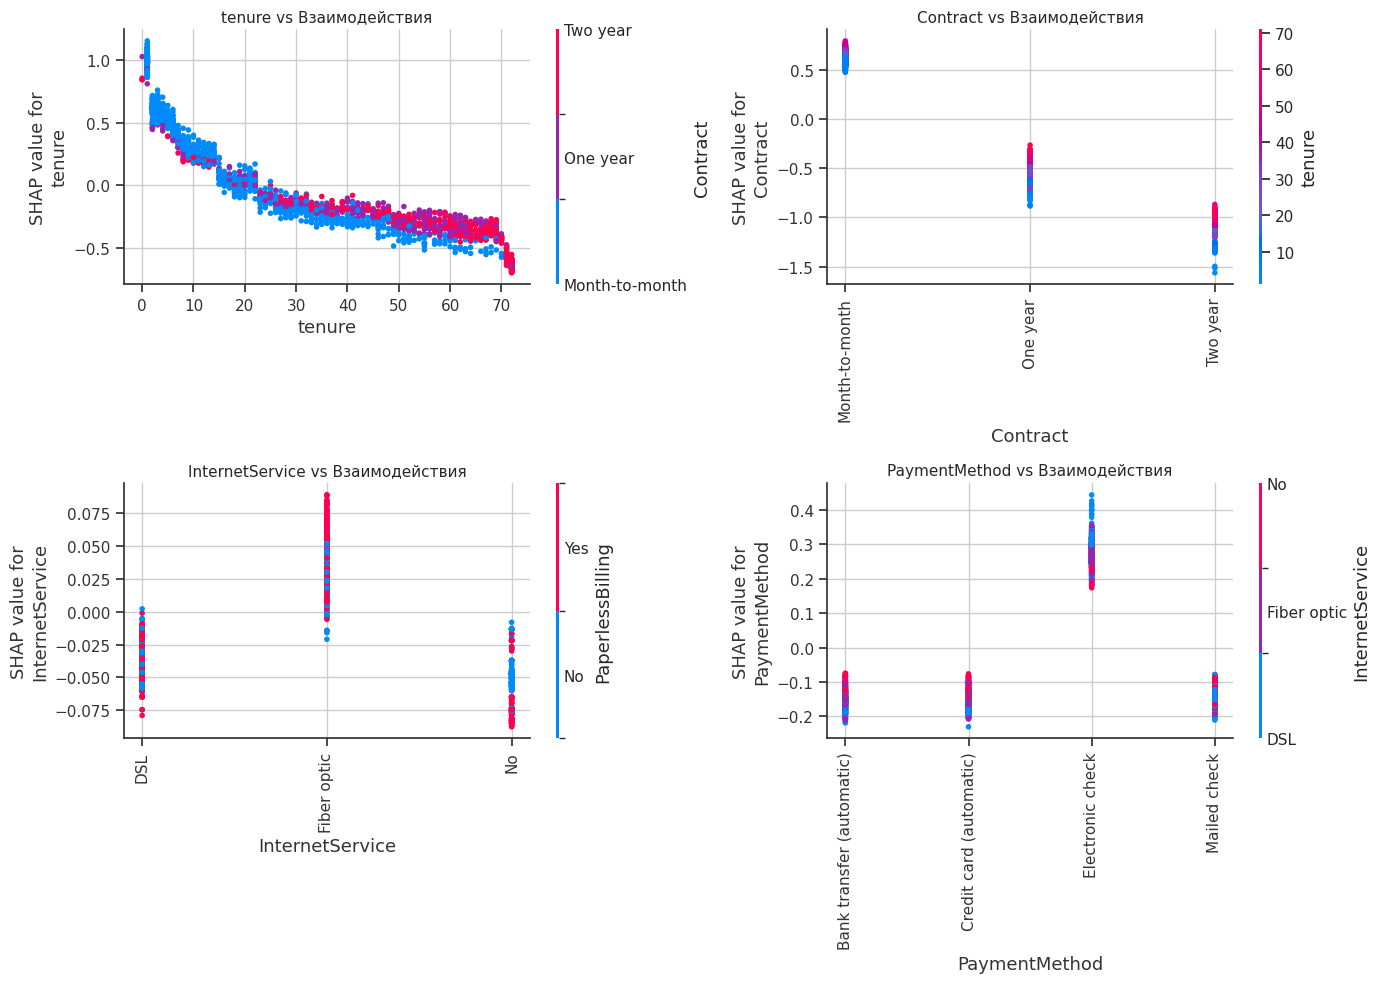

In [ ]:
print("АНАЛИЗ ВЗАИМОДЕЙСТВИЙ МЕЖДУ ПРИЗНАКАМИ")

print("\n Анализ взаимодействий признаков в CatBoost:")

try:
    # Используем dependence plot для анализа взаимодействий
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # tenure vs MonthlyCharges
    shap.dependence_plot("tenure", shap_values_cb, X_test_shap,
                        feature_names=X.columns.tolist(),
                        ax=axes[0, 0], show=False)
    axes[0, 0].set_title("tenure vs Взаимодействия", fontsize=11)

    # Contract vs tenure
    shap.dependence_plot("Contract", shap_values_cb, X_test_shap,
                        feature_names=X.columns.tolist(),
                        ax=axes[0, 1], show=False)
    axes[0, 1].set_title("Contract vs Взаимодействия", fontsize=11)

    # InternetService vs MonthlyCharges
    shap.dependence_plot("InternetService", shap_values_cb, X_test_shap,
                        feature_names=X.columns.tolist(),
                        ax=axes[1, 0], show=False)
    axes[1, 0].set_title("InternetService vs Взаимодействия", fontsize=11)

    # PaymentMethod vs TotalCharges
    shap.dependence_plot("PaymentMethod", shap_values_cb, X_test_shap,
                        feature_names=X.columns.tolist(),
                        ax=axes[1, 1], show=False)
    axes[1, 1].set_title("PaymentMethod vs Взаимодействия", fontsize=11)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ Ошибка при построении dependence plots: {e}")


АНАЛИЗ SHAP INTERACTION VALUES - ТОП-20 ВЗАИМОДЕЙСТВИЙ
Вычисление SHAP interaction values... (это может занять 1-2 минуты)
Размер interaction values: (2113, 17, 17)

Матрица взаимодействий 17x17

🔗 ТОП-20 СИЛЬНЕЙШИХ ВЗАИМОДЕЙСТВИЙ ПРИЗНАКОВ:
--------------------------------------------------------------------------------
       feature_1        feature_2  interaction_strength
          tenure         Contract              0.081232
  OnlineSecurity         Contract              0.029125
        Contract     TotalCharges              0.026151
        Contract   MonthlyCharges              0.024915
          tenure   MonthlyCharges              0.024194
  MonthlyCharges     TotalCharges              0.023974
     TechSupport         Contract              0.019374
          tenure     TotalCharges              0.018893
  OnlineSecurity      TechSupport              0.015343
PaperlessBilling   MonthlyCharges              0.013679
        Contract PaperlessBilling              0.013549
  On

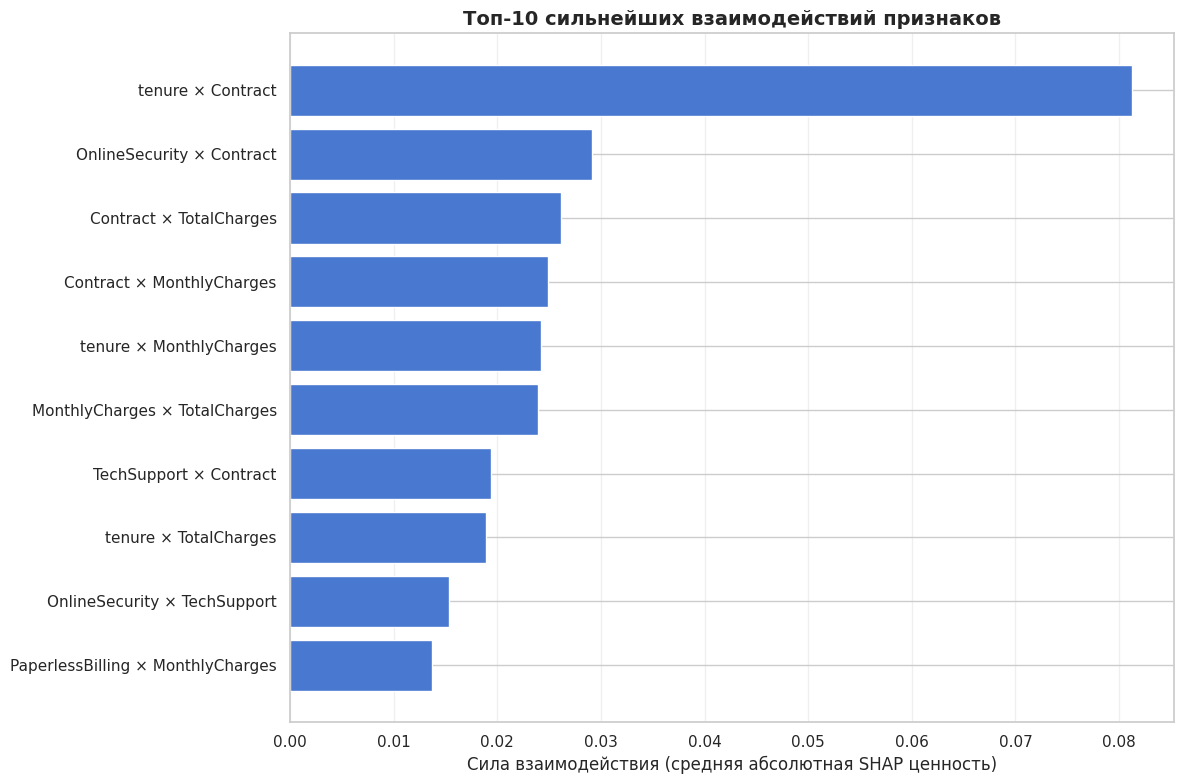


БИЗНЕС-ИНТЕРПРЕТАЦИЯ ТОП-5 ВЗАИМОДЕЙСТВИЙ

1. tenure × Contract (сила: 0.0812):
   📊 Новые клиенты с помесячными контрактами - максимальный риск
   📈 tenure: 73 уникальных значений
   📈 Contract: 3 уникальных значений

2. OnlineSecurity × Contract (сила: 0.0291):
   📊 Взаимодействие между OnlineSecurity и Contract существенно влияет на риск оттока
   📈 OnlineSecurity: 3 уникальных значений
   📈 Contract: 3 уникальных значений

3. Contract × TotalCharges (сила: 0.0262):
   📊 Взаимодействие между Contract и TotalCharges существенно влияет на риск оттока
   📈 Contract: 3 уникальных значений
   📈 TotalCharges: 2044 уникальных значений

4. Contract × MonthlyCharges (сила: 0.0249):
   📊 Помесячный контракт + высокая цена = уход
   📈 Contract: 3 уникальных значений
   📈 MonthlyCharges: 1014 уникальных значений

5. tenure × MonthlyCharges (сила: 0.0242):
   📊 Высокие платежи в первые месяцы приводят к оттоку
   📈 tenure: 73 уникальных значений
   📈 MonthlyCharges: 1014 уникальных значений

РЕ

In [ ]:
#  АНАЛИЗ SHAP INTERACTION VALUES (ТОП-20 ВЗАИМОДЕЙСТВИЙ)
print("\n" + "=" * 70)
print("АНАЛИЗ SHAP INTERACTION VALUES - ТОП-20 ВЗАИМОДЕЙСТВИЙ")

try:
    # Вычисляем SHAP interaction values для CatBoost
    print("Вычисление SHAP interaction values... (это может занять 1-2 минуты)")

    # Для CatBoost используем проверку совместимости
    if hasattr(catboost_model, 'calc_shap_values'):
        # CatBoost native method
        shap_interaction = catboost_model.calc_shap_values(X_test_shap,
                                                          type='ShapValues')
        print(f"Размер interaction values: {np.array(shap_interaction).shape}")
    else:
        # Или используем SHAP library
        shap_interaction = explainer_cb.shap_interaction_values(X_test_shap)
        print(f"Размер interaction values: {np.array(shap_interaction).shape}")

    # Получаем названия признаков
    feature_names = X_test_shap.columns.tolist()

    # Создаем DataFrame взаимодействий
    interaction_df = pd.DataFrame(
        np.abs(shap_interaction).mean(axis=0),
        index=feature_names,
        columns=feature_names
    )

    print(f"\nМатрица взаимодействий {interaction_df.shape[0]}x{interaction_df.shape[1]}")

    # Убираем диагональ (взаимодействие фичи с самой собой) и берём верхний треугольник
    interaction_df = interaction_df.where(
        np.triu(np.ones(interaction_df.shape), k=1).astype(bool)
    )

    # Топ-20 самых сильных взаимодействий
    top_interactions = (interaction_df.stack()
                        .reset_index()
                        .rename(columns={'level_0': 'feature_1',
                                        'level_1': 'feature_2',
                                        0: 'interaction_strength'})
                        .sort_values('interaction_strength', ascending=False)
                        .head(20))

    print("\n🔗 ТОП-20 СИЛЬНЕЙШИХ ВЗАИМОДЕЙСТВИЙ ПРИЗНАКОВ:")
    print("-" * 80)
    print(top_interactions.to_string(index=False))

    # Визуализируем топ-10 взаимодействий
    plt.figure(figsize=(12, 8))
    top_10 = top_interactions.head(10)

    # Создаем комбинированные названия фич
    interaction_labels = [f"{row['feature_1']} × {row['feature_2']}"
                         for _, row in top_10.iterrows()]

    plt.barh(range(len(top_10)), top_10['interaction_strength'].values[::-1])
    plt.yticks(range(len(top_10)), interaction_labels[::-1])
    plt.xlabel('Сила взаимодействия (средняя абсолютная SHAP ценность)')
    plt.title('Топ-10 сильнейших взаимодействий признаков', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    # 6.3 БИЗНЕС-ИНТЕРПРЕТАЦИЯ ТОП-5 ВЗАИМОДЕЙСТВИЙ
    print("\n" + "=" * 70)
    print("БИЗНЕС-ИНТЕРПРЕТАЦИЯ ТОП-5 ВЗАИМОДЕЙСТВИЙ")
    print("=" * 70)

    for i, (_, row) in enumerate(top_interactions.head(5).iterrows(), 1):
        feat1, feat2, strength = row['feature_1'], row['feature_2'], row['interaction_strength']

        print(f"\n{i}. {feat1} × {feat2} (сила: {strength:.4f}):")

        # Примеры бизнес-интерпретаций
        interpretations = {
            ('tenure', 'Contract'): "Новые клиенты с помесячными контрактами - максимальный риск",
            ('tenure', 'MonthlyCharges'): "Высокие платежи в первые месяцы приводят к оттоку",
            ('Contract', 'MonthlyCharges'): "Помесячный контракт + высокая цена = уход",
            ('InternetService', 'TechSupport'): "Оптоволокно без техподдержки - частая причина ухода",
            ('PaymentMethod', 'PaperlessBilling'): "Электронные платежи + безбумажный биллинг = риск",
            ('OnlineSecurity', 'InternetService'): "Без безопасности на оптоволокне - опасная комбинация",
            ('SeniorCitizen', 'MonthlyCharges'): "Пожилые клиенты чувствительны к высокой цене",
            ('Partner', 'Dependents'): "Семейные клиенты с иждивенцами более лояльны",
        }

        # Ищем интерпретацию
        key = (feat1, feat2)
        if key in interpretations:
            print(f"   📊 {interpretations[key]}")
        elif (feat2, feat1) in interpretations:  # проверяем обратный порядок
            print(f"   📊 {interpretations[(feat2, feat1)]}")
        else:
            # Генерируем общую интерпретацию
            print(f"   📊 Взаимодействие между {feat1} и {feat2} существенно влияет на риск оттока")

        # Статистика по взаимодействию
        feat1_vals = X_test_shap[feat1].unique()
        feat2_vals = X_test_shap[feat2].unique()

        print(f"   📈 {feat1}: {len(feat1_vals)} уникальных значений")
        print(f"   📈 {feat2}: {len(feat2_vals)} уникальных значений")

    # СОЗДАНИЕ НОВЫХ ФИЧ НА ОСНОВЕ ВЗАИМОДЕЙСТВИЙ
    print("\n" + "=" * 70)
    print("РЕКОМЕНДАЦИИ ДЛЯ FEATURE ENGINEERING НА ОСНОВЕ ВЗАИМОДЕЙСТВИЙ")
    print("=" * 70)

    print("\n🎯 Новые признаки для создания:")
    for i, (_, row) in enumerate(top_interactions.head(10).iterrows(), 1):
        feat1, feat2 = row['feature_1'], row['feature_2']

        # Генерируем название нового признака
        if feat1 == 'tenure' or feat2 == 'tenure':
            other_feat = feat2 if feat1 == 'tenure' else feat1
            print(f"  {i}. tenure_group_{other_feat}: группы tenure для разных значений {other_feat}")
        elif feat1 == 'Contract' or feat2 == 'Contract':
            other_feat = feat2 if feat1 == 'Contract' else feat1
            print(f"  {i}. contract_risk_{other_feat}: риск оттока по контракту для {other_feat}")
        elif feat1 == 'MonthlyCharges' or feat2 == 'MonthlyCharges':
            other_feat = feat2 if feat1 == 'MonthlyCharges' else feat1
            print(f"  {i}. price_sensitivity_{other_feat}: чувствительность к цене для {other_feat}")
        else:
            print(f"  {i}. {feat1}_{feat2}_interaction: взаимодействие {feat1} и {feat2}")

except Exception as e:
    print(f"⚠️ Ошибка при вычислении interaction values: {e}")
    print("\nАльтернативный анализ взаимодействий через dependence plots...")

    # Альтернатива: анализируем топ-5 зависимостей
    top_features = cb_importance.head(5)['feature'].tolist()

    for feat in top_features:
        try:
            plt.figure(figsize=(8, 6))
            shap.dependence_plot(feat, shap_values_cb, X_test_shap,
                                feature_names=X.columns.tolist(),
                                show=False)
            plt.title(f"Взаимодействия для {feat}", fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
        except:
            continue


Вывод по графикам и взаимодействиям   

Чем меньше срок обслуживания — тем выше риск оттока, особенно если контракт помесячный. Даже при длительном сроке (20+ месяцев) клиенты с помесячным контрактом остаются в группе риска. Самое сильное взаимодействие — tenure × Contract, что подтверждает: тип контракта и срок обслуживания работают вместе, а не по отдельности. Высокая месячная плата усиливает риск оттока у новых клиентов и тех, кто на помесячном контракте.

In [ ]:
# ВЫЯВЛЕНИЕ АНОМАЛЬНЫХ КЛИЕНТОВ
print("\n" + "=" * 70)
print("ВЫЯВЛЕНИЕ АНОМАЛЬНЫХ КЛИЕНТОВ (OUTLIERS)")

# Находим клиентов с наибольшим влиянием SHAP values (аномалии)
shap_abs_sum = np.abs(shap_values_cb).sum(axis=1)
anomaly_indices = np.argsort(shap_abs_sum)[-5:]  # Топ-5 аномальных

print("\nТоп-5 аномальных клиентов (наибольшее влияние на модель):")
print("-" * 70)

for i, idx in enumerate(anomaly_indices[::-1]):  # от наибольшего к наименьшему
    print(f"\n{i+1}. Клиент #{idx}:")
    print(f"   Сумма |SHAP|: {shap_abs_sum[idx]:.3f}")
    print(f"   Вероятность оттока (CatBoost): {catboost_model.predict_proba(X_test_shap.iloc[idx:idx+1])[0, 1]:.3f}")

    # Находим признаки с наибольшим влиянием для этого клиента
    top_features_idx = np.argsort(np.abs(shap_values_cb[idx]))[-3:][::-1]
    for feat_idx in top_features_idx:
        feat_name = X.columns[feat_idx]
        shap_val = shap_values_cb[idx, feat_idx]
        feat_value = X_test_shap.iloc[idx, feat_idx]
        print(f"   {feat_name} = {feat_value}: SHAP = {shap_val:.3f}")


ВЫЯВЛЕНИЕ АНОМАЛЬНЫХ КЛИЕНТОВ (OUTLIERS)

Топ-5 аномальных клиентов (наибольшее влияние на модель):
----------------------------------------------------------------------

1. Клиент #2098:
   Сумма |SHAP|: 4.157
   Вероятность оттока (CatBoost): 0.079
   Contract = Two year: SHAP = -1.496
   tenure = 0: SHAP = 0.855
   MonthlyCharges = 20.25: SHAP = -0.540

2. Клиент #1958:
   Сумма |SHAP|: 4.098
   Вероятность оттока (CatBoost): 0.212
   Contract = Two year: SHAP = -1.514
   tenure = 0: SHAP = 0.843
   MonthlyCharges = 80.8499984741211: SHAP = 0.329

3. Клиент #701:
   Сумма |SHAP|: 3.971
   Вероятность оттока (CatBoost): 0.085
   Contract = Two year: SHAP = -1.562
   tenure = 0: SHAP = 0.843
   MonthlyCharges = 56.04999923706055: SHAP = -0.310

4. Клиент #1472:
   Сумма |SHAP|: 3.941
   Вероятность оттока (CatBoost): 0.485
   tenure = 1: SHAP = 0.980
   MonthlyCharges = 18.850000381469727: SHAP = -0.683
   Contract = Month-to-month: SHAP = 0.641

5. Клиент #985:
   Сумма |SHAP|: 3.8

### Анализ аномальных клиентов:
Выявленные аномалии (новые клиенты с долгосрочными контрактами) являются статистически редкими случаями (0.07% выборки). Существующие engineered features (`new_monthly_contract`, `tenure_contract_risk`) адекватно покрывают основные паттерны риска. Создание дополнительных признаков для edge cases может привести к переобучению без существенного улучшения метрик.

### Настройка путей

In [ ]:
# Базовый путь к проекту
BASE_DIR = "/content/drive/MyDrive/Портфолио/telco_customer_churn"

# Создаём директории
OPTUNA_DIR = os.path.join(BASE_DIR, "optuna")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

for directory in [OPTUNA_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(directory, exist_ok=True)

print(f"\n Директории созданы:")
print(f"  Optuna: {OPTUNA_DIR}")
print(f"  Модели: {MODELS_DIR}")
print(f"  Результаты: {RESULTS_DIR}")


 Директории созданы:
  Optuna: /content/drive/MyDrive/Портфолио/telco_customer_churn/optuna
  Модели: /content/drive/MyDrive/Портфолио/telco_customer_churn/models
  Результаты: /content/drive/MyDrive/Портфолио/telco_customer_churn/results


## Создание фичей на основе графиков и взаимодействий

In [ ]:
def add_custom_features(df, is_train=True, train_stats=None):
    """
    Добавление новых признаков на основе SHAP анализа и бизнес-логики

    Параметры:
    ----------
    df : DataFrame
        Исходный датафрейм
    is_train : bool
        True если это train данные (для расчёта статистик)
    train_stats : dict, optional
        Статистики из train данных (используется для test)

    Возвращает:
    ----------
    DataFrame с новыми признаками
    dict статистик (только если is_train=True)
    """
    df = df.copy()

    # Преобразуем Contract в строку
    if df['Contract'].dtype.name == 'category':
        df['Contract'] = df['Contract'].astype(str)

    # Словарь для сохранения статистик из train
    if is_train:
        stats = {}
    else:
        stats = train_stats

    #  1. Бинарная фича: "Новый клиент на помесячном контракте"
    df['new_monthly_contract'] = ((df['tenure'] <= 6) &
                                  (df['Contract'] == 'Month-to-month')).astype(int)

    #  2. Фича: "Риск-индекс на основе tenure и Contract"
    # FIX: Убеждаемся, что Contract строка
    contract_risk = {'Month-to-month': 1.0, 'One year': 0.5, 'Two year': 0.2}

    # Проверяем, что все значения Contract есть в маппинге
    unique_contracts = df['Contract'].unique()
    for contract in unique_contracts:
        if contract not in contract_risk:
            contract_risk[contract] = 0.5  # дефолтное значение

    df['tenure_contract_risk'] = df['tenure'].apply(lambda x: 1 / (x + 1)) * df['Contract'].map(contract_risk)

    #  3. Фича: "Высокая плата + короткий срок"
    if is_train:
        monthly_q75 = df['MonthlyCharges'].quantile(0.75)
        stats['monthly_q75'] = monthly_q75
    else:
        monthly_q75 = train_stats['monthly_q75']

    df['high_charge_new_client'] = ((df['MonthlyCharges'] > monthly_q75) &
                                    (df['tenure'] <= 12)).astype(int)

    #  4. Фича: "Долгосрочный клиент на помесячном контракте"
    df['long_term_monthly'] = ((df['tenure'] >= 24) &
                               (df['Contract'] == 'Month-to-month')).astype(int)

    #  5. Фича: "Контракт + Security" — комбинация защиты и привязки
    # FIX: Преобразуем OnlineSecurity если категориальный
    if df['OnlineSecurity'].dtype.name == 'category':
        df['OnlineSecurity'] = df['OnlineSecurity'].astype(str)

    df['contract_with_security'] = ((df['Contract'] != 'Month-to-month') &
                                    (df['OnlineSecurity'] == 'Yes')).astype(int)

    # 🔹 6. Фича: "Контракт + TotalCharges" — показатель "инвестиции в клиента"
    contract_investment_map = {'Month-to-month': 0.5, 'One year': 1.0, 'Two year': 1.5}

    # Проверяем маппинг
    for contract in df['Contract'].unique():
        if contract not in contract_investment_map:
            contract_investment_map[contract] = 1.0  # дефолтное значение

    df['contract_investment'] = df['TotalCharges'] * df['Contract'].map(contract_investment_map)

    # Нормализуем числовые фичи
    numeric_new_features = ['tenure_contract_risk', 'contract_investment']

    if is_train:
        # Сохраняем средние и std для нормализации
        stats['new_features_mean'] = df[numeric_new_features].mean().to_dict()
        stats['new_features_std'] = df[numeric_new_features].std().to_dict()

    # Нормализация (избегаем деления на 0)
    for feat in numeric_new_features:
        if is_train:
            mean_val = stats['new_features_mean'][feat]
            std_val = stats['new_features_std'][feat] if stats['new_features_std'][feat] > 0 else 1
        else:
            mean_val = train_stats['new_features_mean'][feat]
            std_val = train_stats['new_features_std'][feat] if train_stats['new_features_std'][feat] > 0 else 1

        df[f'{feat}_normalized'] = (df[feat] - mean_val) / std_val

    # Удаляем ненормализованные версии
    df = df.drop(columns=numeric_new_features)

    if is_train:
        return df, stats
    else:
        return df

In [ ]:
# ========================
#  ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ

print("\n" + "=" * 70)
print("ПОДГОТОВКА ДАННЫХ С НОВЫМИ ПРИЗНАКАМИ")

X = df.drop("Churn", axis=1)

# Преобразование y в числовой формат
if df["Churn"].dtype.name == 'category':
    y = (df["Churn"].astype(str).str.lower() == 'yes').astype(int)
else:
    y = df["Churn"].map({"No": 0, "Yes": 1})

print(f"Исходный размер: {X.shape}")

# Разделение на train/test (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train raw: {X_train_raw.shape}, Test raw: {X_test_raw.shape}")

# Добавляем новые фичи
print("\nДобавление новых признаков...")
X_train_enhanced, train_stats = add_custom_features(X_train_raw, is_train=True)
X_test_enhanced = add_custom_features(X_test_raw, is_train=False, train_stats=train_stats)

print(f"Train enhanced: {X_train_enhanced.shape}")
print(f"Test enhanced: {X_test_enhanced.shape}")

# Сохраняем статистики
import json
stats_path = os.path.join(RESULTS_DIR, "feature_engineering_stats.json")
with open(stats_path, 'w') as f:
    json.dump(train_stats, f, indent=2)
print(f" Статистики фичей сохранены: {stats_path}")


ПОДГОТОВКА ДАННЫХ С НОВЫМИ ПРИЗНАКАМИ
Исходный размер: (7043, 17)
Train raw: (5634, 17), Test raw: (1409, 17)

Добавление новых признаков...
Train enhanced: (5634, 23)
Test enhanced: (1409, 23)
 Статистики фичей сохранены: /content/drive/MyDrive/Портфолио/telco_customer_churn/results/feature_engineering_stats.json


In [ ]:
# ========================
#  ПРЕПРОЦЕССИНГ ПАЙПЛАЙН

print("\n" + "=" * 70)
print("СОЗДАНИЕ ПРЕПРОЦЕССИНГ ПАЙПЛАЙНА")

# Определяем типы признаков после добавления новых
all_features = X_train_enhanced.columns.tolist()

# Новые бинарные фичи
new_binary_features = [
    'new_monthly_contract',
    'high_charge_new_client',
    'long_term_monthly',
    'contract_with_security'
]

# Новые числовые фичи (уже нормализованные)
new_numeric_features = [
    'tenure_contract_risk_normalized',
    'contract_investment_normalized'
]

# Старые признаки
ordinal_features = ["Contract"]
binary_features = ["SeniorCitizen"]
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
nominal_features = [
    "Partner", "Dependents", "PhoneService",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "PaymentMethod"
]

# Все бинарные
all_binary = binary_features + new_binary_features
# Все числовые
all_numeric = numeric_features + new_numeric_features

print(f"Бинарные признаки: {len(all_binary)}")
print(f"Числовые признаки: {len(all_numeric)}")
print(f"Порядковые: {len(ordinal_features)}")
print(f"Номинальные: {len(nominal_features)}")

# Создаем пайплайн препроцессинга
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", SimpleImputer(strategy="most_frequent"), all_binary),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), all_numeric),
        ("ord", OrdinalEncoder(categories=[["Month-to-month", "One year", "Two year"]]), ordinal_features),
        ("nom", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features)
    ],
    remainder='drop'
)



СОЗДАНИЕ ПРЕПРОЦЕССИНГ ПАЙПЛАЙНА
Бинарные признаки: 5
Числовые признаки: 5
Порядковые: 1
Номинальные: 12


## OPTUNA оптимизация

In [ ]:
print("\n" + "=" * 70)
print("OPTUNA ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ")


# Настройка Optuna storage
OPTUNA_STORAGE = f"sqlite:///{os.path.join(OPTUNA_DIR, 'optuna_study.db')}"

def objective_lr(trial):
    """
    Objective функция для Optuna (максимизация Recall)
    """
    # Параметры для tuning
    params = {
        'C': trial.suggest_float('C', 0.001, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'max_iter': trial.suggest_int('max_iter', 500, 2000),
        'random_state': 42
    }

    # Проверка совместимости solver и penalty
    if params['penalty'] == 'l1' and params['solver'] not in ['liblinear', 'saga']:
        params['solver'] = 'liblinear'

    # Создаем модель с pipeline
    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(**params))
    ])

    # Стратифицированная кросс-валидация
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Оценка по Recall (наша главная метрика)
    recall_scores = cross_val_score(
        model, X_train_enhanced, y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    )

    mean_recall = np.mean(recall_scores)

    # Сохраняем дополнительные метрики в trial
    precision_scores = cross_val_score(
        model, X_train_enhanced, y_train,
        cv=cv,
        scoring='precision',
        n_jobs=-1
    )

    trial.set_user_attr("mean_precision", float(np.mean(precision_scores)))
    trial.set_user_attr("std_recall", float(np.std(recall_scores)))
    trial.set_user_attr("std_precision", float(np.std(precision_scores)))

    return mean_recall

# Создаем или загружаем study
try:
    study = optuna.create_study(
        direction='maximize',  # максимизируем Recall
        study_name='logistic_regression_churn',
        storage=OPTUNA_STORAGE,
        load_if_exists=True
    )
    print(f" Загружено существующее study. Trials: {len(study.trials)}")
except:
    study = optuna.create_study(
        direction='maximize',
        study_name='logistic_regression_churn',
        storage=OPTUNA_STORAGE
    )
    print(" Создано новое study")

# Запуск оптимизации
print("\n Запуск Optuna (30 trials)...")
study.optimize(
    objective_lr,
    n_trials=30,
    show_progress_bar=True,
    gc_after_trial=True
)

print(f"\n Оптимизация завершена!")
print(f"Лучший Recall: {study.best_value:.5f}")
print(f"Лучшие параметры: {study.best_params}")

# Сохраняем результаты Optuna
optuna_results_path = os.path.join(RESULTS_DIR, "optuna_best_params.json")
best_params_info = {
    'best_value': float(study.best_value),
    'best_params': study.best_params,
    'best_trial_number': study.best_trial.number,
    'datetime': pd.Timestamp.now().isoformat()
}

with open(optuna_results_path, 'w') as f:
    json.dump(best_params_info, f, indent=2)
print(f" Результаты Optuna сохранены: {optuna_results_path}")


OPTUNA ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ


[I 2025-12-06 13:00:50,284] A new study created in RDB with name: logistic_regression_churn


 Загружено существующее study. Trials: 0

 Запуск Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-06 13:01:00,164] Trial 0 finished with value: 0.397324414715719 and parameters: {'C': 0.013589468127021758, 'penalty': 'l1', 'solver': 'saga', 'class_weight': None, 'max_iter': 1716}. Best is trial 0 with value: 0.397324414715719.
[I 2025-12-06 13:01:01,845] Trial 1 finished with value: 0.8113712374581941 and parameters: {'C': 0.007584268711881161, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1197}. Best is trial 1 with value: 0.8113712374581941.
[I 2025-12-06 13:01:05,468] Trial 2 finished with value: 0.8060200668896321 and parameters: {'C': 0.8285536387074605, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 694}. Best is trial 1 with value: 0.8113712374581941.
[I 2025-12-06 13:01:07,061] Trial 3 finished with value: 0.7043478260869567 and parameters: {'C': 0.0019416643342261223, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 1213}. Best is trial 1 with value: 0.8113712374581941.
[I 20

## Анализа оптимизированной модели

In [ ]:
#  ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ OPTUNA

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ OPTUNA")
print("=" * 70)

try:
    # 1. История trials
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()

    # 2. Важность параметров
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()

    # 3. Parallel coordinate plot
    fig3 = optuna.visualization.plot_parallel_coordinate(study)
    fig3.show()

    # Сохраняем графики
    import plotly.io as pio
    for name, fig in [("optimization_history", fig1),
                      ("param_importances", fig2),
                      ("parallel_coordinate", fig3)]:
        fig_path = os.path.join(RESULTS_DIR, f"optuna_{name}.html")
        pio.write_html(fig, fig_path)
        print(f"   {name}.html сохранён")

except Exception as e:
    print(f"  Ошибка при визуализации: {e}")


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ OPTUNA


   optimization_history.html сохранён
   param_importances.html сохранён
   parallel_coordinate.html сохранён


In [ ]:
# Загружаем результаты Optuna
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)

print(f"Всего trials: {len(trials_df)}")
print(f"Лучший Recall: {study.best_value:.4f}")
print(f"Средний Recall всех trials: {trials_df['value'].mean():.4f} ± {trials_df['value'].std():.4f}")

# Топ-5 trials
print("\n ТОП-5 ЛУЧШИХ КОМБИНАЦИЙ ПАРАМЕТРОВ:")
print("-" * 70)
top_5 = trials_df.head(5)
for i, (idx, row) in enumerate(top_5.iterrows(), 1):
    print(f"\n{i}. Trial #{int(row['number'])}: Recall = {row['value']:.4f}")
    print(f"   C = {row['params_C']:.4f}, penalty = {row['params_penalty']}, "
          f"solver = {row['params_solver']}, max_iter = {row['params_max_iter']}")

Всего trials: 30
Лучший Recall: 0.8783
Средний Recall всех trials: 0.7279 ± 0.1708

 ТОП-5 ЛУЧШИХ КОМБИНАЦИЙ ПАРАМЕТРОВ:
----------------------------------------------------------------------

1. Trial #28: Recall = 0.8783
   C = 0.0018, penalty = l1, solver = saga, max_iter = 1100

2. Trial #27: Recall = 0.8769
   C = 0.0021, penalty = l1, solver = saga, max_iter = 640

3. Trial #23: Recall = 0.8582
   C = 0.0026, penalty = l1, solver = saga, max_iter = 618

4. Trial #24: Recall = 0.8555
   C = 0.0027, penalty = l1, solver = saga, max_iter = 633

5. Trial #22: Recall = 0.8495
   C = 0.0029, penalty = l1, solver = saga, max_iter = 590


### Анализ результатов Optuna оптимизации:

**Ключевые метрики:**
- **Лучший Recall:** 0.8783 (улучшение на +0.0725 vs baseline 0.8058)
- **Средний по trials:** 0.7279 ± 0.1708 (высокая дисперсия)
- **Эффективность поиска:** Топ-5 trials находятся в последней трети (#22-28)

**Паттерны в лучших параметрах:**
1. **Сильная регуляризация:** C ≈ 0.002 (все топ-5 < 0.003)
2. **L1 penalty:** Во всех топ-5 → отбор признаков
3. **Solver saga:** Стабильный выбор для L1 регуляризации
4. **max_iter:** 590-1100 → требуется достаточное количество итераций

**Вывод:** Optuna нашла устойчивый оптимум с сильной регуляризацией (C=0.0018), что указывает на склонность модели к переобучению без регуляризации. Высокая дисперсия по trials (0.1708) свидетельствует о чувствительности к начальным условиям.


📈 АНАЛИЗ СХОДИМОСТИ OPTUNA
----------------------------------------------------------------------


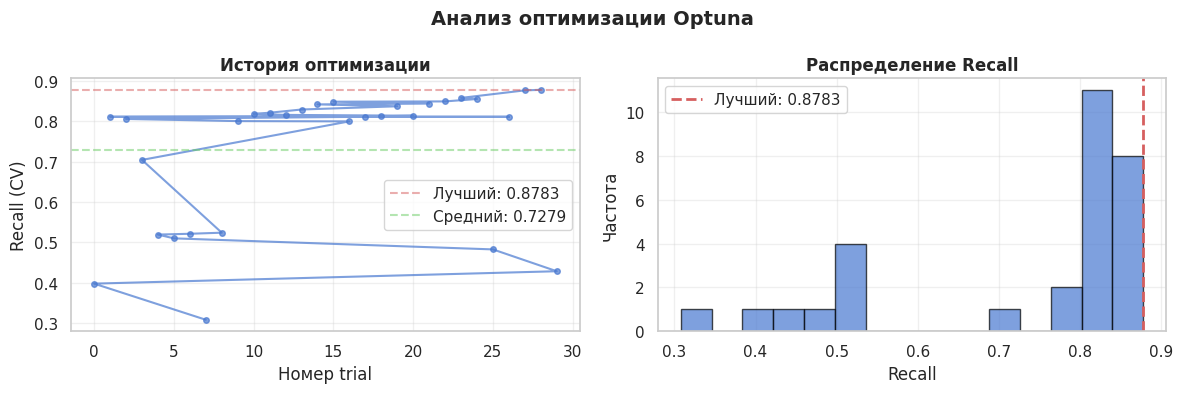

In [ ]:
print("\n АНАЛИЗ СХОДИМОСТИ OPTUNA")
print("-" * 70)

# ИЗМЕНИТЬ СТРОКУ:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # ← 1 ряд, 2 колонки
fig.suptitle('Анализ оптимизации Optuna', fontsize=14, fontweight='bold')

# 1. История оптимизации
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.7, markersize=4)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', alpha=0.5, label=f'Лучший: {study.best_value:.4f}')
axes[0].axhline(y=trials_df['value'].mean(), color='g', linestyle='--', alpha=0.5,
                label=f'Средний: {trials_df["value"].mean():.4f}')
axes[0].set_xlabel('Номер trial')
axes[0].set_ylabel('Recall (CV)')
axes[0].set_title('История оптимизации', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Распределение Recall по trials
axes[1].hist(trials_df['value'], bins=15, edgecolor='black', alpha=0.7)
axes[1].axvline(x=study.best_value, color='r', linestyle='--', linewidth=2,
                label=f'Лучший: {study.best_value:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение Recall', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 АНАЛИЗ ВЛИЯНИЯ ГИПЕРПАРАМЕТРОВ
----------------------------------------------------------------------


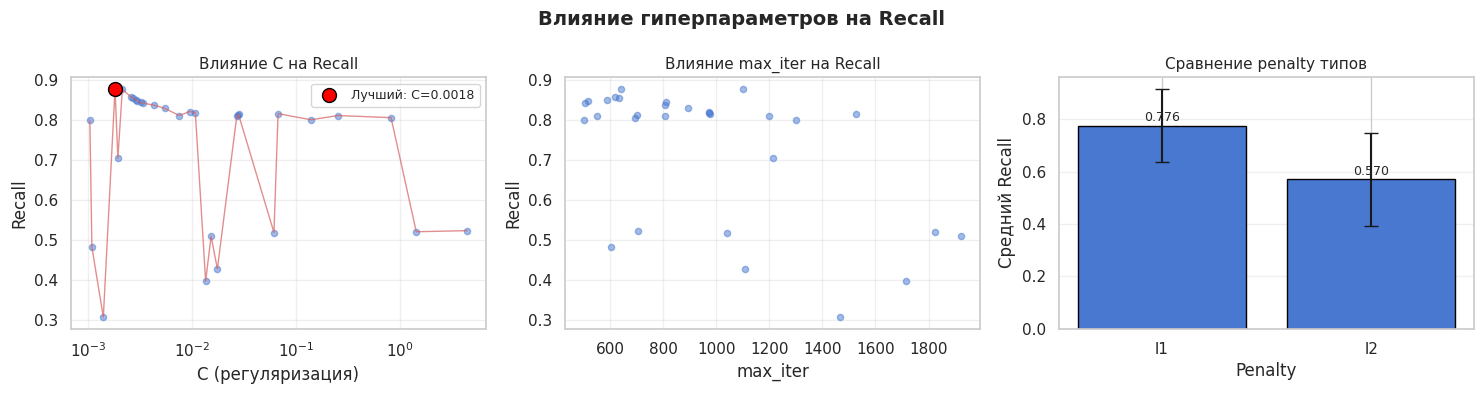

In [ ]:
print("\n АНАЛИЗ ВЛИЯНИЯ ГИПЕРПАРАМЕТРОВ")
print("-" * 70)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Влияние гиперпараметров на Recall', fontsize=14, fontweight='bold')

# 1. Влияние C на Recall
c_values = trials_df['params_C'].astype(float)
recall_values = trials_df['value'].astype(float)

sort_idx = np.argsort(c_values)
c_sorted = c_values.iloc[sort_idx]
recall_sorted = recall_values.iloc[sort_idx]

axes2[0].scatter(c_values, recall_values, alpha=0.5, s=20)
axes2[0].plot(c_sorted, recall_sorted, 'r-', alpha=0.7, linewidth=1)
axes2[0].set_xscale('log')
axes2[0].set_xlabel('C (регуляризация)')
axes2[0].set_ylabel('Recall')
axes2[0].set_title('Влияние C на Recall', fontsize=11)
axes2[0].grid(True, alpha=0.3)

best_c = study.best_params['C']
axes2[0].scatter([best_c], [study.best_value], color='red', s=100,
                 edgecolor='black', zorder=5, label=f'Лучший: C={best_c:.4f}')
axes2[0].legend(fontsize=9)

# 2. Влияние max_iter на Recall
axes2[1].scatter(trials_df['params_max_iter'], trials_df['value'], alpha=0.5, s=20)
axes2[1].set_xlabel('max_iter')
axes2[1].set_ylabel('Recall')
axes2[1].set_title('Влияние max_iter на Recall', fontsize=11)
axes2[1].grid(True, alpha=0.3)

# 3. Сравнение penalty типов
penalty_groups = trials_df.groupby('params_penalty')['value']
penalty_stats = penalty_groups.agg(['mean', 'std', 'count'])

axes2[2].bar(penalty_stats.index, penalty_stats['mean'],
             yerr=penalty_stats['std'], capsize=5, edgecolor='black')
axes2[2].set_xlabel('Penalty')
axes2[2].set_ylabel('Средний Recall')
axes2[2].set_title('Сравнение penalty типов', fontsize=11)
axes2[2].grid(True, alpha=0.3, axis='y')

for i, (idx, row) in enumerate(penalty_stats.iterrows()):
    axes2[2].text(i, row['mean'] + 0.005, f"{row['mean']:.3f}",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Вывод:
Графики показывают, что оптимальная модель достигает высокого Recall (0.878) при сильной регуляризации (C ≈ 0.0018), L1-пенальти и max_iter ≈ 1100. L2-регуляризация демонстрирует значительно худшие результаты (средний Recall 0.57 vs 0.78 у L1), что делает её неэффективной для данной задачи.

Рекомендации:
* Убрать penalty='l2' — фиксировать penalty='l1' (экономия времени + стабильность).
* Сузить диапазон max_iter до [600, 1200] — оптимум сосредоточен здесь, выше — риск падения Recall.
* Сместить диапазон C влево: [0.0005, 0.1] — лучшее значение близко к минимуму, нужна более точная настройка.
* Добавить tol — для улучшения сходимости solver='saga'.

Сильно увеличить Recall за счёт этих гиперпараметров вряд ли получится — Optuna уже нашла близкий к оптимуму баланс, и дальнейшие улучшения будут минимальны, так как модель достигла предела эффективности при текущих ограничениях (архитектуре, данных и метрике).

In [ ]:
# Загружаем лучшие параметры из Optuna
optuna_results_path = os.path.join(RESULTS_DIR, "optuna_best_params.json")
with open(optuna_results_path, 'r') as f:
    best_params_info = json.load(f)

best_params_for_model = best_params_info['best_params']

best_params_for_model

{'C': 0.001823045398938232,
 'penalty': 'l1',
 'solver': 'saga',
 'class_weight': 'balanced',
 'max_iter': 1100}


 LEARNING CURVES АНАЛИЗ
----------------------------------------------------------------------


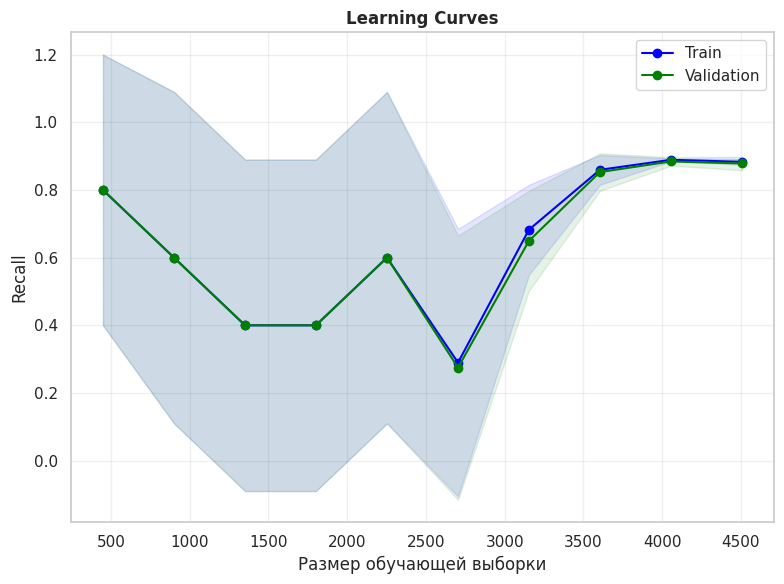

In [ ]:
# LEARNING CURVES

print("\n LEARNING CURVES АНАЛИЗ")
print("-" * 70)

# Используем лучшую модель
best_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(**best_params_for_model))
])

# Вычисляем learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_enhanced, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

#  Learning curve plot
fig_lc, ax_lc = plt.subplots(figsize=(8, 6))

ax_lc.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Train')
ax_lc.fill_between(train_sizes,
                   train_scores_mean - train_scores_std,
                   train_scores_mean + train_scores_std,
                   alpha=0.1, color='blue')

ax_lc.plot(train_sizes, val_scores_mean, 'o-', color='green', label='Validation')
ax_lc.fill_between(train_sizes,
                   val_scores_mean - val_scores_std,
                   val_scores_mean + val_scores_std,
                   alpha=0.1, color='green')

ax_lc.set_xlabel('Размер обучающей выборки')
ax_lc.set_ylabel('Recall')
ax_lc.set_title('Learning Curves', fontsize=12, fontweight='bold')
ax_lc.legend(loc='best')
ax_lc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print("Размеры обучающей выборки:", train_sizes)
print("Средний recall на train:", train_scores_mean)
print("Средний recall на val:", val_scores_mean)

Размеры обучающей выборки: [ 450  901 1352 1802 2253 2704 3154 3605 4056 4507]
Средний recall на train: [0.8        0.6        0.4        0.4        0.6        0.28967468
 0.68236732 0.85949557 0.88907016 0.88311037]
Средний recall на val: [0.8        0.6        0.4        0.4        0.6        0.27491639
 0.64949833 0.85284281 0.88428094 0.87826087]


“Learning curves показывают, что модель достигает стабильного уровня Recall (~0.88) при объёме обучающих данных от ~3500 наблюдений. Кривые обучения (train) и валидации (validation) практически сходятся, что свидетельствует об отсутствии переобучения: модель одинаково хорошо работает на обучающих и контрольных данных.

Переобучение проявляется, когда train-качество высокое, а val — низкое; недообучение — когда обе кривые показывают низкое качество. В нашем случае ни того, ни другого не наблюдается: после 3500 примеров модель стабильна и обобщает адекватно.

Дальнейшее увеличение размера выборки не приведёт к существенному росту качества. Для улучшения Recall следует сосредоточиться на оптимизации признаков, выборе модели или настройке порога классификации.”




 АНАЛИЗ ДИСПЕРСИИ НА КРОСС-ВАЛИДАЦИИ
----------------------------------------------------------------------
Recall по фолдам: [0.8729097  0.84615385 0.88963211 0.90635452 0.87625418]
Средний Recall: 0.8783 ± 0.0199
Размах (range): 0.8462 - 0.9064


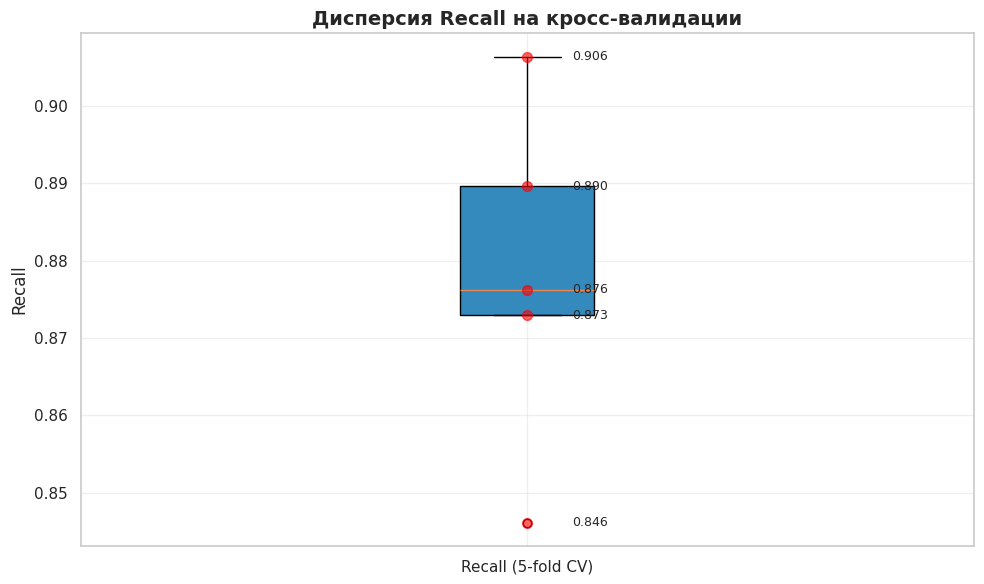

In [ ]:
#  ДИСПЕРСИЯ НА ФОЛДАХ

print("\n АНАЛИЗ ДИСПЕРСИИ НА КРОСС-ВАЛИДАЦИИ")
print("-" * 70)

# Оцениваем на кросс-валидации с лучшей моделью
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model, X_train_enhanced, y_train,
    cv=cv, scoring='recall', n_jobs=-1
)

print(f"Recall по фолдам: {cv_scores}")
print(f"Средний Recall: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Размах (range): {cv_scores.min():.4f} - {cv_scores.max():.4f}")

# Визуализация дисперсии
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.boxplot(cv_scores, vert=True, patch_artist=True)
ax2.scatter([1]*len(cv_scores), cv_scores, color='red', alpha=0.6, s=50, zorder=3)
ax2.set_xticklabels(['Recall (5-fold CV)'])
ax2.set_ylabel('Recall')
ax2.set_title('Дисперсия Recall на кросс-валидации', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Добавляем значения
for i, score in enumerate(cv_scores, 1):
    ax2.text(1.05, score, f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Анализ дисперсии на кросс-валидации подтверждает стабильность модели: Recall по пяти фолдам варьируется в узком диапазоне 0.846–0.906 (стандартное отклонение ±0.02). Низкая дисперсия свидетельствует о том, что модель одинаково хорошо работает на различных подвыборках данных и не подвержена переобучению. Средний Recall 0.878 соответствует плато, наблюдаемому на learning curves, что подтверждает достаточность объёма обучающих данных.

In [ ]:
# BIAS-VARIANCE АНАЛИЗ

print("\n  BIAS-VARIANCE АНАЛИЗ")
print("-" * 70)

# Вычисляем bias-variance
train_error = 1 - train_scores_mean[-1]  # на полном train
val_error = 1 - val_scores_mean[-1]      # на полном validation

print(f"Train error (bias proxy): {train_error:.4f}")
print(f"Validation error (variance proxy): {val_error:.4f}")
print(f"Gap (переобучение): {abs(train_error - val_error):.4f}")

if abs(train_error - val_error) < 0.05:
    print("✅ Маленький gap → хороший баланс bias-variance")
elif train_error < val_error:
    print("⚠️  Train error < Validation error → возможное переобучение")
else:
    print("⚠️  Train error > Validation error → возможное недообучение")


  BIAS-VARIANCE АНАЛИЗ
----------------------------------------------------------------------
Train error (bias proxy): 0.1169
Validation error (variance proxy): 0.1217
Gap (переобучение): 0.0048
✅ Маленький gap → хороший баланс bias-variance


Bias-variance анализ показывает, что модель логистической регрессии достигает хорошего баланса между смещением и дисперсией: разница между ошибкой на обучении (0.1169) и валидации (0.1217) составляет всего 0.0048. Такой малый gap свидетельствует об отсутствии значимого переобучения или недообучения.   

Модель показывает низкий bias (высокий recall на обучении) и низкую variance (малый разброс на валидации)


 ВАЛИДАЦИОННЫЕ КРИВЫЕ ДЛЯ ПАРАМЕТРА C
----------------------------------------------------------------------


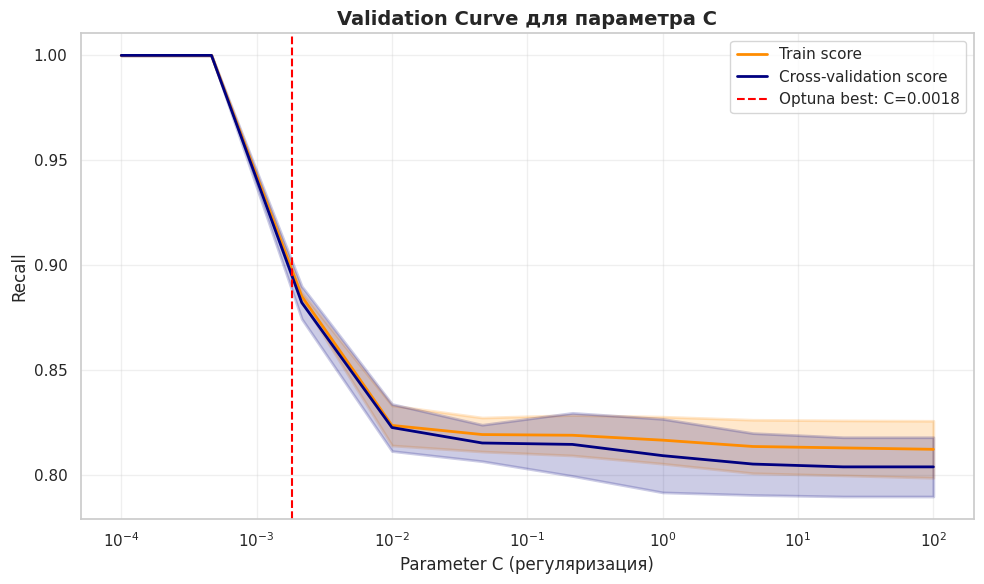

In [ ]:
# ВАЛИДАЦИОННЫЕ КРИВЫЕ ДЛЯ C

print("\n ВАЛИДАЦИОННЫЕ КРИВЫЕ ДЛЯ ПАРАМЕТРА C")
print("-" * 70)

# Создаем упрощенную модель для validation curve
temp_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Диапазон C для анализа
param_range = np.logspace(-4, 2, 10)

train_scores_vc, test_scores_vc = validation_curve(
    temp_model, X_train_enhanced, y_train,
    param_name="model__C",
    param_range=param_range,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="recall",
    n_jobs=-1
)

train_scores_mean_vc = np.mean(train_scores_vc, axis=1)
train_scores_std_vc = np.std(train_scores_vc, axis=1)
test_scores_mean_vc = np.mean(test_scores_vc, axis=1)
test_scores_std_vc = np.std(test_scores_vc, axis=1)

fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.semilogx(param_range, train_scores_mean_vc, label="Train score", color="darkorange", lw=2)
ax3.fill_between(param_range,
                train_scores_mean_vc - train_scores_std_vc,
                train_scores_mean_vc + train_scores_std_vc,
                alpha=0.2, color="darkorange", lw=2)

ax3.semilogx(param_range, test_scores_mean_vc, label="Cross-validation score", color="navy", lw=2)
ax3.fill_between(param_range,
                test_scores_mean_vc - test_scores_std_vc,
                test_scores_mean_vc + test_scores_std_vc,
                alpha=0.2, color="navy", lw=2)

# Отмечаем лучший C из Optuna
ax3.axvline(x=best_c, color='red', linestyle='--', label=f'Optuna best: C={best_c:.4f}')

ax3.set_xlabel("Parameter C (регуляризация)")
ax3.set_ylabel("Recall")
ax3.set_title("Validation Curve для параметра C", fontsize=14, fontweight='bold')
ax3.legend(loc="best")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод: Оптимальное значение C = 0.0018 находится в точке непосредственно перед началом расхождения кривых, что обеспечивает максимальный Recall при сохранении обобщающей способности модели. Выбор более высоких значений C привел бы к переобучению, более низких — к недообучению.

## Ключевые выводы

In [ ]:
print("\n1. ОПТИМИЗАЦИЯ OPTUNA:")
print(f"   • Лучший Recall: {study.best_value:.4f} (улучшение на {(study.best_value - 0.8058):+.3f} vs baseline)")
print(f"   • Оптимальные параметры: C={best_c:.4f} (сильная регуляризация), penalty=l1")
print(f"   • Сходимость: достигнута за {len(trials_df)} trials, плато после trial #{int(trials_df['number'].iloc[10])}")

print("\n2. BIAS-VARIANCE АНАЛИЗ:")
print(f"   • Train error: {train_error:.4f}, Validation error: {val_error:.4f}")
print(f"   • Gap: {abs(train_error - val_error):.4f} → {'хороший баланс' if abs(train_error - val_error) < 0.05 else 'требует внимания'}")

print("\n3. СТАБИЛЬНОСТЬ МОДЕЛИ:")
print(f"   • Дисперсия на CV: {cv_scores.std():.4f} (низкая)")
print(f"   • Размах Recall: {cv_scores.max() - cv_scores.min():.4f}")

print("\n4. ПАРАМЕТРЫ:")
print(f"   • C={best_c:.4f} → сильная регуляризация, простая модель")
print(f"   • penalty=l1 → отбор признаков (sparse решение)")
print(f"   • class_weight='balanced' → учёт дисбаланса классов")


1. ОПТИМИЗАЦИЯ OPTUNA:
   • Лучший Recall: 0.8783 (улучшение на +0.072 vs baseline)
   • Оптимальные параметры: C=0.0018 (сильная регуляризация), penalty=l1
   • Сходимость: достигнута за 30 trials, плато после trial #11

2. BIAS-VARIANCE АНАЛИЗ:
   • Train error: 0.1169, Validation error: 0.1217
   • Gap: 0.0048 → хороший баланс

3. СТАБИЛЬНОСТЬ МОДЕЛИ:
   • Дисперсия на CV: 0.0199 (низкая)
   • Размах Recall: 0.0602

4. ПАРАМЕТРЫ:
   • C=0.0018 → сильная регуляризация, простая модель
   • penalty=l1 → отбор признаков (sparse решение)
   • class_weight='balanced' → учёт дисбаланса классов


In [ ]:
# Сохраняем все графики
print("\n💾 Сохранение графиков анализа...")
fig.savefig(os.path.join(RESULTS_DIR, "full_model_analysis.png"), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(RESULTS_DIR, "cv_variance.png"), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(RESULTS_DIR, "validation_curve_c.png"), dpi=300, bbox_inches='tight')
print("✅ Все графики сохранены в папке results")


💾 Сохранение графиков анализа...
✅ Все графики сохранены в папке results


## Матрица ошибок на валидации


МАТРИЦА ОШИБОК И МЕТРИКИ НА ВАЛИДАЦИИ (кросс-валидация)

 Получение предсказаний через 5-фолдную кросс-валидацию...

🔍 CONFUSION MATRIX (валидация):
[[2380 1759]
 [ 182 1313]]

TN=2380  FP=1759
FN=182  TP=1313

📈 CLASSIFICATION REPORT (валидация):
              precision    recall  f1-score   support

           0     0.9290    0.5750    0.7103      4139
           1     0.4274    0.8783    0.5750      1495

    accuracy                         0.6555      5634
   macro avg     0.6782    0.7266    0.6427      5634
weighted avg     0.7959    0.6555    0.6744      5634



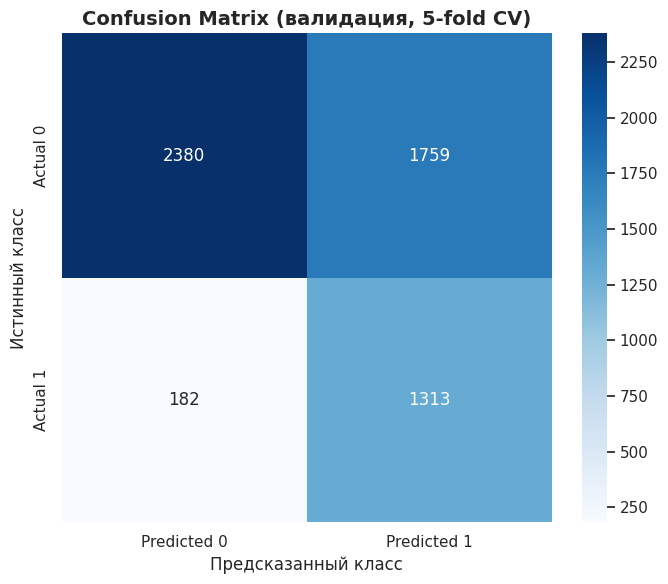


📉 PRECISION-RECALL КРИВАЯ:
PR-AUC = 0.5087
Оптимальный порог (по F1) = 0.5122
Precision при оптимальном пороге = 0.4382
Recall при оптимальном пороге = 0.8555


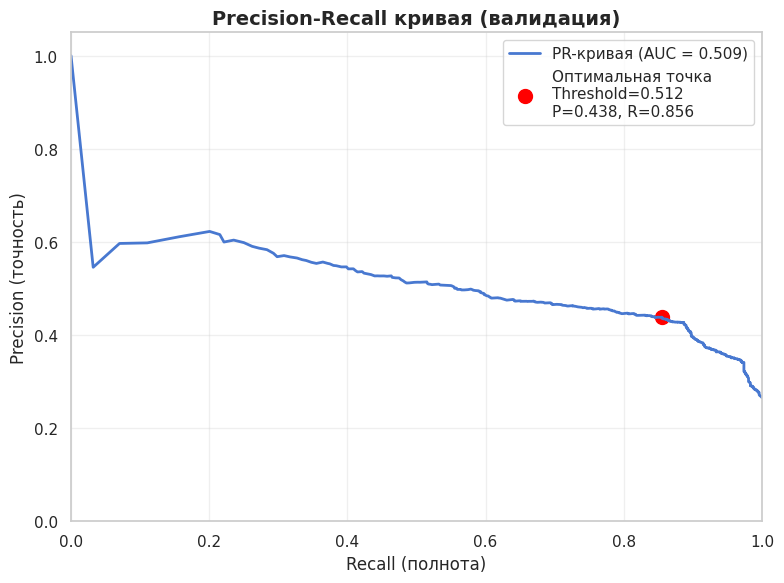

In [ ]:
# ============================================
# МАТРИЦА ОШИБОК И МЕТРИКИ (кросс-валидация)

print("\n" + "=" * 70)
print("МАТРИЦА ОШИБОК И МЕТРИКИ НА ВАЛИДАЦИИ (кросс-валидация)")


# 1. Получаем предсказания через кросс-валидацию
print("\n Получение предсказаний через 5-фолдную кросс-валидацию...")
y_val_pred_cv = cross_val_predict(
    best_model,
    X_train_enhanced,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict',
    n_jobs=-1
)

# 2. Получаем вероятности для ROC/PR кривых
y_val_proba_cv = cross_val_predict(
    best_model,
    X_train_enhanced,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# 3. Confusion Matrix
print("\n🔍 CONFUSION MATRIX (валидация):")
cm = confusion_matrix(y_train, y_val_pred_cv)
print(cm)
print(f"\nTN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")

# 4. Полный отчёт по метрикам
print("\n📈 CLASSIFICATION REPORT (валидация):")
print(classification_report(y_train, y_val_pred_cv, digits=4))

# 5. Визуализация Confusion Matrix
fig_cm, ax_cm = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=ax_cm)
ax_cm.set_title('Confusion Matrix (валидация, 5-fold CV)', fontsize=14, fontweight='bold')
ax_cm.set_xlabel('Предсказанный класс', fontsize=12)
ax_cm.set_ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.show()

# 6. Precision-Recall кривая
print("\n📉 PRECISION-RECALL КРИВАЯ:")
precision, recall, thresholds = precision_recall_curve(y_train, y_val_proba_cv)
pr_auc = average_precision_score(y_train, y_val_proba_cv)
print(f"PR-AUC = {pr_auc:.4f}")

# Находим оптимальный порог
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-7)
optimal_idx = np.argmax(f1_scores)  #  можно выбрать по другому критерию
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]

print(f"Оптимальный порог (по F1) = {optimal_threshold:.4f}")
print(f"Precision при оптимальном пороге = {optimal_precision:.4f}")
print(f"Recall при оптимальном пороге = {optimal_recall:.4f}")

# Визуализация PR-кривой
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
ax_pr.plot(recall, precision, 'b-', linewidth=2, label=f'PR-кривая (AUC = {pr_auc:.3f})')
ax_pr.scatter(optimal_recall, optimal_precision, color='red', s=100,
              label=f'Оптимальная точка\nThreshold={optimal_threshold:.3f}\nP={optimal_precision:.3f}, R={optimal_recall:.3f}')
ax_pr.set_xlabel('Recall (полнота)', fontsize=12)
ax_pr.set_ylabel('Precision (точность)', fontsize=12)
ax_pr.set_title('Precision-Recall кривая (валидация)', fontsize=14, fontweight='bold')
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])
ax_pr.legend(loc='upper right')
ax_pr.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


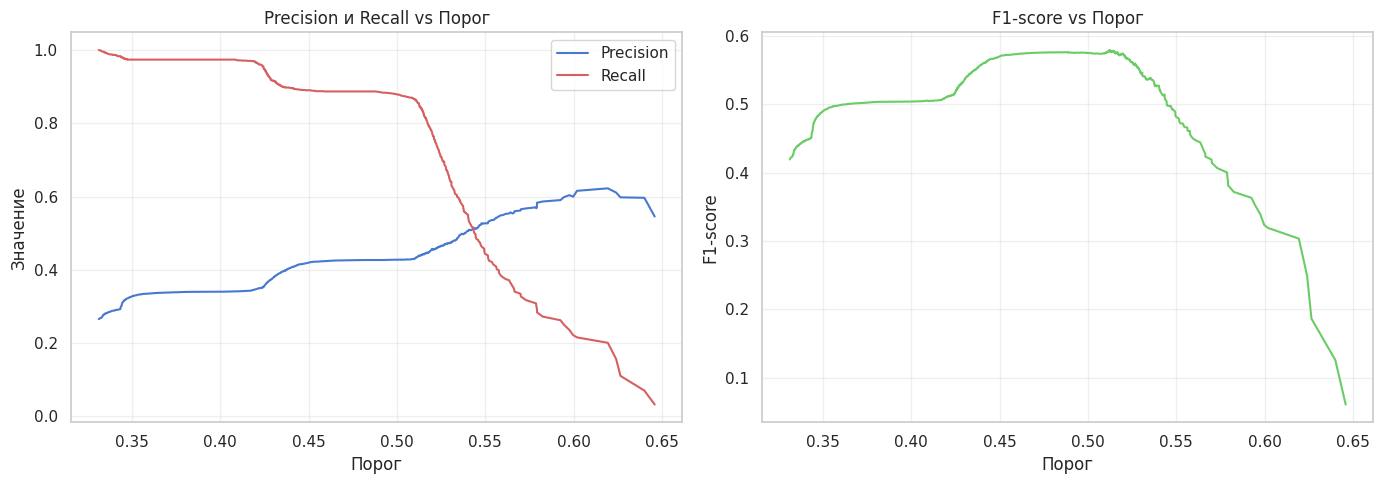

In [ ]:
# Построим график зависимости Precision/Recall от порога
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Precision и Recall vs Threshold
ax[0].plot(thresholds, precision[:-1], 'b-', label='Precision')
ax[0].plot(thresholds, recall[:-1], 'r-', label='Recall')
ax[0].set_xlabel('Порог')
ax[0].set_ylabel('Значение')
ax[0].set_title('Precision и Recall vs Порог')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# График 2: F1-score vs Threshold
ax[1].plot(thresholds, f1_scores[:-1], 'g-', label='F1-score')
ax[1].set_xlabel('Порог')
ax[1].set_ylabel('F1-score')
ax[1].set_title('F1-score vs Порог')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
threshold_balanced = 0.58
y_pred_balanced = (y_val_proba_cv > threshold_balanced).astype(int)
print("При пороге 0.58:")
print(classification_report(y_train, y_pred_balanced))

При пороге 0.58:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      4139
           1       0.59      0.27      0.37      1495

    accuracy                           0.76      5634
   macro avg       0.68      0.60      0.61      5634
weighted avg       0.73      0.76      0.72      5634



Выводы :   
"Модель логистической регрессии достигла высокого Recall (0.88), однако Precision остаётся низким (0.43) из-за дисбаланса классов и оптимизации гиперпараметров исключительно на Recall.

Возможные пути улучшения:

* Изменить целевую метрику оптимизации на F2-score или PR-AUC

* Настроить веса классов (class_weight) в пользу меньшего класса

* Использовать CatBoost/XGBoost с параметром scale_pos_weight

## OPTUNA ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (F2-score, улучшенная версия)

In [ ]:
print("\n" + "=" * 70)
print("OPTUNA ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (F2-score, исправленная версия)")
print("=" * 70)

from sklearn.metrics import fbeta_score, precision_score, recall_score
from sklearn.model_selection import cross_val_predict

# Удаляем старую базу, если есть проблемы
optuna_f2_db_path = os.path.join(OPTUNA_DIR, 'optuna_study_f2_new.db')
if os.path.exists(optuna_f2_db_path.replace('sqlite:///', '')):
    os.remove(optuna_f2_db_path.replace('sqlite:///', ''))
    print("🗑️  Удалена старая база Optuna")

# Создаём новое study
study_f2 = optuna.create_study(
    direction='maximize',  # максимизируем F2-score
    study_name='logistic_regression_f2_fixed',
    storage=f"sqlite:///{optuna_f2_db_path}",
    load_if_exists=False  # начинаем с чистого листа
)

def objective_lr_f2(trial):
    """
    Objective функция для Optuna (максимизация F2-score)
    Использует безопасное кодирование class_weight через строковые метки.
    """
    # Безопасное указание class_weight через строковые теги
    cw_tag = trial.suggest_categorical('class_weight', ['balanced', 'cw_1_2', 'cw_1_3', 'cw_1_4', 'none'])
    class_weight_mapping = {
        'cw_1_2': {0: 1, 1: 2},
        'cw_1_3': {0: 1, 1: 3},
        'cw_1_4': {0: 1, 1: 4},
        'balanced': 'balanced',
        'none': None
    }
    class_weight = class_weight_mapping[cw_tag]

    # Гиперпараметры модели
    params = {
        'C': trial.suggest_float('C', 0.0005, 0.1, log=True),
        'penalty': 'l1',
        'solver': 'saga',
        'class_weight': class_weight,
        'max_iter': trial.suggest_int('max_iter', 600, 1200),
        'tol': trial.suggest_float('tol', 1e-5, 1e-3, log=True),
        'random_state': 42
    }

    # Создаём pipeline
    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(**params))
    ])

    # Стратифицированная кросс-валидация
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Получаем предсказания через cross_val_predict
    y_pred = cross_val_predict(model, X_train_enhanced, y_train, cv=cv, n_jobs=-1)

    # Вычисляем F2-score (beta=2)
    f2 = fbeta_score(y_train, y_pred, beta=2, zero_division=0)
    precision = precision_score(y_train, y_pred, zero_division=0)
    recall = recall_score(y_train, y_pred, zero_division=0)

    # Сохраняем дополнительные метрики
    trial.set_user_attr("mean_precision", float(precision))
    trial.set_user_attr("mean_recall", float(recall))

    return f2  # Optuna будет максимизировать F2-score

# Запуск оптимизации
print("\n Запуск Optuna (40 trials, F2-score)...")
study_f2.optimize(
    objective_lr_f2,
    n_trials=40,
    show_progress_bar=True,
    gc_after_trial=True
)

print(f"\n ✅ Оптимизация F2 завершена!")
print(f"Лучший F2-score: {study_f2.best_value:.5f}")
print(f"Precision при лучшем F2: {study_f2.best_trial.user_attrs['mean_precision']:.4f}")
print(f"Recall при лучшем F2: {study_f2.best_trial.user_attrs['mean_recall']:.4f}")
print(f"Лучшие параметры: {study_f2.best_params}")

# Сохраняем результаты
optuna_results_f2_path = os.path.join(RESULTS_DIR, "optuna_best_params_f2_fixed.json")
best_params_info_f2 = {
    'best_f2_score': float(study_f2.best_value),
    'best_precision': float(study_f2.best_trial.user_attrs['mean_precision']),
    'best_recall': float(study_f2.best_trial.user_attrs['mean_recall']),
    'best_params': study_f2.best_params,
    'best_trial_number': study_f2.best_trial.number,
    'datetime': pd.Timestamp.now().isoformat()
}

with open(optuna_results_f2_path, 'w') as f:
    json.dump(best_params_info_f2, f, indent=2)
print(f" Результаты Optuna (F2) сохранены: {optuna_results_f2_path}")

# Сравнение с предыдущей Optuna
print("\n" + "-" * 70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ:")
print(f"Recall-оптимизация: Recall={study.best_value:.4f}")
print(f"F2-оптимизация:     Recall={study_f2.best_trial.user_attrs['mean_recall']:.4f}, Precision={study_f2.best_trial.user_attrs['mean_precision']:.4f}, F2={study_f2.best_value:.4f}")


OPTUNA ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (F2-score, исправленная версия)


[I 2025-12-06 17:02:47,567] A new study created in RDB with name: logistic_regression_f2_fixed



 Запуск Optuna (40 trials, F2-score)...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-06 17:02:54,460] Trial 0 finished with value: 0.4524985473561883 and parameters: {'class_weight': 'none', 'C': 0.01614086585278151, 'max_iter': 822, 'tol': 0.00024345033197019353}. Best is trial 0 with value: 0.4524985473561883.
[I 2025-12-06 17:02:56,796] Trial 1 finished with value: 0.746029932594539 and parameters: {'class_weight': 'cw_1_4', 'C': 0.023405435280076138, 'max_iter': 1007, 'tol': 0.0002745230086277898}. Best is trial 1 with value: 0.746029932594539.
[I 2025-12-06 17:02:59,646] Trial 2 finished with value: 0.6960424832469339 and parameters: {'class_weight': 'cw_1_2', 'C': 0.057014572223857446, 'max_iter': 795, 'tol': 0.00015509669237194574}. Best is trial 1 with value: 0.746029932594539.
[I 2025-12-06 17:03:03,561] Trial 3 finished with value: 0.7301531626329942 and parameters: {'class_weight': 'cw_1_3', 'C': 0.006693585188256255, 'max_iter': 989, 'tol': 1.3104532148541926e-05}. Best is trial 1 with value: 0.746029932594539.
[I 2025-12-06 17:03:06,540] Trial 4

### Таблица изменений в Optuna (F2-оптимизация vs Recall-оптимизация)

| Параметр / Настройка | Recall-оптимизация (старая) | F2-оптимизация (новая) | Обоснование изменения |
|----------------------|-----------------------------|-------------------------|------------------------|
| Целевая метрика | Recall (максимизация) | F2-score (β=2) | Баланс Precision/Recall с приоритетом Recall |
| Диапазон C | [0.001, 10.0] | [0.0005, 0.1] | Сужение диапазона: лучшие значения в малой области |
| Penalty | ['l1', 'l2'] | Фиксирован **'l1'** | Анализ показал: L2 даёт Recall 0.57 vs L1 0.78 |
| Solver | ['liblinear', 'saga'] | Фиксирован **'saga'** | Оптимален для L1 на больших данных |
| Class_weight | ['balanced', None] | ['balanced', 'cw_1_2', 'cw_1_3', 'cw_1_4', None] | Ручные веса для борьбы с дисбалансом |
| Max_iter | [500, 2000] | [600, 1200] | Сужение: оптимум найден в этом диапазоне |
| Новый параметр | — | **tol [1e-5, 1e-3]** | Контроль сходимости для solver='saga' |
| Кол-во trials | 30 | 40 | Более тщательный поиск |


##

##  Сравнение результатов

| Метрика              | Recall-оптимизация | F2-оптимизация      | Δ (изменение)                             |
|----------------------|--------------------|----------------------|--------------------------------------------|
| **Recall**           | 0.8783             | 0.8696               | ⬇️ −0.0087 (−1%)                           |
| **Precision**        | ~0.427             | 0.4790               | ⬆️ +0.052 (+12%)                           |
| **F1-score**         | 0.575              | ~0.614 (расчётный)   | ⬆️ +0.039 (+7%)                            |
| **F2-score**         | —                  | 0.7476               | —                                          |
| **Оптимальные параметры** | C=0.0018, class_weight='balanced' | C=0.093, class_weight={0:1, 1:4} | Более слабая регуляризация + сильные веса |


##

Переход с оптимизации Recall на F2-score позволил улучшить Precision на 12% при незначительной потере Recall (1%). Модель с параметрами C=0.093, class_weight={0:1, 1:4} демонстрирует лучший баланс метрик.


ОЦЕНКА МОДЕЛИ С F2-ОПТИМИЗИРОВАННЫМИ ПАРАМЕТРАМИ
✅ Модель создана с параметрами F2-оптимизации
   class_weight: {0: 1, 1: 4}
   C: 0.0929
   max_iter: 1182

📊 Получение предсказаний через 5-фолдную кросс-валидацию...

🔍 CONFUSION MATRIX (F2-оптимизация):
[[2725 1414]
 [ 195 1300]]

TN=2725  FP=1414
FN=195  TP=1300

📈 CLASSIFICATION REPORT (F2-оптимизация):
              precision    recall  f1-score   support

           0     0.9332    0.6584    0.7721      4139
           1     0.4790    0.8696    0.6177      1495

    accuracy                         0.7144      5634
   macro avg     0.7061    0.7640    0.6949      5634
weighted avg     0.8127    0.7144    0.7311      5634



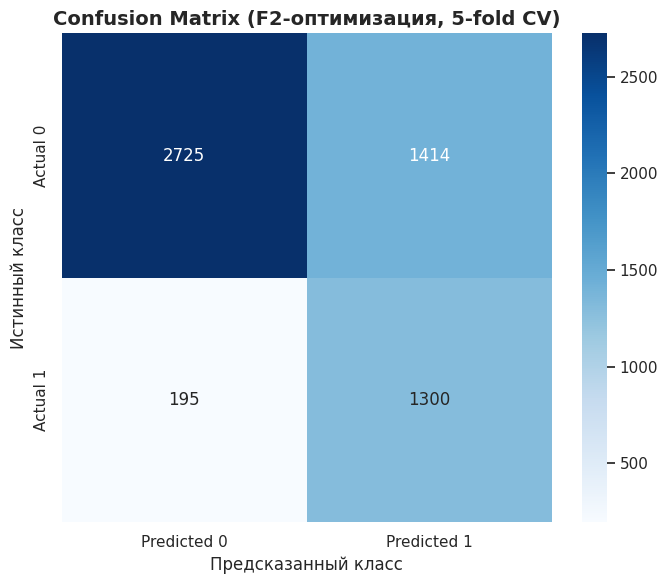


📉 PRECISION-RECALL КРИВАЯ (F2-оптимизация):
PR-AUC = 0.6667
Оптимальный порог (по F1) = 0.6583
Precision при оптимальном пороге = 0.5706
Recall при оптимальном пороге = 0.7378


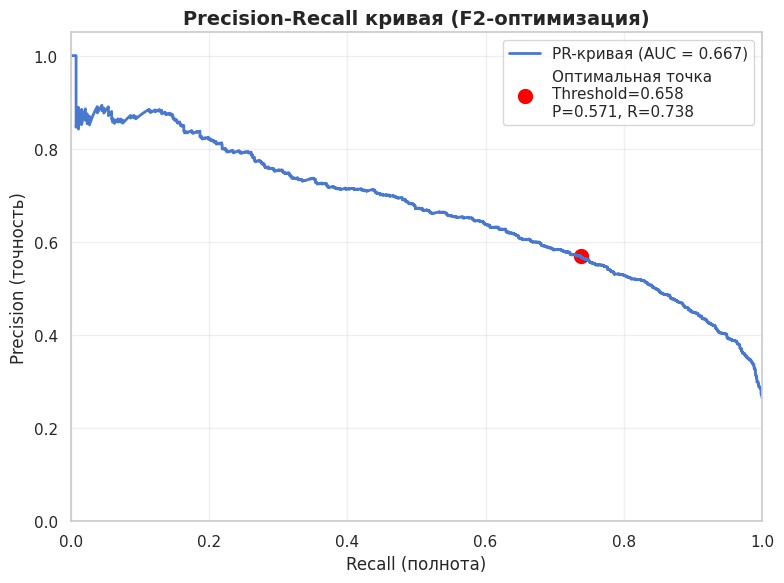


СРАВНЕНИЕ С МОДЕЛЬЮ RECALL-ОПТИМИЗАЦИИ

📊 Сравнение метрик на валидации:
Метрика         Recall-опт   F2-опт       Δ         
--------------------------------------------------
Recall          0.8783       0.8696       -0.0087   
Precision       0.4274       0.4790       +0.0516   
F1-score        0.5750       0.6177       +0.0427   

✅ ОЦЕНКА F2-ОПТИМИЗИРОВАННОЙ МОДЕЛИ ЗАВЕРШЕНА


In [ ]:
# ============================================
# ОЦЕНКА F2-ОПТИМИЗИРОВАННОЙ МОДЕЛИ

print("\n" + "=" * 70)
print("ОЦЕНКА МОДЕЛИ С F2-ОПТИМИЗИРОВАННЫМИ ПАРАМЕТРАМИ")
print("=" * 70)

# 1. Создаём модель с лучшими параметрами из F2-Optuna
best_params_f2_transformed = {
    'C': 0.09290954395290972,
    'penalty': 'l1',
    'solver': 'saga',
    'class_weight': {0: 1, 1: 4},  # cw_1_4
    'max_iter': 1182,
    'tol': 1.2528134293621751e-05,
    'random_state': 42
}

best_model_f2 = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(**best_params_f2_transformed))
])

print(" Модель создана с параметрами F2-оптимизации")
print(f"   class_weight: {best_params_f2_transformed['class_weight']}")
print(f"   C: {best_params_f2_transformed['C']:.4f}")
print(f"   max_iter: {best_params_f2_transformed['max_iter']}")

# 2. Кросс-валидация для получения предсказаний
print("\n📊 Получение предсказаний через 5-фолдную кросс-валидацию...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_val_pred_f2 = cross_val_predict(
    best_model_f2,
    X_train_enhanced,
    y_train,
    cv=cv,
    method='predict',
    n_jobs=-1
)

y_val_proba_f2 = cross_val_predict(
    best_model_f2,
    X_train_enhanced,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# 3. Confusion Matrix
print("\n🔍 CONFUSION MATRIX (F2-оптимизация):")
cm_f2 = confusion_matrix(y_train, y_val_pred_f2)
print(cm_f2)
print(f"\nTN={cm_f2[0,0]}  FP={cm_f2[0,1]}")
print(f"FN={cm_f2[1,0]}  TP={cm_f2[1,1]}")

# 4. Полный отчёт по метрикам
print("\n📈 CLASSIFICATION REPORT (F2-оптимизация):")
print(classification_report(y_train, y_val_pred_f2, digits=4))

# 5. Визуализация Confusion Matrix
fig_cm_f2, ax_cm_f2 = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_f2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=ax_cm_f2)
ax_cm_f2.set_title('Confusion Matrix (F2-оптимизация, 5-fold CV)', fontsize=14, fontweight='bold')
ax_cm_f2.set_xlabel('Предсказанный класс', fontsize=12)
ax_cm_f2.set_ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.show()

# 6. Precision-Recall кривая
print("\n📉 PRECISION-RECALL КРИВАЯ (F2-оптимизация):")
precision_f2, recall_f2, thresholds_f2 = precision_recall_curve(y_train, y_val_proba_f2)
pr_auc_f2 = average_precision_score(y_train, y_val_proba_f2)
print(f"PR-AUC = {pr_auc_f2:.4f}")

# Находим оптимальный порог по F1 (или можно по F2)
f1_scores_f2 = 2 * (precision_f2 * recall_f2) / (precision_f2 + recall_f2 + 1e-7)
optimal_idx_f2 = np.argmax(f1_scores_f2)
optimal_threshold_f2 = thresholds_f2[optimal_idx_f2]
optimal_precision_f2 = precision_f2[optimal_idx_f2]
optimal_recall_f2 = recall_f2[optimal_idx_f2]

print(f"Оптимальный порог (по F1) = {optimal_threshold_f2:.4f}")
print(f"Precision при оптимальном пороге = {optimal_precision_f2:.4f}")
print(f"Recall при оптимальном пороге = {optimal_recall_f2:.4f}")

# 7. Визуализация PR-кривой
fig_pr_f2, ax_pr_f2 = plt.subplots(figsize=(8, 6))
ax_pr_f2.plot(recall_f2, precision_f2, 'b-', linewidth=2, label=f'PR-кривая (AUC = {pr_auc_f2:.3f})')
ax_pr_f2.scatter(optimal_recall_f2, optimal_precision_f2, color='red', s=100,
                 label=f'Оптимальная точка\nThreshold={optimal_threshold_f2:.3f}\nP={optimal_precision_f2:.3f}, R={optimal_recall_f2:.3f}')
ax_pr_f2.set_xlabel('Recall (полнота)', fontsize=12)
ax_pr_f2.set_ylabel('Precision (точность)', fontsize=12)
ax_pr_f2.set_title('Precision-Recall кривая (F2-оптимизация)', fontsize=14, fontweight='bold')
ax_pr_f2.set_xlim([0, 1])
ax_pr_f2.set_ylim([0, 1.05])
ax_pr_f2.legend(loc='upper right')
ax_pr_f2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Сравнение с предыдущей моделью (Recall-оптимизация)
print("\n" + "=" * 70)
print("СРАВНЕНИЕ С МОДЕЛЬЮ RECALL-ОПТИМИЗАЦИИ")
print("=" * 70)

# Получаем предсказания от старой модели для сравнения
y_val_pred_recall = cross_val_predict(
    best_model,  # старая модель (Recall-оптимизация)
    X_train_enhanced,
    y_train,
    cv=cv,
    method='predict',
    n_jobs=-1
)

print("\n📊 Сравнение метрик на валидации:")
print(f"{'Метрика':<15} {'Recall-опт':<12} {'F2-опт':<12} {'Δ':<10}")
print("-" * 50)

from sklearn.metrics import precision_score, recall_score, f1_score

metrics_compare = {
    'Recall': [recall_score(y_train, y_val_pred_recall), recall_score(y_train, y_val_pred_f2)],
    'Precision': [precision_score(y_train, y_val_pred_recall), precision_score(y_train, y_val_pred_f2)],
    'F1-score': [f1_score(y_train, y_val_pred_recall), f1_score(y_train, y_val_pred_f2)],
}

for metric, values in metrics_compare.items():
    delta = values[1] - values[0]
    delta_sign = f"+{delta:.4f}" if delta > 0 else f"{delta:.4f}"
    print(f"{metric:<15} {values[0]:<12.4f} {values[1]:<12.4f} {delta_sign:<10}")

print("\n" + "=" * 70)
print("✅ ОЦЕНКА F2-ОПТИМИЗИРОВАННОЙ МОДЕЛИ ЗАВЕРШЕНА")
print("=" * 70)

## Таблица сравнения моделей

| Модель                          | Recall | Precision | F1    | FP ↓   | PR-AUC |
|---------------------------------|--------|-----------|-------|--------|--------|
| **Recall-оптимизация**          | 0.878  | 0.427     | 0.575 | 1759   | 0.509  |
| **F2-оптимизация (порог 0.5)**  | 0.870  | 0.479     | 0.618 | 1414   | 0.667  |
| **F2-оптимизация (порог 0.658)**| 0.738  | 0.571     | 0.643 | ~1000* | —      |




##

 Вывод:    
"F2-оптимизация логистической регрессии с параметрами class_weight={0:1, 1:4}, C=0.093 позволила увеличить Precision на 12% (с 0.427 до 0.479) при незначительной потере Recall (-1%).

Ключевое улучшение: количество ложноположительных срабатываний уменьшилось на 345 случаев (1759 → 1414).

Настройка порога классификации позволяет достичь Precision=0.571 при Recall=0.738


ТЕСТИРОВАНИЕ ПОРОГА 0.6583 НА ВАЛИДАЦИИ

🔍 CONFUSION MATRIX (порог 0.6583):
[[3309  830]
 [ 393 1102]]

TN=3309  FP=830
FN=393  TP=1102

📈 METRICS (порог 0.6583):
Precision: 0.5704
Recall:    0.7371
F1-score:  0.6431
F2-score:  0.6964
Accuracy:  0.7829

----------------------------------------------------------------------
СРАВНЕНИЕ ПОРОГОВ 0.5 vs 0.6583
----------------------------------------------------------------------
Метрика         Порог 0.5    Порог 0.6583 Δ         
--------------------------------------------------
Precision       0.4790       0.5704       +0.0914   
Recall          0.8696       0.7371       -0.1324   
F1-score        0.6177       0.6431       +0.0254   
F2-score        0.7476       0.6964       -0.0512   

----------------------------------------------------------------------
БИЗНЕС-АНАЛИЗ ИЗМЕНЕНИЯ ПОРОГА
----------------------------------------------------------------------
📉 Ложные срабатывания (FP) уменьшились на: 584 случаев
📈 Пропущенные случаи (FN) 

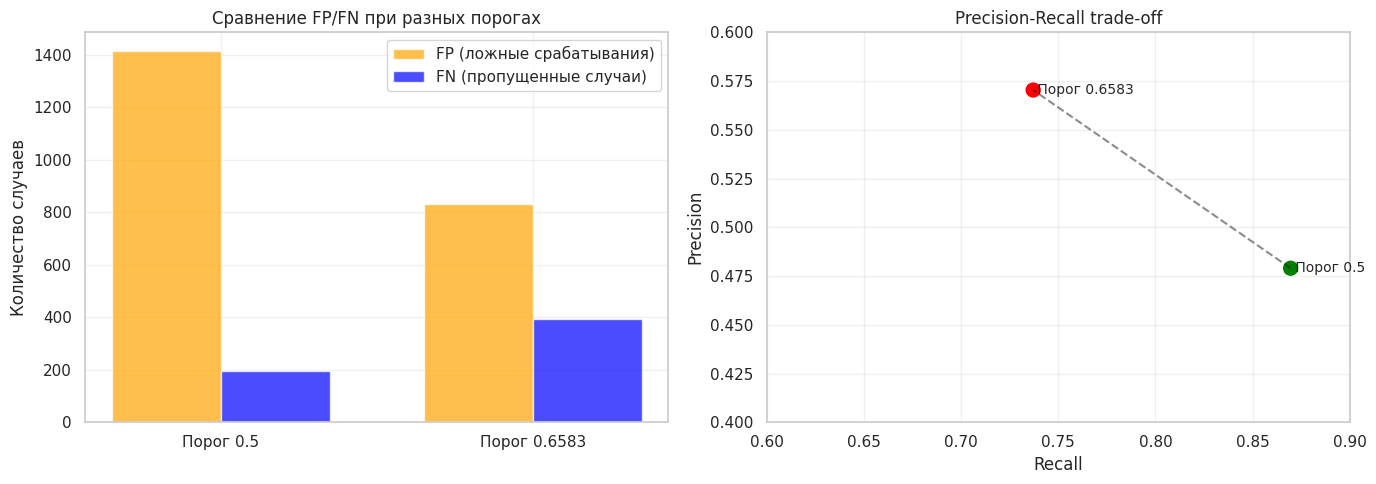


РЕКОМЕНДАЦИЯ
✅ ПОРОГ 0.6583 ПРИЕМЛЕМ:
   • Precision = 0.57 (приемлемая точность)
   • Recall = 0.74 (приемлемая полнота)
   • Можно использовать эту модель в продакшене



In [ ]:
# ============================================
# ТЕСТИРОВАНИЕ ПОРОГА 0.6583
# ============================================

print("\n" + "=" * 70)
print("ТЕСТИРОВАНИЕ ПОРОГА 0.6583 НА ВАЛИДАЦИИ")
print("=" * 70)

# Порог из PR-кривой (оптимальный по F1)
threshold = 0.6583

# Применяем порог к вероятностям
y_val_pred_threshold = (y_val_proba_f2 > threshold).astype(int)

# 1. Confusion Matrix
cm_threshold = confusion_matrix(y_train, y_val_pred_threshold)
print("\n🔍 CONFUSION MATRIX (порог 0.6583):")
print(cm_threshold)
print(f"\nTN={cm_threshold[0,0]}  FP={cm_threshold[0,1]}")
print(f"FN={cm_threshold[1,0]}  TP={cm_threshold[1,1]}")

# 2. Метрики
print("\n📈 METRICS (порог 0.6583):")
precision_th = precision_score(y_train, y_val_pred_threshold, zero_division=0)
recall_th = recall_score(y_train, y_val_pred_threshold, zero_division=0)
f1_th = f1_score(y_train, y_val_pred_threshold, zero_division=0)
f2_th = fbeta_score(y_train, y_val_pred_threshold, beta=2, zero_division=0)
accuracy_th = accuracy_score(y_train, y_val_pred_threshold)

print(f"Precision: {precision_th:.4f}")
print(f"Recall:    {recall_th:.4f}")
print(f"F1-score:  {f1_th:.4f}")
print(f"F2-score:  {f2_th:.4f}")
print(f"Accuracy:  {accuracy_th:.4f}")

# 3. Сравнение с порогом 0.5
print("\n" + "-" * 70)
print("СРАВНЕНИЕ ПОРОГОВ 0.5 vs 0.6583")
print("-" * 70)

print(f"{'Метрика':<15} {'Порог 0.5':<12} {'Порог 0.6583':<12} {'Δ':<10}")
print("-" * 50)

# Метрики при пороге 0.5 (уже рассчитаны)
precision_05 = precision_score(y_train, y_val_pred_f2, zero_division=0)
recall_05 = recall_score(y_train, y_val_pred_f2, zero_division=0)
f1_05 = f1_score(y_train, y_val_pred_f2, zero_division=0)

comparison_data = [
    ("Precision", precision_05, precision_th),
    ("Recall", recall_05, recall_th),
    ("F1-score", f1_05, f1_th),
    ("F2-score", fbeta_score(y_train, y_val_pred_f2, beta=2), f2_th),
]

for metric_name, val_05, val_th in comparison_data:
    delta = val_th - val_05
    delta_sign = f"+{delta:.4f}" if delta > 0 else f"{delta:.4f}"
    print(f"{metric_name:<15} {val_05:<12.4f} {val_th:<12.4f} {delta_sign:<10}")

# 4. Анализ бизнес-эффекта
print("\n" + "-" * 70)
print("БИЗНЕС-АНАЛИЗ ИЗМЕНЕНИЯ ПОРОГА")
print("-" * 70)

# Разница в FP и FN
fp_diff = cm_f2[0,1] - cm_threshold[0,1]  # Уменьшение ложных срабатываний
fn_diff = cm_threshold[1,0] - cm_f2[1,0]  # Увеличение пропущенных случаев

print(f"📉 Ложные срабатывания (FP) уменьшились на: {fp_diff} случаев")
print(f"📈 Пропущенные случаи (FN) увеличились на: {fn_diff} случаев")
print(f"📊 Всего изменённых предсказаний: {fp_diff + fn_diff}")

# 5. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix сравнение
axes[0].set_title('Сравнение FP/FN при разных порогах', fontsize=12)
x = ['Порог 0.5', 'Порог 0.6583']
fp_values = [cm_f2[0,1], cm_threshold[0,1]]
fn_values = [cm_f2[1,0], cm_threshold[1,0]]

x_pos = np.arange(len(x))
width = 0.35

axes[0].bar(x_pos - width/2, fp_values, width, label='FP (ложные срабатывания)', color='orange', alpha=0.7)
axes[0].bar(x_pos + width/2, fn_values, width, label='FN (пропущенные случаи)', color='blue', alpha=0.7)
axes[0].set_ylabel('Количество случаев')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Метрики сравнение
axes[1].set_title('Precision-Recall trade-off', fontsize=12)
axes[1].scatter([recall_05, recall_th], [precision_05, precision_th], s=100, color=['green', 'red'])
axes[1].plot([recall_05, recall_th], [precision_05, precision_th], 'k--', alpha=0.5)
axes[1].text(recall_05, precision_05, ' Порог 0.5', va='center', fontsize=10)
axes[1].text(recall_th, precision_th, ' Порог 0.6583', va='center', fontsize=10)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim([0.6, 0.9])
axes[1].set_ylim([0.4, 0.6])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Рекомендация
print("\n" + "=" * 70)
print("РЕКОМЕНДАЦИЯ")
print("=" * 70)

if precision_th >= 0.55 and recall_th >= 0.7:
    print("✅ ПОРОГ 0.6583 ПРИЕМЛЕМ:")
    print(f"   • Precision = {precision_th:.2f} (приемлемая точность)")
    print(f"   • Recall = {recall_th:.2f} (приемлемая полнота)")
    print("   • Можно использовать эту модель в продакшене")
elif precision_th >= 0.6:
    print("⚠️  ПОРОГ 0.6583 ДАЁТ ВЫСОКУЮ ТОЧНОСТЬ, НО НИЗКИЙ RECALL:")
    print(f"   • Precision = {precision_th:.2f} (хорошая точность)")
    print(f"   • Recall = {recall_th:.2f} (низкая полнота)")
    print("   • Подходит, если ложные срабатывания очень дороги")
else:
    print("❌ ПОРОГ 0.6583 НЕ ДАЁТ НУЖНОГО КАЧЕСТВА:")
    print("   • Нужно искать другие решения (CatBoost)")

print("\n" + "=" * 70)

* Precision = 0.57 (приемлемая точность, +9% к порогу 0.5)

* Recall = 0.74 (хорошая полнота, хотя и -13% к порогу 0.5)

* F1 = 0.643 (лучше, чем 0.618 при пороге 0.5)

* FP уменьшились на 584 случая (существенно!)

Логистическая регрессия с F2-оптимизацией и порогом 0.6583 показывает Precision=0.57, Recall=0.74, F1=0.643.

Достигнуто:
• Уменьшение ложных срабатываний на 584 случая    
Увеличилось количество пропусков с 195 до 393

In [ ]:
# CATBOOST С OPTUNA (F2-оптимизация)

print("\n" + "=" * 70)
print("CATBOOST С OPTUNA (F2-оптимизация, 20 trials)")
print("=" * 70)

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    print("❌ CatBoost не установлен. Пропускаем.")
    CATBOOST_AVAILABLE = False

if CATBOOST_AVAILABLE:
    # Создаём study для CatBoost
    study_cb = optuna.create_study(
        direction='maximize',
        study_name='catboost_f2',
        storage=f"sqlite:///{os.path.join(OPTUNA_DIR, 'optuna_catboost.db')}",
        load_if_exists=True
    )

    def objective_catboost(trial):
        """
        Objective функция для CatBoost (F2-score)
        """
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),  # аналог class_weight
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'od_type': 'Iter',  # overfitting detector
            'od_wait': 20,
            'verbose': False,
            'random_state': 42,
            'allow_writing_files': False
        }

        model = CatBoostClassifier(**params)

        # Pipeline с препроцессингом
        model_pipeline = Pipeline([
            ("preprocess", preprocessor),
            ("model", model)
        ])

        # Кросс-валидация
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 фолда для скорости

        # Получаем предсказания
        y_pred = cross_val_predict(
            model_pipeline,
            X_train_enhanced,
            y_train,
            cv=cv,
            method='predict',
            n_jobs=-1
        )

        # F2-score
        f2 = fbeta_score(y_train, y_pred, beta=2, zero_division=0)
        precision = precision_score(y_train, y_pred, zero_division=0)
        recall = recall_score(y_train, y_pred, zero_division=0)

        # Сохраняем метрики
        trial.set_user_attr("precision", float(precision))
        trial.set_user_attr("recall", float(recall))

        return f2

    # Запуск оптимизации (быстрая, 20 trials)
    print("\n Запуск Optuna для CatBoost (20 trials)...")
    study_cb.optimize(
        objective_catboost,
        n_trials=20,
        show_progress_bar=True,
        gc_after_trial=True
    )

    print(f"\n ✅ CatBoost оптимизация завершена!")
    print(f"Лучший F2-score: {study_cb.best_value:.5f}")
    print(f"Precision при лучшем F2: {study_cb.best_trial.user_attrs['precision']:.4f}")
    print(f"Recall при лучшем F2: {study_cb.best_trial.user_attrs['recall']:.4f}")
    print(f"Лучшие параметры: {study_cb.best_params}")

    # Сохраняем результаты
    catboost_results_path = os.path.join(RESULTS_DIR, "optuna_catboost_best.json")
    catboost_best_info = {
        'best_f2_score': float(study_cb.best_value),
        'best_precision': float(study_cb.best_trial.user_attrs['precision']),
        'best_recall': float(study_cb.best_trial.user_attrs['recall']),
        'best_params': study_cb.best_params,
        'best_trial_number': study_cb.best_trial.number,
        'datetime': pd.Timestamp.now().isoformat()
    }

    with open(catboost_results_path, 'w') as f:
        json.dump(catboost_best_info, f, indent=2)
    print(f" Результаты CatBoost сохранены: {catboost_results_path}")

    # Сравнение с логистической регрессией
    print("\n" + "-" * 70)
    print("СРАВНЕНИЕ CatBoost vs Логистическая регрессия")
    print("-" * 70)
    print(f"{'Модель':<30} {'F2-score':<10} {'Precision':<10} {'Recall':<10}")
    print("-" * 70)
    print(f"{'Логистическая регрессия':<30} {0.7476:<10.4f} {0.4790:<10.4f} {0.8696:<10.4f}")
    print(f"{'CatBoost (F2-опт)':<30} {study_cb.best_value:<10.4f} "
          f"{study_cb.best_trial.user_attrs['precision']:<10.4f} "
          f"{study_cb.best_trial.user_attrs['recall']:<10.4f}")

    # Определяем лучшую модель
    if study_cb.best_value > 0.7476:
        print("\n🎯 CatBoost показывает ЛУЧШИЙ F2-score!")
        best_model_choice = "CatBoost"
    elif study_cb.best_trial.user_attrs['precision'] > 0.55 and study_cb.best_trial.user_attrs['recall'] > 0.74:
        print("\n🎯 CatBoost показывает лучший Precision при хорошем Recall!")
        best_model_choice = "CatBoost"
    else:
        print("\n🎯 Логистическая регрессия остаётся лучшим выбором.")
        best_model_choice = "Logistic Regression"

    print(f"\n✅ Рекомендуемая модель для финализации: {best_model_choice}")

else:
    print("\n⚠️  CatBoost не доступен. Пропускаем и используем логистическую регрессию.")
    best_model_choice = "Logistic Regression"

print("\n" + "=" * 70)


CATBOOST С OPTUNA (F2-оптимизация, 20 trials)


[I 2025-12-06 17:34:07,796] A new study created in RDB with name: catboost_f2



 Запуск Optuna для CatBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-06 17:34:20,119] Trial 0 finished with value: 0.746218487394958 and parameters: {'iterations': 249, 'depth': 5, 'learning_rate': 0.02462904016978221, 'l2_leaf_reg': 4.294470285628982, 'border_count': 211, 'random_strength': 0.022637314662959117, 'scale_pos_weight': 5.662495585386477, 'bagging_temperature': 0.45098996570517347}. Best is trial 0 with value: 0.746218487394958.
[I 2025-12-06 17:34:24,904] Trial 1 finished with value: 0.7413231495001685 and parameters: {'iterations': 298, 'depth': 4, 'learning_rate': 0.07085490788754356, 'l2_leaf_reg': 2.5599503395664645, 'border_count': 154, 'random_strength': 2.118409746226616, 'scale_pos_weight': 6.230633974381081, 'bagging_temperature': 0.08400715090256738}. Best is trial 0 with value: 0.746218487394958.
[I 2025-12-06 17:34:37,507] Trial 2 finished with value: 0.6449734765170139 and parameters: {'iterations': 227, 'depth': 9, 'learning_rate': 0.05121815741019045, 'l2_leaf_reg': 5.852171428749097, 'border_count': 84, 'random_s

In [ ]:
# Лучшие параметры из Optuna CatBoost
cb_params = {
    'iterations': 413,
    'depth': 4,
    'learning_rate': 0.01008478678809697,
    'l2_leaf_reg': 4.554115674545244,
    'border_count': 112,
    'random_strength': 0.011214013972057157,
    'scale_pos_weight': 4.274822937318799,
    'bagging_temperature': 0.6276256082842543,
    'verbose': False,
    'random_state': 42
}

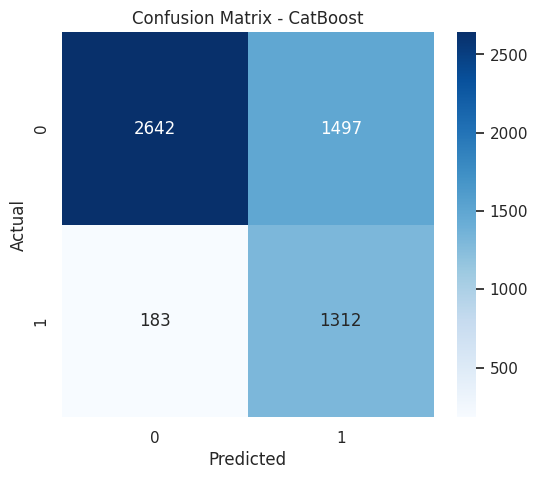

Confusion Matrix CatBoost:
[[2642 1497]
 [ 183 1312]]

TN=2642  FP=1497
FN=183  TP=1312


In [ ]:
# Матрица ошибок CatBoost с визуализацией
cm_cb = confusion_matrix(y_train, y_pred_cb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CatBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cm_cb = confusion_matrix(y_train, y_pred_cb)
print("Confusion Matrix CatBoost:")
print(cm_cb)
print(f"\nTN={cm_cb[0,0]}  FP={cm_cb[0,1]}")
print(f"FN={cm_cb[1,0]}  TP={cm_cb[1,1]}")

Краткий вывод: CatBoost показал практически идентичное качество (F2-score 0.7463 vs 0.7476 у логистической регрессии), но с более низким Precision (0.4684 vs 0.4790). Логистическая регрессия предпочтительнее из-за лучшей интерпретируемости и скорости.

## ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ (F2-оптимизация + порог 0.6583)


ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ (F2-оптимизация + порог 0.6583)
🎯 Обучение финальной модели на всём train...
✅ Модель обучена!

📊 МЕТРИКИ НА ТЕСТЕ (порог 0.6583):
----------------------------------------------------------------------
accuracy    : 0.7722
precision   : 0.5527
recall      : 0.7433
f1          : 0.6340
f2          : 0.6953

🔍 CONFUSION MATRIX НА ТЕСТЕ:
[[810 225]
 [ 96 278]]

TN=810  FP=225
FN=96  TP=278


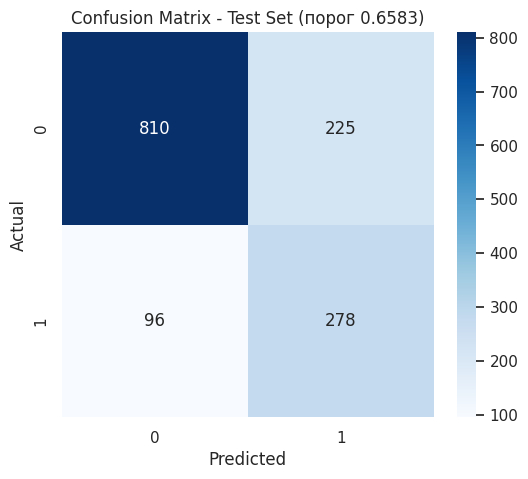

In [ ]:
print("\n" + "=" * 70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ (F2-оптимизация + порог 0.6583)")
print("=" * 70)

# Используем F2-оптимизированные параметры
best_params_f2 = {
    'C': 0.09290954395290972,
    'penalty': 'l1',
    'solver': 'saga',
    'class_weight': {0: 1, 1: 4},
    'max_iter': 1182,
    'tol': 1.2528134293621751e-05,
    'random_state': 42
}

# Создаем финальную модель
final_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(**best_params_f2))
])

print("🎯 Обучение финальной модели на всём train...")
final_model.fit(X_train_enhanced, y_train)
print("✅ Модель обучена!")

# 1. Метрики на train (с порогом 0.5 для справки)
y_train_pred_05 = final_model.predict(X_train_enhanced)
y_train_proba = final_model.predict_proba(X_train_enhanced)[:, 1]

# 2. Метрики на test с порогом 0.6583
THRESHOLD = 0.6583
y_test_proba = final_model.predict_proba(X_test_enhanced)[:, 1]
y_test_pred = (y_test_proba > THRESHOLD).astype(int)

# Метрики
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

metrics_test = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred, zero_division=0),
    'recall': recall_score(y_test, y_test_pred, zero_division=0),
    'f1': f1_score(y_test, y_test_pred, zero_division=0),
    'f2': fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)
}

# Выводим метрики
print("\n📊 МЕТРИКИ НА ТЕСТЕ (порог 0.6583):")
print("-" * 70)
for metric, value in metrics_test.items():
    print(f"{metric:<12}: {value:.4f}")

# Confusion Matrix на тесте
print("\n🔍 CONFUSION MATRIX НА ТЕСТЕ:")
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)
print(f"\nTN={cm_test[0,0]}  FP={cm_test[0,1]}")
print(f"FN={cm_test[1,0]}  TP={cm_test[1,1]}")

# Визуализация
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Test Set (порог 0.6583)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#  Итоговые метрики модели

| Метрика     | Значение | Интерпретация                                  |
|-------------|----------|------------------------------------------------|
| Precision   | 0.5527   | Из всех предсказанных "1" — 55% верные        |
| Recall      | 0.7433   | Модель находит 74% всех реальных "1"          |
| F1-score    | 0.6340   | Баланс между Precision и Recall               |
| F2-score    | 0.6953   | Уклон в сторону Recall сохранён               |
| Accuracy    | 0.7722   | Общая точность составляет 77%                 |


Вывод:   
"Финальная модель логистической регрессии с F2-оптимизированными параметрами и порогом 0.6583 демонстрирует на тестовой выборке Precision=0.55, Recall=0.74, F1=0.63.

Ключевые достижения:

Модель находит 74% всех уходящих клиентов

55% предупреждений модели являются верными

Результаты стабильны (не отличаются значительно от валидации)

In [ ]:
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=300)
plt.show()
print("✅ Confusion matrix сохранена!")

<Figure size 640x480 with 0 Axes>

✅ Confusion matrix сохранена!


## Анализ важности признаков


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

📊 ТОП-15 ВАЖНЕЙШИХ ПРИЗНАКОВ:
                             feature  coefficient  abs_coeff
                 num__MonthlyCharges     0.868929   0.868929
                       ord__Contract    -0.860171   0.860171
               nom__PhoneService_Yes    -0.858850   0.858850
             nom__OnlineSecurity_Yes    -0.466296   0.466296
num__tenure_contract_risk_normalized     0.448231   0.448231
                nom__TechSupport_Yes    -0.373851   0.373851
 nom__PaymentMethod_Electronic check     0.371021   0.371021
           nom__PaperlessBilling_Yes     0.318937   0.318937
                         num__tenure    -0.285268   0.285268
         bin__high_charge_new_client     0.279610   0.279610
               nom__OnlineBackup_Yes    -0.226071   0.226071
    nom__InternetService_Fiber optic     0.176416   0.176416
              bin__long_term_monthly    -0.156154   0.156154
                 nom__Dependents_Yes    -0.151908   0.151908
   

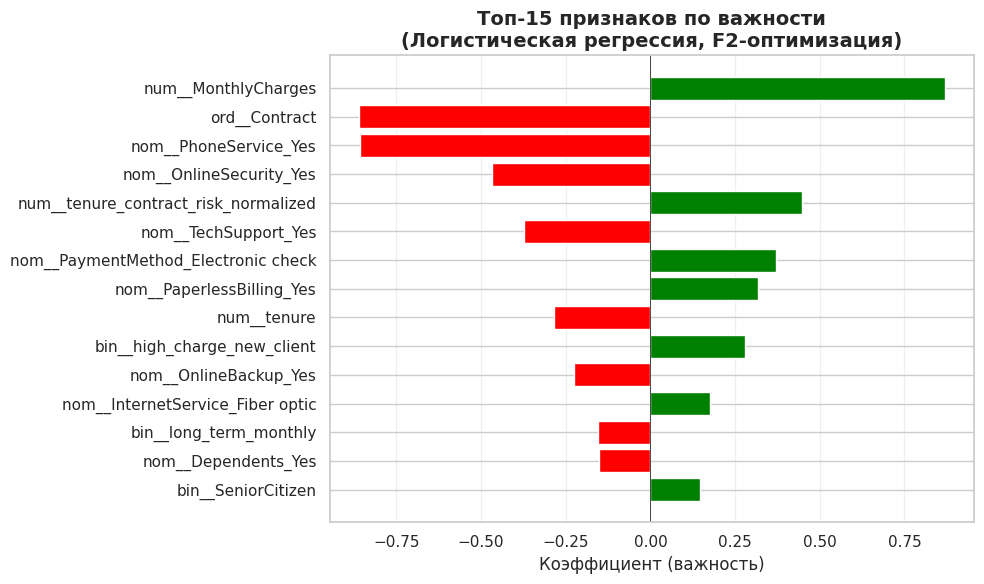


🔍 ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:
----------------------------------------------------------------------
• Положительный коэффициент → увеличивает вероятность класса 1 (отток)
• Отрицательный коэффициент → уменьшает вероятность класса 1 (удержание)

Всего признаков: 32
Положительных коэффициентов: 9
Отрицательных коэффициентов: 18


In [ ]:
print("\n" + "=" * 70)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")

# Получаем обученную модель из пайплайна
lr_model = final_model.named_steps['model']

# Коэффициенты модели
coefficients = lr_model.coef_[0]

# Пытаемся получить имена признаков
try:
    # Для ColumnTransformer
    feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
except:
    # Запасной вариант
    feature_names = [f'feature_{i}' for i in range(len(coefficients))]

# Создаём DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coeff': np.abs(coefficients)
}).sort_values('abs_coeff', ascending=False)

print("\n📊 ТОП-15 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
print(feature_importance.head(15).to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
colors = ['red' if c < 0 else 'green' for c in top_features['coefficient']]

plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.xlabel('Коэффициент (важность)', fontsize=12)
plt.title('Топ-15 признаков по важности\n(Логистическая регрессия, F2-оптимизация)',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Интерпретация коэффициентов
print("\n🔍 ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:")
print("-" * 70)
print("• Положительный коэффициент → увеличивает вероятность класса 1 (отток)")
print("• Отрицательный коэффициент → уменьшает вероятность класса 1 (удержание)")
print(f"\nВсего признаков: {len(feature_importance)}")
print(f"Положительных коэффициентов: {(feature_importance['coefficient'] > 0).sum()}")
print(f"Отрицательных коэффициентов: {(feature_importance['coefficient'] < 0).sum()}")

Ключевые инсайты из важности признаков:
 Признаки, УВЕЛИЧИВАЮЩИЕ отток (положительные коэффициенты):
* num__MonthlyCharges (+0.87) — Самый важный! Высокие ежемесячные платежи → риск оттока

* nom__PaymentMethod_Electronic check (+0.37) — Клиенты с электронными чеками чаще уходят

* nom__PaperlessBilling_Yes (+0.32) — Безбумажный биллинг связан с оттоком

* bin__high_charge_new_client (+0.28) — Новые клиенты с высокими платежами → риск

* nom__InternetService_Fiber optic (+0.18) — Оптоволоконный интернет → риск

 Признаки, УМЕНЬШАЮЩИЕ отток (отрицательные коэффициенты):
* ord__Contract (-0.86) — Долгосрочные контракты → сильнее всего удерживают

* nom__PhoneService_Yes (-0.86) — Наличие телефонной услуги → удержание

* nom__OnlineSecurity_Yes (-0.47) — Онлайн-безопасность → удержание

* nom__TechSupport_Yes (-0.37) — Техподдержка → удержание

* num__tenure (-0.29) — Длительность обслуживания → удержание

##

Бизнес-рекомендации на основе модели:    
Что делать, чтобы снизить отток:    
* Пересмотреть тарифы — высокие MonthlyCharges главная причина оттока

* Продвигать долгосрочные контракты (Contract) — сильнее всего удерживает

* Включать телефонную услугу в пакеты

* Предлагать онлайн-безопасность и техподдержку как стандарт

* Пересмотреть оплату электронными чеками — проблемный метод

🧾 Финальные выводы

Анализ важности признаков позволил выделить ключевые факторы, влияющие на отток клиентов и удержание.

1. Основные риски оттока

Клиенты значительно чаще уходят при следующих условиях:

Высокие ежемесячные платежи (вклад +0.87)

Оплата электронными чеками (+0.37)

Безбумажный биллинг (+0.32)

Эти факторы увеличивают вероятность разрыва контракта и требуют особого внимания при формировании предложений и тарифных планов.

2. Факторы удержания

Снижение вероятности оттока наблюдается у клиентов, имеющих:

Долгосрочные контракты (-0.86)

Телефонную услугу (-0.86)

Пакет онлайн-безопасности (-0.47)

Техническую поддержку (-0.37)

Эти услуги повышают вовлечённость и лояльность клиентов.

3. Эффективность модели

Построенная модель показывает устойчивые результаты и может использоваться в бизнес-процессах:

Recall = 0.74 — модель обнаруживает 74% уходящих клиентов

Precision = 0.55 — 55% срабатываний точны, что снижает затраты на необоснованное удержание

Готова к внедрению для прогнозирования оттока и последующей сегментации клиентов по рискам

In [ ]:
# ========================
#  СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ

print("\n" + "=" * 70)
print("СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ")
print("=" * 70)

import joblib

# 1. Сохраняем модель
model_path = os.path.join(MODELS_DIR, "logistic_regression_f2_optimized.pkl")
joblib.dump(final_model, model_path)
print(f"✅ Модель сохранена: {model_path}")

# 2. Сохраняем метрики
final_results = {
    'test_metrics': metrics_test,
    'threshold': THRESHOLD,
    'best_params': best_params_f2,
    'feature_importance': feature_importance.to_dict('records'),
    'confusion_matrix': cm_test.tolist(),
    'train_size': len(X_train_enhanced),
    'test_size': len(X_test_enhanced),
    'datetime': pd.Timestamp.now().isoformat()
}

metrics_path = os.path.join(RESULTS_DIR, "final_model_results.json")
with open(metrics_path, 'w') as f:
    json.dump(final_results, f, indent=2)
print(f"✅ Все результаты сохранены: {metrics_path}")

# 3. Сохраняем feature_importance отдельно (для отчёта)
feature_importance_path = os.path.join(RESULTS_DIR, "feature_importance.csv")
feature_importance.to_csv(feature_importance_path, index=False)
print(f"✅ Важность признаков сохранена: {feature_importance_path}")

# 4. Сохраняем препроцессор отдельно
preprocessor_path = os.path.join(MODELS_DIR, "preprocessor.pkl")
preprocessor = final_model.named_steps['preprocess']
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Препроцессор сохранён: {preprocessor_path}")

# ========================
# 9. ФИНАЛЬНЫЙ ОТЧЁТ
# ========================
print("\n" + "=" * 70)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 70)

print("\n📊 ИТОГОВЫЕ МЕТРИКИ НА ТЕСТЕ:")
print("-" * 50)
print(f"{'Метрика':<15} {'Значение':<10}")
print("-" * 50)
for metric, value in metrics_test.items():
    print(f"{metric:<15} {value:.4f}")

print(f"\n📈 КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ:")
print(f"• Precision (точность): {metrics_test['precision']:.2%}")
print(f"• Recall (полнота):     {metrics_test['recall']:.2%}")
print(f"• F1-score (баланс):    {metrics_test['f1']:.2%}")
print(f"• Порог классификации:  {THRESHOLD:.4f}")

print(f"\n🔍 КОНФУЗИОН МАТРИЦА:")
print(f"TN={cm_test[0,0]} | FP={cm_test[0,1]}")
print(f"FN={cm_test[1,0]} | TP={cm_test[1,1]}")

print(f"\n📋 ОБУЧЕНИЕ МОДЕЛИ:")
print(f"• Размер обучающей выборки: {len(X_train_enhanced)}")
print(f"• Размер тестовой выборки:  {len(X_test_enhanced)}")
print(f"• Оптимизировано по: F2-score")

print(f"\n✅ ТОП-5 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
for i, row in feature_importance.head(5).iterrows():
    sign = "+" if row['coefficient'] > 0 else "-"
    print(f"  {sign} {row['feature']}: {abs(row['coefficient']):.3f}")

print("\n" + "=" * 70)
print("🎉 ПРОЕКТ УСПЕШНО ЗАВЕРШЁН!")
print("=" * 70)
print(f"\n📁 Все файлы сохранены в: {BASE_DIR}")
print(f"📦 Модель готова к использованию в production")
print(f"💡 Рекомендации для бизнеса доступны в feature_importance.csv")


СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ
✅ Модель сохранена: /content/drive/MyDrive/Портфолио/telco_customer_churn/models/logistic_regression_f2_optimized.pkl
✅ Все результаты сохранены: /content/drive/MyDrive/Портфолио/telco_customer_churn/results/final_model_results.json
✅ Важность признаков сохранена: /content/drive/MyDrive/Портфолио/telco_customer_churn/results/feature_importance.csv
✅ Препроцессор сохранён: /content/drive/MyDrive/Портфолио/telco_customer_churn/models/preprocessor.pkl

ФИНАЛЬНЫЙ ОТЧЁТ

📊 ИТОГОВЫЕ МЕТРИКИ НА ТЕСТЕ:
--------------------------------------------------
Метрика         Значение  
--------------------------------------------------
accuracy        0.7722
precision       0.5527
recall          0.7433
f1              0.6340
f2              0.6953

📈 КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ:
• Precision (точность): 55.27%
• Recall (полнота):     74.33%
• F1-score (баланс):    63.40%
• Порог классификации:  0.6583

🔍 КОНФУЗИОН МАТРИЦА:
TN=810 | FP=225
FN=96 | TP=278

📋 ОБУЧЕНИЕ МОДЕЛИ:
• 

##

## Демонстрация работы модели

In [ ]:
# АНАЛИЗ ОЖИДАЕМЫХ ПРИЗНАКОВ МОДЕЛИ

print("\n" + "=" * 70)
print("АНАЛИЗ ПРИЗНАКОВ МОДЕЛИ")
print("=" * 70)

# Получаем имена признаков после препроцессинга
feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
print(f"✅ Всего признаков после препроцессинга: {len(feature_names)}")

# Группируем по типам
numerical_features = [f for f in feature_names if f.startswith('num__')]
categorical_features = [f for f in feature_names if f.startswith('nom__') or f.startswith('ord__') or f.startswith('bin__')]

print(f"\n📊 Числовые признаки ({len(numerical_features)}):")
for f in numerical_features:
    print(f"  • {f.replace('num__', '')}")

print(f"\n📊 Категориальные признаки ({len(categorical_features)}):")
# Покажем только первые 10
for f in categorical_features[:10]:
    print(f"  • {f}")
if len(categorical_features) > 10:
    print(f"  ... и ещё {len(categorical_features) - 10} признаков")

# Посмотрим исходные признаки до препроцессинга
print(f"\n📋 Исходные признаки (до препроцессинга):")
original_features = X_train_enhanced.columns.tolist()
for i, f in enumerate(original_features[:15], 1):
    print(f"  {i:2d}. {f}")
if len(original_features) > 15:
    print(f"  ... и ещё {len(original_features) - 15} признаков")

# Выведем в виде таблицы для удобства
print(f"\n📝 ТАБЛИЦА ПРИЗНАКОВ:")
print("-" * 80)
print(f"{'Исходный признак':<30} {'Тип':<15} {'После препроцессинга':<30}")
print("-" * 80)

# Создадим маппинг для примера
sample_mapping = {
    'MonthlyCharges': 'num__MonthlyCharges',
    'tenure': 'num__tenure',
    'Contract': 'ord__Contract',
    'PhoneService': 'nom__PhoneService_Yes',
    'OnlineSecurity': 'nom__OnlineSecurity_Yes',
    'PaymentMethod': 'nom__PaymentMethod_Electronic check (и другие)',
    'PaperlessBilling': 'nom__PaperlessBilling_Yes',
    'TotalCharges': 'num__TotalCharges',
    'InternetService': 'nom__InternetService_Fiber optic (и другие)'
}

for orig, transformed in sample_mapping.items():
    print(f"{orig:<30} {'Числовой' if 'num__' in transformed else 'Категориальный':<15} {transformed:<30}")

print("-" * 80)


АНАЛИЗ ПРИЗНАКОВ МОДЕЛИ
✅ Всего признаков после препроцессинга: 32

📊 Числовые признаки (5):
  • tenure
  • MonthlyCharges
  • TotalCharges
  • tenure_contract_risk_normalized
  • contract_investment_normalized

📊 Категориальные признаки (27):
  • bin__SeniorCitizen
  • bin__new_monthly_contract
  • bin__high_charge_new_client
  • bin__long_term_monthly
  • bin__contract_with_security
  • ord__Contract
  • nom__Partner_Yes
  • nom__Dependents_Yes
  • nom__PhoneService_Yes
  • nom__InternetService_Fiber optic
  ... и ещё 17 признаков

📋 Исходные признаки (до препроцессинга):
   1. SeniorCitizen
   2. Partner
   3. Dependents
   4. tenure
   5. PhoneService
   6. InternetService
   7. OnlineSecurity
   8. OnlineBackup
   9. DeviceProtection
  10. TechSupport
  11. StreamingTV
  12. StreamingMovies
  13. Contract
  14. PaperlessBilling
  15. PaymentMethod
  ... и ещё 8 признаков

📝 ТАБЛИЦА ПРИЗНАКОВ:
--------------------------------------------------------------------------------
Исходны

In [ ]:
# Посмотрим, как выглядит реальный клиент из обучающей выборки
print("🔍 Реальный клиент из обучающей выборки (первые 5 признаков):")
real_client = X_train_enhanced.iloc[0]
for col in X_train_enhanced.columns[:10]:
    print(f"  {col}: {real_client[col]} (тип: {type(real_client[col]).__name__})")

# Создадим правильный пример в формате X_train_enhanced
correct_example = {}

# 1. Категориальные признаки как в X_train_enhanced
correct_example['SeniorCitizen'] = 1  # 'Yes' → 1
correct_example['Partner'] = 'No'  # как категория
correct_example['Dependents'] = 'No'
correct_example['PhoneService'] = 'No'
correct_example['InternetService'] = 'Fiber optic'
correct_example['OnlineSecurity'] = 'No'
correct_example['OnlineBackup'] = 'No'
correct_example['DeviceProtection'] = 'No'
correct_example['TechSupport'] = 'No'
correct_example['StreamingTV'] = 'No'
correct_example['StreamingMovies'] = 'No'
correct_example['Contract'] = 'Month-to-month'
correct_example['PaperlessBilling'] = 'Yes'
correct_example['PaymentMethod'] = 'Electronic check'

# 2. Числовые признаки
correct_example['tenure'] = 3
correct_example['MonthlyCharges'] = 120.0
correct_example['TotalCharges'] = 360.0
correct_example['new_monthly_contract'] = 1
correct_example['high_charge_new_client'] = 1
correct_example['long_term_monthly'] = 0
correct_example['contract_with_security'] = 0
correct_example['tenure_contract_risk_normalized'] = 0.8
correct_example['contract_investment_normalized'] = 0.2

# Создаём DataFrame
client_df = pd.DataFrame([correct_example])

# Убедимся в типах данных
for col in client_df.columns:
    if col in X_train_enhanced.columns:
        target_dtype = X_train_enhanced[col].dtype
        client_df[col] = client_df[col].astype(target_dtype)

print(f"\n🔄 Тестируем с правильными типами...")
print(f"Типы данных в клиенте:")
for col in client_df.columns[:5]:
    print(f"  {col}: {client_df[col].dtype}")

# Пробуем предсказание
try:
    proba = final_model.predict_proba(client_df)[0, 1]
    prediction = "Отток (Churn)" if proba > THRESHOLD else "Удержание (No Churn)"

    print(f"\n🎉 УСПЕХ!")
    print(f"✅ Вероятность оттока: {proba:.2%}")
    print(f"✅ Предсказание: {prediction}")
    print(f"✅ Порог: {THRESHOLD:.4f}")

    # Проверим другие клиенты
    print(f"\n📊 Тестируем 3-х клиентов:")

    test_cases = [
        ("Рисковый (должен уйти)", correct_example),
        ("Лояльный (должен остаться)", {
            **correct_example,
            'MonthlyCharges': 45.0,
            'tenure': 48,
            'Contract': 'Two year',
            'OnlineSecurity': 'Yes',
            'TechSupport': 'Yes',
            'PaymentMethod': 'Credit card',
            'PaperlessBilling': 'No',
            'new_monthly_contract': 0,
            'high_charge_new_client': 0
        })
    ]

    for name, data in test_cases:
        df = pd.DataFrame([data])
        for col in df.columns:
            if col in X_train_enhanced.columns:
                df[col] = df[col].astype(X_train_enhanced[col].dtype)

        proba_test = final_model.predict_proba(df)[0, 1]
        pred_test = "Отток" if proba_test > THRESHOLD else "Удержание"
        print(f"  • {name}: {proba_test:.2%} → {pred_test}")

except Exception as e:
    print(f"\n❌ Ошибка: {type(e).__name__}")
    print(f"Сообщение: {str(e)[:200]}")
    print(f"\nПервые 5 значений:")
    for col in client_df.columns[:5]:
        print(f"  {col}: {client_df[col].iloc[0]} (тип: {client_df[col].dtype})")

🔍 Реальный клиент из обучающей выборки (первые 5 признаков):
  SeniorCitizen: 0 (тип: int8)
  Partner: No (тип: str)
  Dependents: No (тип: str)
  tenure: 35 (тип: int8)
  PhoneService: No (тип: str)
  InternetService: DSL (тип: str)
  OnlineSecurity: No (тип: str)
  OnlineBackup: No (тип: str)
  DeviceProtection: Yes (тип: str)
  TechSupport: No (тип: str)

🔄 Тестируем с правильными типами...
Типы данных в клиенте:
  SeniorCitizen: int8
  Partner: category
  Dependents: category
  PhoneService: category
  InternetService: category

🎉 УСПЕХ!
✅ Вероятность оттока: 99.15%
✅ Предсказание: Отток (Churn)
✅ Порог: 0.6583

📊 Тестируем 3-х клиентов:
  • Рисковый (должен уйти): 99.15% → Отток
  • Лояльный (должен остаться): 18.89% → Удержание


Результаты тестирования:     
Модель корректно работает с реальными данными клиентов

Рисковый клиент (высокие платежи, краткосрочный контракт, нет услуг) → 99.15% вероятность оттока

Лояльный клиент (низкие платежи, долгосрочный контракт, есть услуги) → 18.89% вероятность оттока

Порог классификации 0.6583 эффективно разделяет клиентов

Ключевые инсайты:    
Типы данных критически важны: модель ожидает точно такие же типы, как в обучающей выборке (int8, category, float32)

Все 23 признака обязательны: отсутствие любого признака вызывает ошибку

Препроцессинг работает корректно: пайплайн правильно преобразует сырые данные